# External Validation: MIMIC Development → eICU Validation

## Overview

This notebook develops 6 prediction models on MIMIC-IV data and externally validates them on eICU data.

- **Development set**: MIMIC-IV (split into train/test)
- **External validation set**: eICU (all patients)
- **Data source**: `combined_sepsis_long.pkl`

### Validation Strategy

| Set | Source | Purpose |
|-----|--------|---------|
| Train | MIMIC-IV (60%) | Model training |
| Internal Test | MIMIC-IV (40%) | Internal validation / model selection |
| External Validation | eICU (100%) | External validation |

### Imputation Strategy

| Variable Type | Imputer | Strategy |
|---------------|---------|----------|
| Numerical | `IterativeImputer` | MICE with BayesianRidge (default) |
| Categorical | `SimpleImputer` | Most frequent value |

## Step 1: Import Libraries

We start by importing all the Python libraries we need:

- **pandas / numpy**: For data manipulation and numerical operations
- **sklearn.model_selection**: `train_test_split` splits data into training and testing sets
- **sklearn.preprocessing**: `StandardScaler` normalizes numerical features; `OneHotEncoder` converts categorical variables into binary columns
- **sklearn.impute**: `IterativeImputer` (MICE) fills in missing numerical values by modeling each feature as a function of other features; `SimpleImputer` fills missing categorical values with the most frequent value
- **sklearn.linear_model**: `LogisticRegression` is our classifier for binary prediction (alive vs. dead)
- **sklearn.metrics**: `roc_auc_score` measures discrimination (how well the model separates survivors from non-survivors); `brier_score_loss` measures calibration (how close predicted probabilities are to actual outcomes)
- **matplotlib / seaborn**: For creating plots and visualizations

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import sys
import subprocess
import warnings

# Install python-docx
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'python-docx', '-q'])

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Imputation
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer

# Modeling
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    average_precision_score, precision_recall_curve, log_loss
)
from sklearn.calibration import calibration_curve

# Visualization
import matplotlib.pyplot as plt

# Word document output
from docx import Document
from docx.shared import Pt
from docx.enum.table import WD_TABLE_ALIGNMENT

# Recalibration
from scipy.special import expit

# Warnings
warnings.filterwarnings('ignore')

# Settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully")


Libraries loaded successfully


In [2]:
# ============================================================
# Configurable Bootstrap Parameters
# ============================================================
# Set to 100 for development; change to 2000 for final manuscript
N_BOOT = 2000
print(f"Bootstrap resamples: N_BOOT = {N_BOOT}")


Bootstrap resamples: N_BOOT = 2000


## Step 2: Load Data and Split by Source

We load the combined long-format dataset (`combined_sepsis_long.pkl`) which contains sepsis patients from two different ICU databases:

- **MIMIC-IV**: A single-center database from Beth Israel Deaconess Medical Center (Boston, USA)
- **eICU**: A multi-center database from 208 hospitals across the USA

We split MIMIC and eICU by source, then convert both to wide format. After wide conversion, we split the MIMIC wide data into **train (60%)** and **test (40%)** using `stratify=y` to ensure:

1. **Consistent mortality rate** in both train and test sets
2. **Reproducibility** with the same split as the internal validation notebook (05_2)
3. **Three-level validation**: Train → Internal Test → External Validation

In [3]:
# Load combined long-format data
df_long = pd.read_pickle('../outputs/outputs_data/combined_sepsis_long.pkl')

print(f"Combined data: {df_long.shape[0]:,} rows x {df_long.shape[1]} columns")
print(f"Unique patients: {df_long['stay_id'].nunique():,}")
print("\nSource distribution:")
print(df_long.groupby('source')['stay_id'].nunique())

Combined data: 10,987,038 rows x 22 columns
Unique patients: 61,621

Source distribution:
source
eicu     31403
mimic    30218
Name: stay_id, dtype: int64


In [4]:
# Split by source
df_mimic_long = df_long[df_long['source'] == 'mimic'].copy()
df_eicu_long = df_long[df_long['source'] == 'eicu'].copy()

print(f"MIMIC-IV (Development):      {df_mimic_long['stay_id'].nunique():,} patients, {df_mimic_long.shape[0]:,} rows")
print(f"eICU (External Validation):  {df_eicu_long['stay_id'].nunique():,} patients, {df_eicu_long.shape[0]:,} rows")

MIMIC-IV (Development):      30,218 patients, 5,513,491 rows
eICU (External Validation):  31,403 patients, 5,473,547 rows


## Step 3: Long → Wide Format Conversion

Our raw data is in **long format**: each row represents a single observation (e.g., one heart rate measurement at one time point). We need to convert it to **wide format**: one row per patient, with summary statistics as features.

For each variable (e.g., heart rate), we calculate:
- **min**: The lowest value observed during the ICU stay (worst low extreme)
- **max**: The highest value observed (worst high extreme)
- **latest**: The most recent measurement before the prediction time
- **count**: How many times the variable was measured (measurement frequency)

These summary statistics capture different aspects of a patient's physiology:
- Min/Max capture the **severity** of derangements
- Latest captures the **current state**
- Count captures **monitoring intensity** (sicker patients tend to be monitored more frequently)

**GCS (Glasgow Coma Scale)** is special: it is composed of three sub-scores (eye, verbal, motor). We sum them to get the total GCS before aggregating.

In [5]:
# Variable categories
vital_signs = ['hr', 'map', 'temp', 'rr', 'gcs']
laboratory = ['wbc', 'hct', 'sodium', 'glucose', 'bun', 'scr', 'bili', 'albumin']
blood_gas = ['ph', 'pao2', 'pco2', 'fio2', 'aa_grad']
aggregate_vars = vital_signs + laboratory + blood_gas

# GCS components
gcs_components = ['gcs_eye', 'gcs_verbal', 'gcs_motor']

# Patient-level columns (including subgroup variables for later analysis)
patient_cols = ['age', 'sex', 'vent', 'uop', 'admit', 'arf',
                'comorbidity', 'apache3_score', 'hospital_expire_flag',
                'race_ethnicity', 'teachingstatus', 'region', 'hospitalid']

print(f"Aggregate variables: {len(aggregate_vars)}")
print(f"  Vital signs: {vital_signs}")
print(f"  Laboratory: {laboratory}")
print(f"  Blood gas: {blood_gas}")

Aggregate variables: 18
  Vital signs: ['hr', 'map', 'temp', 'rr', 'gcs']
  Laboratory: ['wbc', 'hct', 'sodium', 'glucose', 'bun', 'scr', 'bili', 'albumin']
  Blood gas: ['ph', 'pao2', 'pco2', 'fio2', 'aa_grad']


In [6]:
def long_to_wide(df_source, source_name):
    """Convert long-format data to wide-format (one row per patient)."""
    print(f"\n{'='*60}")
    print(f"Converting {source_name} to wide format...")
    print(f"{'='*60}")
    
    # 1. Extract patient-level data
    patient_data = df_source.groupby('stay_id').first()[patient_cols].reset_index()
    print(f"\u2713 Patient data: {patient_data.shape[0]:,} patients")
    
    # 2. Calculate GCS total from components
    gcs_data = df_source[df_source['variable_name'].isin(gcs_components)].copy()
    
    # Pivot GCS components by stay_id and observationoffset
    gcs_wide = gcs_data.pivot_table(
        index=['stay_id', 'observationoffset'],
        columns='variable_name',
        values='value',
        aggfunc='first'
    ).reset_index()
    
    # Calculate GCS total
    gcs_cols_present = [c for c in gcs_components if c in gcs_wide.columns]
    gcs_wide['gcs'] = gcs_wide[gcs_cols_present].sum(axis=1)
    
    # Create long-format GCS total
    gcs_long = gcs_wide[['stay_id', 'observationoffset', 'gcs']].copy()
    gcs_long['variable_name'] = 'gcs'
    gcs_long = gcs_long.rename(columns={'gcs': 'value'})
    gcs_long = gcs_long[['stay_id', 'observationoffset', 'variable_name', 'value']]
    print("\u2713 GCS total calculated")
    
    # 3. Combine non-GCS variables with GCS total
    df_for_agg = pd.concat([
        df_source[df_source['variable_name'].isin(
            [v for v in aggregate_vars if v != 'gcs']
        )][['stay_id', 'observationoffset', 'variable_name', 'value']],
        gcs_long
    ], ignore_index=True)
    
    # 4. Calculate MIN, MAX, COUNT
    wide_stats = df_for_agg[df_for_agg['variable_name'].isin(aggregate_vars)].groupby(
        ['stay_id', 'variable_name']
    )['value'].agg(['min', 'max', 'count']).reset_index()
    
    wide_stats = wide_stats.melt(
        id_vars=['stay_id', 'variable_name'],
        value_vars=['min', 'max', 'count'],
        var_name='stat',
        value_name='value'
    )
    wide_stats['var_stat'] = wide_stats['variable_name'] + '_' + wide_stats['stat']
    wide_stats = wide_stats.pivot(
        index='stay_id',
        columns='var_stat',
        values='value'
    ).reset_index()
    print(f"\u2713 Min/Max/Count: {wide_stats.shape[1]-1} columns")
    
    # 5. Calculate LATEST (last value by observationoffset)
    df_for_agg_sorted = df_for_agg.sort_values(['stay_id', 'variable_name', 'observationoffset'])
    wide_latest = df_for_agg_sorted.groupby(['stay_id', 'variable_name'])['value'].last().reset_index()
    wide_latest['var_stat'] = wide_latest['variable_name'] + '_latest'
    wide_latest = wide_latest.pivot(
        index='stay_id',
        columns='var_stat',
        values='value'
    ).reset_index()
    print(f"\u2713 Latest: {wide_latest.shape[1]-1} columns")
    
    # 6. Merge stats and latest
    wide_data = wide_stats.merge(wide_latest, on='stay_id', how='outer')
    print(f"\u2713 Total aggregated: {wide_data.shape[1]-1} columns")
    
    # 7. Merge with patient data
    df_wide = pd.merge(patient_data, wide_data, on='stay_id', how='left')
    
    # Fill NaN in count variables with 0
    count_cols = [col for col in df_wide.columns if col.endswith('_count')]
    df_wide[count_cols] = df_wide[count_cols].fillna(0).astype(int)
    
    print(f"\u2713 Final: {df_wide.shape[0]:,} patients x {df_wide.shape[1]} columns")
    print(f"  Mortality rate: {df_wide['hospital_expire_flag'].mean()*100:.1f}%")
    
    return df_wide

print("long_to_wide function defined")

long_to_wide function defined


In [7]:
# Convert MIMIC (all) and eICU to wide format
df_mimic = long_to_wide(df_mimic_long, 'MIMIC-IV (Development)')
df_eicu = long_to_wide(df_eicu_long, 'eICU (External Validation)')


Converting MIMIC-IV (Development) to wide format...
✓ Patient data: 30,218 patients
✓ GCS total calculated
✓ Min/Max/Count: 54 columns
✓ Latest: 18 columns
✓ Total aggregated: 72 columns
✓ Final: 30,218 patients x 86 columns
  Mortality rate: 16.3%

Converting eICU (External Validation) to wide format...
✓ Patient data: 31,403 patients
✓ GCS total calculated
✓ Min/Max/Count: 54 columns
✓ Latest: 18 columns
✓ Total aggregated: 72 columns
✓ Final: 31,403 patients x 86 columns
  Mortality rate: 13.9%


In [8]:
# Save wide-format datasets with count variables for downstream analysis
output_dir = '../outputs/outputs_data'

df_mimic.to_parquet(f'{output_dir}/df_mimic_wide_with_count.parquet')
df_eicu.to_parquet(f'{output_dir}/df_eicu_wide_with_count.parquet')

print(f"Wide-format datasets saved to {output_dir}/")
print(f"  df_mimic: {df_mimic.shape}")
print(f"  df_eicu:  {df_eicu.shape}")
count_cols = [c for c in df_mimic.columns if '_count' in c]
print(f"  Count features ({len(count_cols)}): {count_cols}")

Wide-format datasets saved to ../outputs/outputs_data/
  df_mimic: (30218, 86)
  df_eicu:  (31403, 86)
  Count features (18): ['aa_grad_count', 'albumin_count', 'bili_count', 'bun_count', 'fio2_count', 'gcs_count', 'glucose_count', 'hct_count', 'hr_count', 'map_count', 'pao2_count', 'pco2_count', 'ph_count', 'rr_count', 'scr_count', 'sodium_count', 'temp_count', 'wbc_count']


In [9]:
# Prepare X and y for MIMIC (all) first, then split with stratify
TARGET = 'hospital_expire_flag'

# Drop non-feature columns (including subgroup variables - used for grouping only)
drop_cols = ['stay_id', 'sex', 'admit', 'vent', 'arf', TARGET,
             'race_ethnicity', 'teachingstatus', 'region', 'hospitalid']

X_mimic = df_mimic.drop(columns=[c for c in drop_cols if c in df_mimic.columns])
y_mimic = df_mimic[TARGET]

# Stratified split (same as 05_1/05_2: test_size=0.4, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X_mimic, y_mimic,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y_mimic
)

# Save subgroup labels before reset_index (using original indices)
subgroup_test_race = df_mimic.loc[X_test.index, 'race_ethnicity'].reset_index(drop=True)
subgroup_ext_race = df_eicu['race_ethnicity'].reset_index(drop=True)
subgroup_ext_teaching = df_eicu['teachingstatus'].reset_index(drop=True)
subgroup_ext_region = df_eicu['region'].reset_index(drop=True)

# Reset indices for clean processing
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# External validation
X_ext = df_eicu.drop(columns=[c for c in drop_cols if c in df_eicu.columns])
y_ext = df_eicu[TARGET]

print(f"Train (MIMIC 60%):              X={X_train.shape}, y={y_train.shape}, mortality={y_train.mean():.3f}")
print(f"Internal Test (MIMIC 40%):      X={X_test.shape}, y={y_test.shape}, mortality={y_test.mean():.3f}")
print(f"External Validation (eICU):     X={X_ext.shape}, y={y_ext.shape}, mortality={y_ext.mean():.3f}")
print("\nMissing values:")
print(f"  Train:    {X_train.isnull().sum().sum():,}")
print(f"  Test:     {X_test.isnull().sum().sum():,}")
print(f"  External: {X_ext.isnull().sum().sum():,}")

print("\nSubgroup labels saved:")
print(f"  test race_ethnicity: {subgroup_test_race.value_counts(dropna=False).to_dict()}")
print(f"  ext race_ethnicity:  {subgroup_ext_race.value_counts(dropna=False).to_dict()}")
print(f"  ext teachingstatus:  {subgroup_ext_teaching.value_counts(dropna=False).to_dict()}")
print(f"  ext region:          {subgroup_ext_region.value_counts(dropna=False).to_dict()}")

Train (MIMIC 60%):              X=(18130, 76), y=(18130,), mortality=0.163
Internal Test (MIMIC 40%):      X=(12088, 76), y=(12088,), mortality=0.163
External Validation (eICU):     X=(31403, 76), y=(31403,), mortality=0.139

Missing values:
  Train:    125,107
  Test:     81,885
  External: 337,804

Subgroup labels saved:
  test race_ethnicity: {'White': 8099, 'Other/Unknown': 2194, 'Black': 1040, 'Hispanic': 405, 'Asian': 350}
  ext race_ethnicity:  {'White': 25483, 'Black': 2988, 'Other/Unknown': 1748, 'Hispanic': 612, 'Asian': 426, None: 146}
  ext teachingstatus:  {0.0: 19995, 1.0: 11408}
  ext region:          {'Midwest': 13817, 'South': 6832, 'West': 4867, 'Northeast': 4120, None: 1767}


## Step 4: Define Features

We define 7 models with increasing complexity to understand what types of features are most predictive:

| Model | Features | Rationale |
|-------|----------|-----------|
| **Model 1** | APACHE III score only | Baseline — how well does a standard severity score perform? |
| **Model 2** | Latest values + comorbidity | Most recent physiological state |
| **Model 3** | Latest + Count + comorbidity | Most recent state plus measurement frequency |
| **Model 4** | Min/Max values + comorbidity | Worst derangements during the ICU stay |
| **Model 5** | Min/Max + Count + comorbidity | Adding measurement frequency information |
| **Model 6** | Diff (max−min) + comorbidity | Variability/instability of vital signs and labs |
| **Model 7** | Diff + Count + comorbidity | Variability plus measurement frequency |

By comparing these models, we can determine whether **current state**, **worst values**, **variability**, or **monitoring intensity** is most informative for predicting hospital mortality.

In [10]:
# Model 1: APACHE III Only
MODEL1_NUMERICAL_FEATURES = ['apache3_score']
MODEL1_CATEGORICAL_FEATURES = []

# Model 2: Latest + Comorbidity
MODEL2_NUMERICAL_FEATURES = [
    'age',
    'hr_latest', 'map_latest', 'temp_latest', 'rr_latest', 'gcs_latest', 'uop',
    'wbc_latest', 'hct_latest', 'sodium_latest', 'glucose_latest',
    'bun_latest', 'scr_latest', 'bili_latest', 'albumin_latest',
    'ph_latest', 'pao2_latest', 'pco2_latest', 'fio2_latest', 'aa_grad_latest'
]
MODEL2_CATEGORICAL_FEATURES = ['comorbidity']

# Count features (measurement frequency)
COUNT_FEATURES = [
    'hr_count', 'map_count', 'temp_count', 'rr_count', 'gcs_count',
    'wbc_count', 'hct_count', 'sodium_count', 'glucose_count',
    'bun_count', 'scr_count', 'bili_count', 'albumin_count',
    'ph_count', 'pao2_count', 'pco2_count', 'fio2_count', 'aa_grad_count'
]

# Model 3: Latest + Count + Comorbidity
MODEL3_NUMERICAL_FEATURES = MODEL2_NUMERICAL_FEATURES + COUNT_FEATURES
MODEL3_CATEGORICAL_FEATURES = ['comorbidity']

# Model 4: Min/Max + Comorbidity
MODEL4_NUMERICAL_FEATURES = [
    'age',
    'hr_min', 'hr_max', 'map_min', 'map_max', 'temp_min', 'temp_max',
    'rr_min', 'rr_max', 'gcs_min', 'gcs_max', 'uop',
    'wbc_min', 'wbc_max', 'hct_min', 'hct_max', 'sodium_min', 'sodium_max',
    'glucose_min', 'glucose_max', 'bun_min', 'bun_max', 'scr_min', 'scr_max',
    'bili_min', 'bili_max', 'albumin_min', 'albumin_max',
    'ph_min', 'ph_max', 'pao2_min', 'pao2_max', 'pco2_min', 'pco2_max',
    'fio2_min', 'fio2_max', 'aa_grad_min', 'aa_grad_max'
]
MODEL4_CATEGORICAL_FEATURES = ['comorbidity']

# Model 5: Min/Max + Count + Comorbidity
MODEL5_NUMERICAL_FEATURES = MODEL4_NUMERICAL_FEATURES + COUNT_FEATURES
MODEL5_CATEGORICAL_FEATURES = ['comorbidity']

# Diff variables (calculated after imputation)
DIFF_VARS = ['hr', 'map', 'temp', 'rr', 'gcs',
             'wbc', 'hct', 'sodium', 'glucose', 'bun', 'scr', 'bili', 'albumin',
             'ph', 'pao2', 'pco2', 'fio2', 'aa_grad']

print("Feature definitions loaded")
print(f"  Model 1: {len(MODEL1_NUMERICAL_FEATURES)} numerical")
print(f"  Model 2: {len(MODEL2_NUMERICAL_FEATURES)} numerical + {len(MODEL2_CATEGORICAL_FEATURES)} categorical")
print(f"  Model 3: {len(MODEL3_NUMERICAL_FEATURES)} numerical + {len(MODEL3_CATEGORICAL_FEATURES)} categorical")
print(f"  Model 4: {len(MODEL4_NUMERICAL_FEATURES)} numerical + {len(MODEL4_CATEGORICAL_FEATURES)} categorical")
print(f"  Model 5: {len(MODEL5_NUMERICAL_FEATURES)} numerical + {len(MODEL5_CATEGORICAL_FEATURES)} categorical")


Feature definitions loaded
  Model 1: 1 numerical
  Model 2: 20 numerical + 1 categorical
  Model 3: 38 numerical + 1 categorical
  Model 4: 38 numerical + 1 categorical
  Model 5: 56 numerical + 1 categorical


In [11]:
# ============================================================
# Distribution comparison of Count features: Internal vs External
# ============================================================
import pandas as pd
import numpy as np

rows = []
for feat in COUNT_FEATURES:
    for label, X in [("Internal (MIMIC)", pd.concat([X_train, X_test])), ("External (eICU)", X_ext)]:
        vals = X[feat].dropna()
        rows.append({
            "Feature": feat,
            "Cohort": label,
            "Mean": vals.mean(),
            "Median": vals.median(),
            "IQR (Q1-Q3)": f"{vals.quantile(0.25):.1f}-{vals.quantile(0.75):.1f}",
            "Zero %": f"{(vals == 0).mean() * 100:.1f}%",
            "P99": vals.quantile(0.99),
        })

df_count_dist = pd.DataFrame(rows)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.1f}".format)
print("=" * 80)
print("Count Feature Distribution: Internal (MIMIC) vs External (eICU)")
print("=" * 80)
print(df_count_dist.to_string(index=False))
pd.reset_option("display.float_format")


Count Feature Distribution: Internal (MIMIC) vs External (eICU)
      Feature           Cohort  Mean  Median IQR (Q1-Q3) Zero %   P99
     hr_count Internal (MIMIC)  29.0    26.0   25.0-31.0   0.1%  62.0
     hr_count  External (eICU)  40.9    34.0   25.0-56.0   2.0% 109.0
    map_count Internal (MIMIC)  29.4    26.0   24.0-32.0   0.1%  64.0
    map_count  External (eICU)  37.8    31.0   23.0-51.0   1.8% 103.0
   temp_count Internal (MIMIC)   8.8     7.0     6.0-9.0   4.8%  35.0
   temp_count  External (eICU)  11.0     7.0    5.0-10.0   1.4%  84.0
     rr_count Internal (MIMIC)  29.2    27.0   25.0-31.0   0.2%  62.0
     rr_count  External (eICU)  37.0    31.0   23.0-50.0   4.4% 106.0
    gcs_count Internal (MIMIC)   7.2     6.0     5.0-7.0   0.1%  24.0
    gcs_count  External (eICU)   4.7     3.0     0.0-6.0  29.5%  27.0
    wbc_count Internal (MIMIC)   2.9     3.0     2.0-4.0   0.6%   9.0
    wbc_count  External (eICU)   2.2     2.0     2.0-3.0   1.7%   6.0
    hct_count Internal (MI

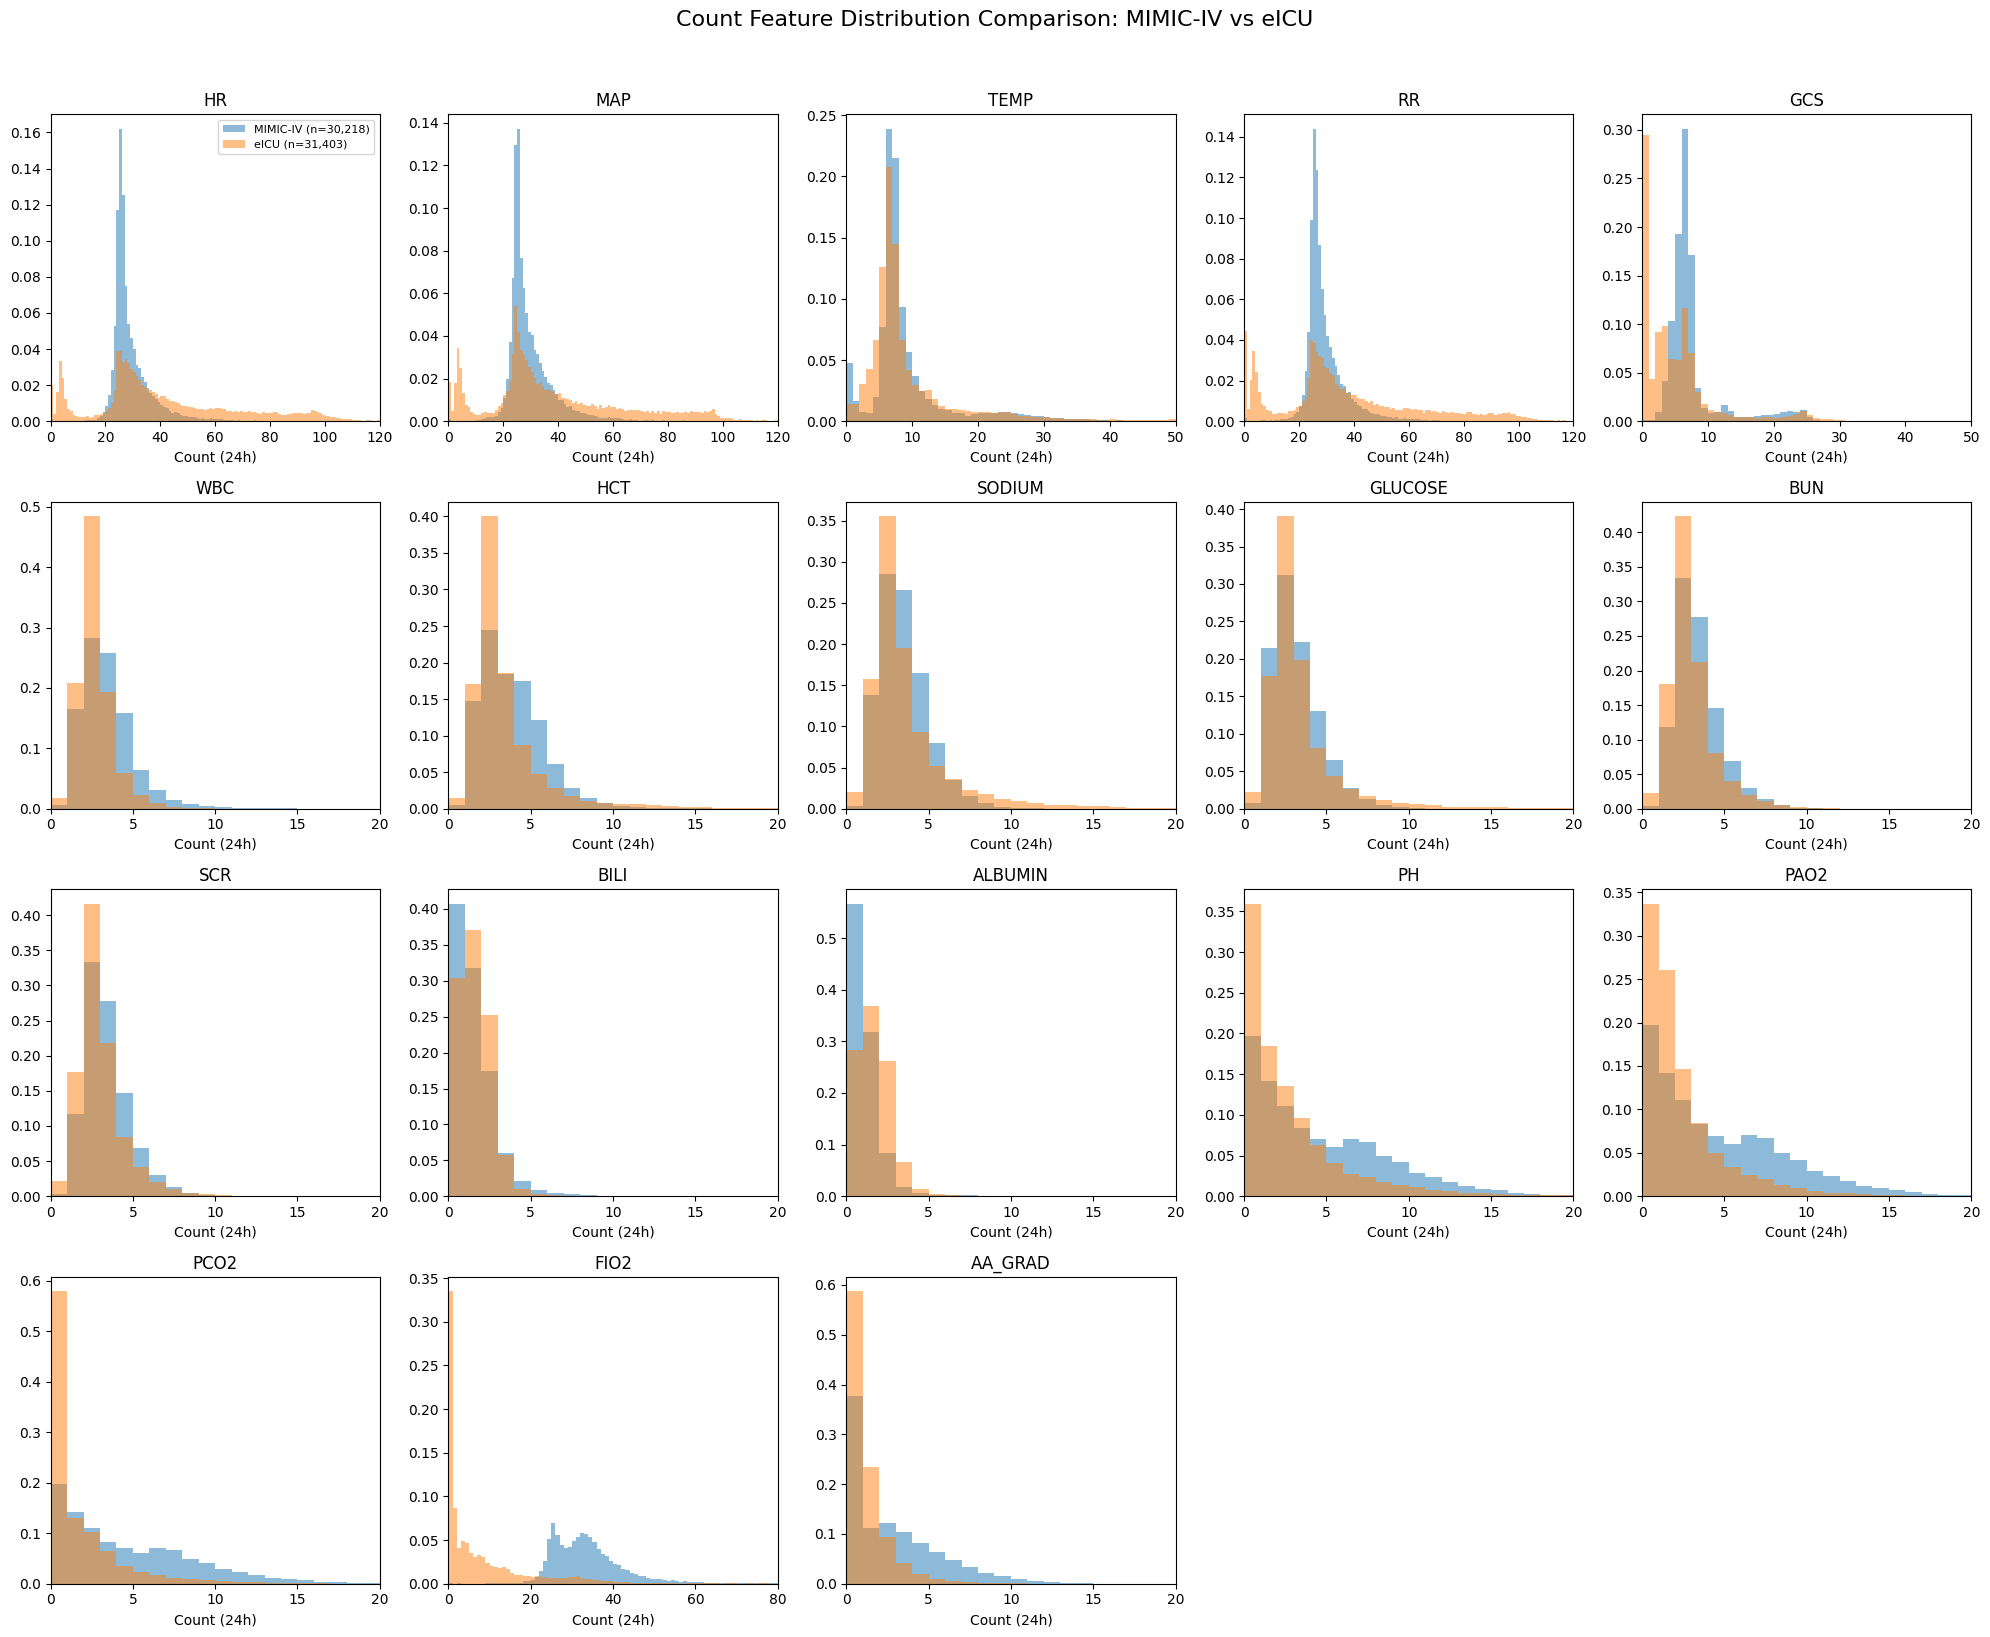

Saved to: ../../output/outputs_for_manuscript


: 

In [ ]:
# Visual comparison of count feature distributions: MIMIC-IV vs eICU
import matplotlib.pyplot as plt
import numpy as np

mimic_all = pd.concat([X_train, X_test])
plot_vars = [v for v in COUNT_FEATURES if v in mimic_all.columns and v in X_ext.columns]

# Vital signs vs Labs (matching 04_count_variable_analysis)
VITAL_COUNTS = ["hr_count", "map_count", "temp_count", "rr_count", "gcs_count"]
LAB_COUNTS = [c for c in plot_vars if c not in VITAL_COUNTS]

# Custom x-axis limits (matching 04_count_variable_analysis)
xlim_map = {
    "hr_count": (0, 120), "map_count": (0, 120), "rr_count": (0, 120),
    "temp_count": (0, 50), "gcs_count": (0, 50),
    "fio2_count": (0, 80),
}
lab_default_xlim = (0, 20)

n_vars = len(plot_vars)
n_cols = 5
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    mimic_vals = mimic_all[var].dropna()
    eicu_vals = X_ext[var].dropna()

    # Set xlim based on variable type
    if var in xlim_map:
        xmin, xmax = xlim_map[var]
    elif var in LAB_COUNTS:
        xmin, xmax = lab_default_xlim
    else:
        xmin, xmax = 0, int(max(mimic_vals.quantile(0.99), eicu_vals.quantile(0.99))) + 5

    bins = np.arange(xmin, xmax + 1, 1)  # bin width = 1
    ax.set_xlim(xmin, xmax)

    ax.hist(mimic_vals, bins=bins, alpha=0.5, label=f"MIMIC-IV (n={len(mimic_vals):,})",
            density=True, color="#1f77b4")
    ax.hist(eicu_vals, bins=bins, alpha=0.5, label=f"eICU (n={len(eicu_vals):,})",
            density=True, color="#ff7f0e")

    ax.set_title(var.replace("_count", "").upper())
    ax.set_xlabel("Count (24h)")
    if i == 0:
        ax.legend(fontsize=8)

# Hide unused subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Count Feature Distribution Comparison: MIMIC-IV vs eICU", fontsize=16, y=1.02)
plt.tight_layout()

# Save
save_path = r"../../output/outputs_for_manuscript"
fig.savefig(f"{save_path}/S.Figure_count_distribution_comparison_mimic_eicu.png", dpi=300, bbox_inches="tight")

plt.show()
print(f"Saved to: {save_path}")

## Step 5: Define Pipeline Functions

We use scikit-learn **Pipelines** to chain preprocessing and modeling steps together. This ensures that:

1. **Imputation** and **scaling** are fit only on training data (preventing data leakage)
2. The same transformations are consistently applied to test and external validation data

```
Pipeline structure:
ColumnTransformer:
  ├─ num: IterativeImputer → StandardScaler  (for numerical features)
  └─ cat: SimpleImputer → OneHotEncoder      (for categorical features)
→ LogisticRegression
```

- **IterativeImputer (MICE)**: Fills missing values by iteratively modeling each feature as a function of all others using Bayesian Ridge regression
- **StandardScaler**: Centers and scales features to mean=0, std=1 (important for logistic regression)
- **SimpleImputer**: Fills missing categorical values with the most frequent category
- **OneHotEncoder**: Converts categorical variables into binary dummy variables

In [16]:
def create_pipeline(numerical_features, categorical_features, random_state=42):
    """Create pipeline with IterativeImputer for numerical and SimpleImputer for categorical."""
    numerical_pipeline = Pipeline([
        ('imputer', IterativeImputer(max_iter=10, random_state=random_state)),
        ('scaler', StandardScaler())
    ])
    
    transformers = [('num', numerical_pipeline, numerical_features)]
    
    if categorical_features and len(categorical_features) > 0:
        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('cat', categorical_pipeline, categorical_features))
    
    preprocessor = ColumnTransformer(transformers, remainder='drop')
    
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=random_state))
    ])


def create_pipeline_no_impute(numerical_features, categorical_features, random_state=42):
    """Create pipeline without imputation (for pre-imputed diff features)."""
    numerical_pipeline = Pipeline([('scaler', StandardScaler())])
    transformers = [('num', numerical_pipeline, numerical_features)]
    
    if categorical_features and len(categorical_features) > 0:
        categorical_pipeline = Pipeline([
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('cat', categorical_pipeline, categorical_features))
    
    preprocessor = ColumnTransformer(transformers, remainder='drop')
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=random_state))
    ])

print("Pipeline functions defined")

Pipeline functions defined


## Step 6: Train Models 1-5

We train Models 1-5 using only the **MIMIC training set (60%)**. Each pipeline handles imputation, scaling, and logistic regression in a single `fit()` call.

Important: The pipeline's `fit()` method learns imputation parameters and scaling statistics **only from the training data**. When we later call `predict_proba()` on the test or external validation data, the same learned parameters are applied — this prevents information from the test/validation sets from influencing the model.

In [17]:
# Prepare data for each model (train, test, external)
X_train_m1 = X_train[MODEL1_NUMERICAL_FEATURES + MODEL1_CATEGORICAL_FEATURES].copy()
X_test_m1 = X_test[MODEL1_NUMERICAL_FEATURES + MODEL1_CATEGORICAL_FEATURES].copy()
X_ext_m1 = X_ext[MODEL1_NUMERICAL_FEATURES + MODEL1_CATEGORICAL_FEATURES].copy()

X_train_m2 = X_train[MODEL2_NUMERICAL_FEATURES + MODEL2_CATEGORICAL_FEATURES].copy()
X_test_m2 = X_test[MODEL2_NUMERICAL_FEATURES + MODEL2_CATEGORICAL_FEATURES].copy()
X_ext_m2 = X_ext[MODEL2_NUMERICAL_FEATURES + MODEL2_CATEGORICAL_FEATURES].copy()

X_train_m3 = X_train[MODEL3_NUMERICAL_FEATURES + MODEL3_CATEGORICAL_FEATURES].copy()
X_test_m3 = X_test[MODEL3_NUMERICAL_FEATURES + MODEL3_CATEGORICAL_FEATURES].copy()
X_ext_m3 = X_ext[MODEL3_NUMERICAL_FEATURES + MODEL3_CATEGORICAL_FEATURES].copy()

X_train_m4 = X_train[MODEL4_NUMERICAL_FEATURES + MODEL4_CATEGORICAL_FEATURES].copy()
X_test_m4 = X_test[MODEL4_NUMERICAL_FEATURES + MODEL4_CATEGORICAL_FEATURES].copy()
X_ext_m4 = X_ext[MODEL4_NUMERICAL_FEATURES + MODEL4_CATEGORICAL_FEATURES].copy()

X_train_m5 = X_train[MODEL5_NUMERICAL_FEATURES + MODEL5_CATEGORICAL_FEATURES].copy()
X_test_m5 = X_test[MODEL5_NUMERICAL_FEATURES + MODEL5_CATEGORICAL_FEATURES].copy()
X_ext_m5 = X_ext[MODEL5_NUMERICAL_FEATURES + MODEL5_CATEGORICAL_FEATURES].copy()

print("Data prepared for Models 1-5 (train / test / external)")

Data prepared for Models 1-5 (train / test / external)


In [18]:
# Create and train pipelines
print("Training Models 1-5...")
print("=" * 60)

# Model 1
print("\nModel 1 (APACHE III Only)...")
pipeline_m1 = create_pipeline(MODEL1_NUMERICAL_FEATURES, MODEL1_CATEGORICAL_FEATURES, RANDOM_STATE)
pipeline_m1.fit(X_train_m1, y_train)
print("  Done")

# Model 2
print("\nModel 2 (Latest + Comorbidity)...")
pipeline_m2 = create_pipeline(MODEL2_NUMERICAL_FEATURES, MODEL2_CATEGORICAL_FEATURES, RANDOM_STATE)
pipeline_m2.fit(X_train_m2, y_train)

pipeline_m3 = create_pipeline(MODEL3_NUMERICAL_FEATURES, MODEL3_CATEGORICAL_FEATURES, RANDOM_STATE)
pipeline_m3.fit(X_train_m3, y_train)
print("  Model 3 (Latest + Count + Comorbidity): Done")
print("  Done")

# Model 3
print("\nModel 4 (Min/Max + Comorbidity)...")
pipeline_m4 = create_pipeline(MODEL4_NUMERICAL_FEATURES, MODEL4_CATEGORICAL_FEATURES, RANDOM_STATE)
pipeline_m4.fit(X_train_m4, y_train)
print("  Done")

# Model 4
print("\nModel 5 (Min/Max + Count + Comorbidity)...")
pipeline_m5 = create_pipeline(MODEL5_NUMERICAL_FEATURES, MODEL5_CATEGORICAL_FEATURES, RANDOM_STATE)
pipeline_m5.fit(X_train_m5, y_train)
print("  Done")

print("\n" + "=" * 60)
print("Models 1-5 trained successfully!")

Training Models 1-5...

Model 1 (APACHE III Only)...
  Done

Model 2 (Latest + Comorbidity)...
  Model 3 (Latest + Count + Comorbidity): Done
  Done

Model 4 (Min/Max + Comorbidity)...
  Done

Model 5 (Min/Max + Count + Comorbidity)...
  Done

Models 1-5 trained successfully!


## Step 7: Train Models 6-7 (Diff Features)

Models 6 and 7 use **diff features** (max − min), which represent the **variability** or **range** of each variable during the ICU stay. A large diff indicates physiological instability (e.g., wide swings in blood pressure).

Since diff features are derived from min and max values, we need to:

1. **Impute** missing min/max values first (using `IterativeImputer` fit on training data only)
2. **Calculate** diff = max − min for each variable
3. **Train** logistic regression on the resulting diff features

Note: Because we pre-impute the data before creating diff features, Models 6-7 use a simpler pipeline without an imputation step (`create_pipeline_no_impute`).

In [19]:
# Impute min/max features for diff calculation
print("Creating diff variables...")

# Use IterativeImputer on numerical features only
imputer_for_diff = IterativeImputer(max_iter=10, random_state=RANDOM_STATE)

X_train_num = X_train[MODEL4_NUMERICAL_FEATURES].copy()
X_test_num = X_test[MODEL4_NUMERICAL_FEATURES].copy()
X_ext_num = X_ext[MODEL4_NUMERICAL_FEATURES].copy()

# Fit on train, transform all three sets
X_train_imputed = pd.DataFrame(
    imputer_for_diff.fit_transform(X_train_num),
    columns=MODEL4_NUMERICAL_FEATURES,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer_for_diff.transform(X_test_num),
    columns=MODEL4_NUMERICAL_FEATURES,
    index=X_test.index
)
X_ext_imputed = pd.DataFrame(
    imputer_for_diff.transform(X_ext_num),
    columns=MODEL4_NUMERICAL_FEATURES,
    index=X_ext.index
)

# Calculate diff = max - min for each set
def create_diff_features(X_imputed, X_orig):
    X_diff = pd.DataFrame(index=X_orig.index)
    X_diff['age'] = X_imputed['age'].values
    X_diff['comorbidity'] = X_orig['comorbidity'].values
    X_diff['uop'] = X_imputed['uop'].values
    
    for var in DIFF_VARS:
        max_col = f'{var}_max'
        min_col = f'{var}_min'
        if max_col in X_imputed.columns and min_col in X_imputed.columns:
            X_diff[f'{var}_diff'] = X_imputed[max_col] - X_imputed[min_col]
    
    # Add count features
    for var in DIFF_VARS:
        count_col = f'{var}_count'
        if count_col in X_orig.columns:
            X_diff[count_col] = X_orig[count_col].values
    
    return X_diff

X_train_diff = create_diff_features(X_train_imputed, X_train)
X_test_diff = create_diff_features(X_test_imputed, X_test)
X_ext_diff = create_diff_features(X_ext_imputed, X_ext)

print(f"  Diff variables: {len([c for c in X_train_diff.columns if '_diff' in c])}")
print(f"  Train shape: {X_train_diff.shape}")
print(f"  Test shape:  {X_test_diff.shape}")
print(f"  Ext shape:   {X_ext_diff.shape}")

Creating diff variables...
  Diff variables: 18
  Train shape: (18130, 39)
  Test shape:  (12088, 39)
  Ext shape:   (31403, 39)


In [20]:
# Define Model 6 & 6 features
MODEL6_NUM_FEATURES = ['age', 'uop'] + [f'{var}_diff' for var in DIFF_VARS if f'{var}_diff' in X_train_diff.columns]
MODEL6_CAT_FEATURES = ['comorbidity']

MODEL7_NUM_FEATURES = MODEL6_NUM_FEATURES + [f'{var}_count' for var in DIFF_VARS if f'{var}_count' in X_train_diff.columns]
MODEL7_CAT_FEATURES = ['comorbidity']

# Prepare data (train, test, external)
X_train_m6 = X_train_diff[MODEL6_NUM_FEATURES + MODEL6_CAT_FEATURES].copy()
X_test_m6 = X_test_diff[MODEL6_NUM_FEATURES + MODEL6_CAT_FEATURES].copy()
X_ext_m6 = X_ext_diff[MODEL6_NUM_FEATURES + MODEL6_CAT_FEATURES].copy()

X_train_m7 = X_train_diff[MODEL7_NUM_FEATURES + MODEL7_CAT_FEATURES].copy()
X_test_m7 = X_test_diff[MODEL7_NUM_FEATURES + MODEL7_CAT_FEATURES].copy()
X_ext_m7 = X_ext_diff[MODEL7_NUM_FEATURES + MODEL7_CAT_FEATURES].copy()

print(f"Model 6: {len(MODEL6_NUM_FEATURES)} numerical + {len(MODEL6_CAT_FEATURES)} categorical")
print(f"Model 7: {len(MODEL7_NUM_FEATURES)} numerical + {len(MODEL7_CAT_FEATURES)} categorical")

Model 6: 20 numerical + 1 categorical
Model 7: 38 numerical + 1 categorical


In [21]:
# Train Models 6 & 7
print("Training Models 6-7...")

# Model 5
print("\nModel 6 (Diff + Comorbidity)...")
pipeline_m6 = create_pipeline_no_impute(MODEL6_NUM_FEATURES, MODEL6_CAT_FEATURES, RANDOM_STATE)
pipeline_m6.fit(X_train_m6, y_train)
print("  Done")

# Model 6
print("\nModel 7 (Diff + Count + Comorbidity)...")
pipeline_m7 = create_pipeline_no_impute(MODEL7_NUM_FEATURES, MODEL7_CAT_FEATURES, RANDOM_STATE)
pipeline_m7.fit(X_train_m7, y_train)
print("  Done")

print("\nAll 6 models trained!")

Training Models 6-7...

Model 6 (Diff + Comorbidity)...
  Done

Model 7 (Diff + Count + Comorbidity)...
  Done

All 6 models trained!


## Step 8: Set Up Model Registry

We organize all trained pipelines into a single dictionary for systematic evaluation.


In [22]:
# Store all pipelines
pipelines = {
    'Model 1': {'name': 'APACHE III Only', 'pipeline': pipeline_m1,
                'X_train': X_train_m1, 'X_test': X_test_m1, 'X_ext': X_ext_m1, 'y_test': y_test, 'y_ext': y_ext},
    'Model 2': {'name': 'Latest + Comorbidity', 'pipeline': pipeline_m2,
                'X_train': X_train_m2, 'X_test': X_test_m2, 'X_ext': X_ext_m2, 'y_test': y_test, 'y_ext': y_ext},
    'Model 3': {'name': 'Latest + Count + Comorbidity', 'pipeline': pipeline_m3,
                'X_train': X_train_m3, 'X_test': X_test_m3, 'X_ext': X_ext_m3, 'y_test': y_test, 'y_ext': y_ext},
    'Model 4': {'name': 'Min/Max + Comorbidity', 'pipeline': pipeline_m4,
                'X_train': X_train_m4, 'X_test': X_test_m4, 'X_ext': X_ext_m4, 'y_test': y_test, 'y_ext': y_ext},
    'Model 5': {'name': 'Min/Max + Count + Comorbidity', 'pipeline': pipeline_m5,
                'X_train': X_train_m5, 'X_test': X_test_m5, 'X_ext': X_ext_m5, 'y_test': y_test, 'y_ext': y_ext},
    'Model 6': {'name': 'Diff + Comorbidity', 'pipeline': pipeline_m6,
                'X_train': X_train_m6, 'X_test': X_test_m6, 'X_ext': X_ext_m6, 'y_test': y_test, 'y_ext': y_ext},
    'Model 7': {'name': 'Diff + Count + Comorbidity', 'pipeline': pipeline_m7,
                'X_train': X_train_m7, 'X_test': X_test_m7, 'X_ext': X_ext_m7, 'y_test': y_test, 'y_ext': y_ext},
}



## Step 9: XGBoost Models with Hyperparameter Tuning

### What is XGBoost?

**XGBoost** = eXtreme Gradient Boosting

A powerful machine learning algorithm that:
- Builds many simple decision trees sequentially
- Each tree corrects errors from previous trees
- Often achieves state-of-the-art performance

### Logistic Regression vs XGBoost

| Aspect | Logistic Regression | XGBoost |
|--------|---------------------|----------|
| **Model Type** | Single linear equation | Ensemble of trees |
| **Non-linear relationships** | Must be manually specified | Learned automatically |
| **Interpretability** | High (coefficients = odds ratios) | Lower (feature importance only) |
| **Risk of overfitting** | Lower | Higher (needs tuning) |
| **Missing values** | Requires imputation | Can handle natively |

### What is Hyperparameter Tuning?

**Hyperparameters** are settings we choose before training:
- `n_estimators`: Number of trees
- `max_depth`: How deep each tree can grow
- `learning_rate`: How much each tree contributes

**Tuning** = Finding the best combination using cross-validation

### What is Cross-Validation?

```
5-Fold Cross-Validation:
Fold 1: Train on folds 2-5, validate on fold 1
Fold 2: Train on folds 1,3-5, validate on fold 2
Fold 3: Train on folds 1-2,4-5, validate on fold 3
Fold 4: Train on folds 1-3,5, validate on fold 4
Fold 5: Train on folds 1-4, validate on fold 5

Final score = Average of all 5 validation scores
```

This gives a more reliable estimate of model performance than a single train/test split.

In [23]:
# ============================================================
# XGBoost Models with Hyperparameter Tuning
# ============================================================
import subprocess
import sys
import warnings

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
from xgboost import XGBClassifier  # noqa: E402

warnings.filterwarnings("ignore")

# --- Pipeline creation functions ---
def create_xgb_pipeline(numerical_features, categorical_features, random_state=42):
    """Create XGBoost pipeline with SimpleImputer (for Models 1-5)."""
    numerical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    transformers = [('num', numerical_transformer, numerical_features)]
    if categorical_features:
        categorical_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ])
        transformers.append(('cat', categorical_transformer, categorical_features))
    preprocessor = ColumnTransformer(transformers=transformers)
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=random_state, eval_metric='logloss', n_jobs=-1))
    ])

def create_xgb_pipeline_no_impute(numerical_features, categorical_features, random_state=42):
    """Create XGBoost pipeline WITHOUT imputation (for Models 5-6 with pre-imputed diff features)."""
    transformers = [('num', StandardScaler(), numerical_features)]
    if categorical_features:
        transformers.append(('cat',
            OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
            categorical_features))
    preprocessor = ColumnTransformer(transformers=transformers)
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=random_state, eval_metric='logloss', n_jobs=-1))
    ])

# --- Hyperparameter search space ---
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 7, 10],
    'classifier__gamma': [0, 0.1, 0.5, 1, 5],
    'classifier__reg_alpha': [0, 0.01, 0.1, 0.5, 1],
    'classifier__reg_lambda': [0, 0.1, 1, 5, 10],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Model configurations ---
model_configs = {
    'Model 1': {'num': MODEL1_NUMERICAL_FEATURES, 'cat': MODEL1_CATEGORICAL_FEATURES,
                'X_train': pipelines['Model 1']['X_train'], 'use_impute': True},
    'Model 2': {'num': MODEL2_NUMERICAL_FEATURES, 'cat': MODEL2_CATEGORICAL_FEATURES,
                'X_train': pipelines['Model 2']['X_train'], 'use_impute': True},
    'Model 3': {'num': MODEL3_NUMERICAL_FEATURES, 'cat': MODEL3_CATEGORICAL_FEATURES,
                'X_train': pipelines['Model 3']['X_train'], 'use_impute': True},
    'Model 4': {'num': MODEL4_NUMERICAL_FEATURES, 'cat': MODEL4_CATEGORICAL_FEATURES,
                'X_train': pipelines['Model 4']['X_train'], 'use_impute': True},
    'Model 5': {'num': MODEL5_NUMERICAL_FEATURES, 'cat': MODEL5_CATEGORICAL_FEATURES,
                'X_train': pipelines['Model 5']['X_train'], 'use_impute': True},
    'Model 6': {'num': MODEL6_NUM_FEATURES, 'cat': MODEL6_CAT_FEATURES,
                'X_train': pipelines['Model 6']['X_train'], 'use_impute': False},
    'Model 7': {'num': MODEL7_NUM_FEATURES, 'cat': MODEL7_CAT_FEATURES,
                'X_train': pipelines['Model 7']['X_train'], 'use_impute': False},
}

# --- Train all XGBoost models ---
print('=' * 60)
print('XGBOOST MODEL TRAINING WITH HYPERPARAMETER TUNING')
print('=' * 60)

xgb_pipelines = {}

for model_key, config in model_configs.items():
    desc = pipelines[model_key]['name']
    print(f'\nTuning XGB {model_key}: {desc}...')
    
    if config['use_impute']:
        xgb_pipe = create_xgb_pipeline(config['num'], config['cat'], RANDOM_STATE)
    else:
        xgb_pipe = create_xgb_pipeline_no_impute(config['num'], config['cat'], RANDOM_STATE)
    
    search = RandomizedSearchCV(
        estimator=xgb_pipe,
        param_distributions=xgb_param_grid,
        n_iter=30,
        scoring='roc_auc',
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(config['X_train'], y_train)
    xgb_pipelines[model_key] = search.best_estimator_
    print(f'  Best AUROC (CV): {search.best_score_:.4f}')

print('\nAll XGBoost models trained!')


XGBOOST MODEL TRAINING WITH HYPERPARAMETER TUNING

Tuning XGB Model 1: APACHE III Only...
  Best AUROC (CV): 0.7384

Tuning XGB Model 2: Latest + Comorbidity...
  Best AUROC (CV): 0.8523

Tuning XGB Model 3: Latest + Count + Comorbidity...
  Best AUROC (CV): 0.8614

Tuning XGB Model 4: Min/Max + Comorbidity...
  Best AUROC (CV): 0.8539

Tuning XGB Model 5: Min/Max + Count + Comorbidity...
  Best AUROC (CV): 0.8592

Tuning XGB Model 6: Diff + Comorbidity...
  Best AUROC (CV): 0.8146

Tuning XGB Model 7: Diff + Count + Comorbidity...
  Best AUROC (CV): 0.8305

All XGBoost models trained!


## Step 10: Evaluate Models

We evaluate all 6 models on three datasets:

| Dataset | Purpose |
|---------|---------|
| **MIMIC Train** | Training performance (expected to be optimistic due to overfitting) |
| **MIMIC Test** | Internal validation — how well does the model generalize to unseen patients from the same hospital? |
| **eICU External** | External validation — how well does the model generalize to completely different hospitals? |

**Key metrics:**
- **AUC (Area Under the ROC Curve)**: Measures discrimination — the probability that the model ranks a randomly chosen non-survivor higher than a randomly chosen survivor. Range: 0.5 (random) to 1.0 (perfect).
- **Brier Score**: Measures calibration — the mean squared difference between predicted probabilities and actual outcomes. Range: 0 (perfect) to 1 (worst). Lower is better.
- **Optimism (Train − Test AUC)**: How much the training AUC overestimates the true performance. A large optimism suggests overfitting.

In [24]:
# Calculate metrics
results = []
predictions = {}

print("=" * 100)
print("PERFORMANCE SUMMARY (MIMIC Train → MIMIC Test → eICU External Validation)")
print("=" * 100)

for model_key, config in pipelines.items():
    pipeline = config['pipeline']
    
    # Training (MIMIC Train)
    y_train_pred = pipeline.predict_proba(config['X_train'])[:, 1]
    train_auc = roc_auc_score(y_train, y_train_pred)
    train_brier = brier_score_loss(y_train, y_train_pred)
    
    # Internal Test (MIMIC Test)
    y_test_pred = pipeline.predict_proba(config['X_test'])[:, 1]
    test_auc = roc_auc_score(y_test, y_test_pred)
    test_brier = brier_score_loss(y_test, y_test_pred)
    
    # External Validation (eICU)
    y_ext_pred = pipeline.predict_proba(config['X_ext'])[:, 1]
    ext_auc = roc_auc_score(y_ext, y_ext_pred)
    ext_brier = brier_score_loss(y_ext, y_ext_pred)
    
    # Store predictions for plotting
    predictions[model_key] = {
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_ext_pred': y_ext_pred
    }
    
    results.append({
        'Model': model_key,
        'Description': config['name'],
        'Train AUC': train_auc,
        'Test AUC': test_auc,
        'Ext AUC': ext_auc,
        'Optimism (Train-Test)': train_auc - test_auc,
        'Ext Brier': ext_brier
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("\n" + "=" * 100)
print(f"Best model on internal test:       {results_df.loc[results_df['Test AUC'].idxmax(), 'Model']} "
      f"(AUC = {results_df['Test AUC'].max():.4f})")
print(f"Best model on external validation: {results_df.loc[results_df['Ext AUC'].idxmax(), 'Model']} "
      f"(AUC = {results_df['Ext AUC'].max():.4f})")

PERFORMANCE SUMMARY (MIMIC Train → MIMIC Test → eICU External Validation)
  Model                   Description  Train AUC  Test AUC  Ext AUC  Optimism (Train-Test)  Ext Brier
Model 1               APACHE III Only   0.738794  0.730727 0.747843               0.008067   0.104232
Model 2          Latest + Comorbidity   0.825242  0.819090 0.771723               0.006152   0.105738
Model 3  Latest + Count + Comorbidity   0.842741  0.833575 0.751821               0.009166   0.112538
Model 4         Min/Max + Comorbidity   0.825425  0.819718 0.745269               0.005707   0.106705
Model 5 Min/Max + Count + Comorbidity   0.837308  0.831244 0.735616               0.006063   0.112815
Model 6            Diff + Comorbidity   0.775773  0.767737 0.669444               0.008036   0.120698
Model 7    Diff + Count + Comorbidity   0.796418  0.789239 0.663837               0.007179   0.121579

Best model on internal test:       Model 3 (AUC = 0.8336)
Best model on external validation: Model 2 (AUC = 0

In [25]:
# XGBoost Performance Evaluation (Internal Test + External Validation)

print("=" * 120)
print("XGBOOST PERFORMANCE COMPARISON (Internal Test & External Validation)")
print("=" * 120)

xgb_results = []
xgb_predictions = {}

for model_key in xgb_pipelines:
    xgb_pipe = xgb_pipelines[model_key]
    config = pipelines[model_key]
    y_test_pred_xgb = xgb_pipe.predict_proba(config['X_test'])[:, 1]
    test_auc = roc_auc_score(y_test, y_test_pred_xgb)
    test_brier = brier_score_loss(y_test, y_test_pred_xgb)
    y_ext_pred_xgb = xgb_pipe.predict_proba(config['X_ext'])[:, 1]
    ext_auc = roc_auc_score(y_ext, y_ext_pred_xgb)
    ext_brier = brier_score_loss(y_ext, y_ext_pred_xgb)
    test_auprc = average_precision_score(y_test, y_test_pred_xgb)
    ext_auprc = average_precision_score(y_ext, y_ext_pred_xgb)
    xgb_predictions[model_key] = {
        'y_test_pred': y_test_pred_xgb,
        'y_ext_pred': y_ext_pred_xgb
    }
    xgb_results.append({
        'Model': f'XGB {model_key}',
        'Description': config['name'],
        'Test AUROC': test_auc, 'Ext AUROC': ext_auc,
        'Test AUPRC': test_auprc, 'Ext AUPRC': ext_auprc,
        'Test Brier': test_brier, 'Ext Brier': ext_brier
    })

xgb_results_df = pd.DataFrame(xgb_results)
print(xgb_results_df.to_string(index=False))

# LR vs XGBoost comparison
print("\n" + "=" * 120)
print("LR vs XGBoost COMPARISON (Validation AUROC)")
print("=" * 120)
for model_key in xgb_pipelines:
    lr_test = roc_auc_score(y_test, predictions[model_key]['y_test_pred'])
    xgb_test = roc_auc_score(y_test, xgb_predictions[model_key]['y_test_pred'])
    lr_ext = roc_auc_score(y_ext, predictions[model_key]['y_ext_pred'])
    xgb_ext = roc_auc_score(y_ext, xgb_predictions[model_key]['y_ext_pred'])
    print(f"{model_key:10s}  LR Test={lr_test:.4f}  XGB Test={xgb_test:.4f}  |  LR Ext={lr_ext:.4f}  XGB Ext={xgb_ext:.4f}")

XGBOOST PERFORMANCE COMPARISON (Internal Test & External Validation)
      Model                   Description  Test AUROC  Ext AUROC  Test AUPRC  Ext AUPRC  Test Brier  Ext Brier
XGB Model 1               APACHE III Only    0.730274   0.747822    0.371722   0.375684    0.121454   0.104431
XGB Model 2          Latest + Comorbidity    0.848600   0.800944    0.544011   0.452250    0.101282   0.098816
XGB Model 3  Latest + Count + Comorbidity    0.859198   0.804585    0.562034   0.461784    0.098822   0.097535
XGB Model 4         Min/Max + Comorbidity    0.850085   0.794499    0.538954   0.440856    0.101635   0.101024
XGB Model 5 Min/Max + Count + Comorbidity    0.856655   0.797410    0.551845   0.446910    0.099896   0.099665
XGB Model 6            Diff + Comorbidity    0.811067   0.679552    0.453775   0.272034    0.110951   0.125223
XGB Model 7    Diff + Count + Comorbidity    0.829255   0.708420    0.488233   0.307807    0.106956   0.115236

LR vs XGBoost COMPARISON (Validation AUROC

## Step 11: ROC Curves

**ROC (Receiver Operating Characteristic) curves** plot the True Positive Rate (sensitivity) against the False Positive Rate (1 − specificity) at every possible classification threshold.

- A curve closer to the **top-left corner** indicates better discrimination
- The **diagonal dashed line** represents a random classifier (AUC = 0.5)
- The **AUC** summarizes the overall discriminative ability in a single number

We plot three panels side by side:
1. **Train**: Performance on data the model was trained on (always looks good)
2. **Internal Test**: Performance on held-out MIMIC patients (honest estimate within the same population)
3. **External Validation**: Performance on eICU patients (the strictest test of generalizability)

A model that performs well on all three panels is more likely to be robust and clinically useful.

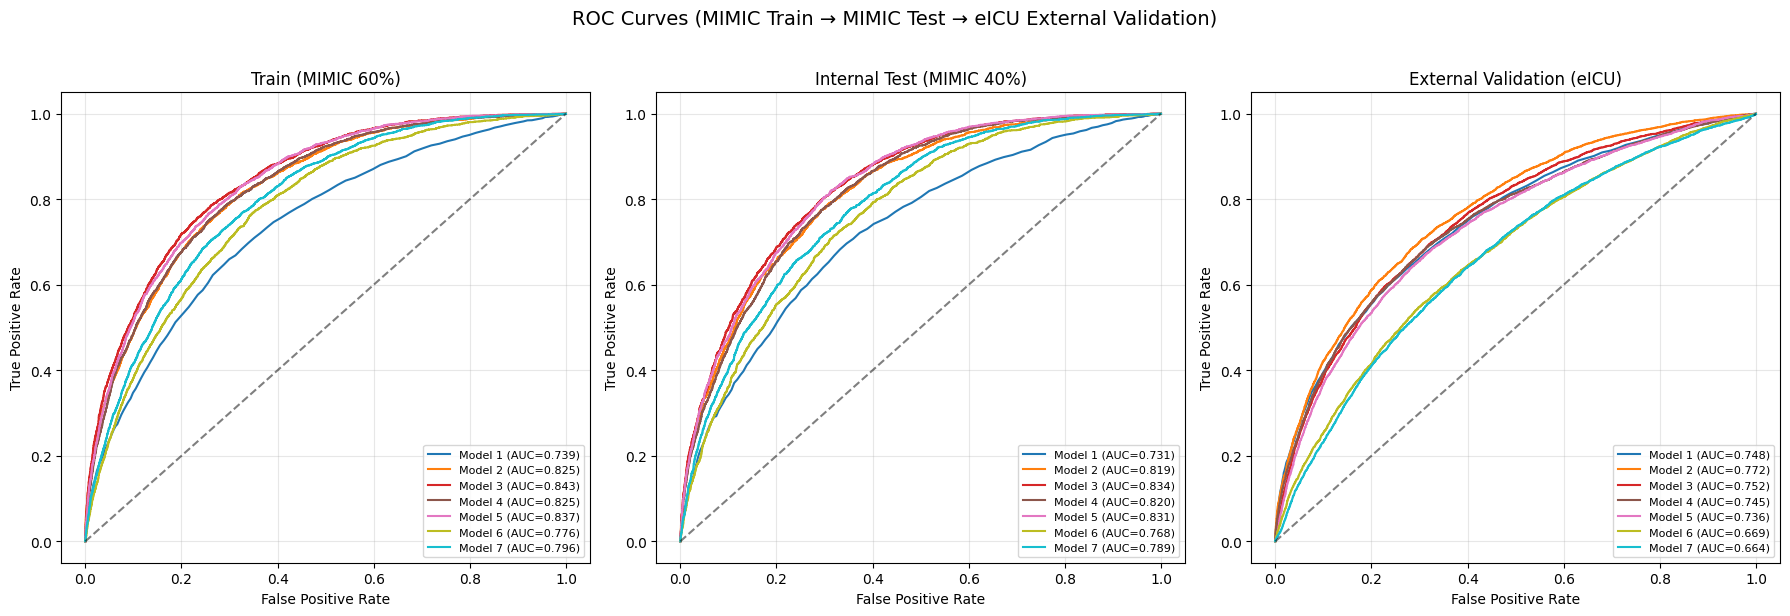

In [26]:
# ROC Curves (3 panels: Train, Internal Test, External Validation)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = plt.cm.tab10(np.linspace(0, 1, 7))

# Training ROC (MIMIC Train)
ax = axes[0]
for i, (model_key, preds) in enumerate(predictions.items()):
    fpr, tpr, _ = roc_curve(y_train, preds['y_train_pred'])
    auc = roc_auc_score(y_train, preds['y_train_pred'])
    ax.plot(fpr, tpr, color=colors[i], label=f"{model_key} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Train (MIMIC 60%)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# Internal Test ROC (MIMIC Test)
ax = axes[1]
for i, (model_key, preds) in enumerate(predictions.items()):
    fpr, tpr, _ = roc_curve(y_test, preds['y_test_pred'])
    auc = roc_auc_score(y_test, preds['y_test_pred'])
    ax.plot(fpr, tpr, color=colors[i], label=f"{model_key} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Internal Test (MIMIC 40%)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# External Validation ROC (eICU)
ax = axes[2]
for i, (model_key, preds) in enumerate(predictions.items()):
    fpr, tpr, _ = roc_curve(y_ext, preds['y_ext_pred'])
    auc = roc_auc_score(y_ext, preds['y_ext_pred'])
    ax.plot(fpr, tpr, color=colors[i], label=f"{model_key} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('External Validation (eICU)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves (MIMIC Train → MIMIC Test → eICU External Validation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 12: Calibration Plots

**Calibration plots** show how well the predicted probabilities match the actual observed outcomes.

- The **x-axis** shows the mean predicted probability (in bins)
- The **y-axis** shows the actual fraction of patients who died in each bin
- The **diagonal dashed line** represents perfect calibration (predicted probability = actual probability)

A well-calibrated model should have points close to the diagonal. For example, among patients given a 30% predicted mortality, approximately 30% should actually die.

**Why calibration matters in clinical practice:**
- Discrimination (AUC) tells you if the model can *rank* patients by risk
- Calibration tells you if the model gives *accurate probability estimates*
- A model can have good discrimination but poor calibration (e.g., systematically overestimating risk)

The **Brier score** combines both discrimination and calibration into a single number (lower is better).

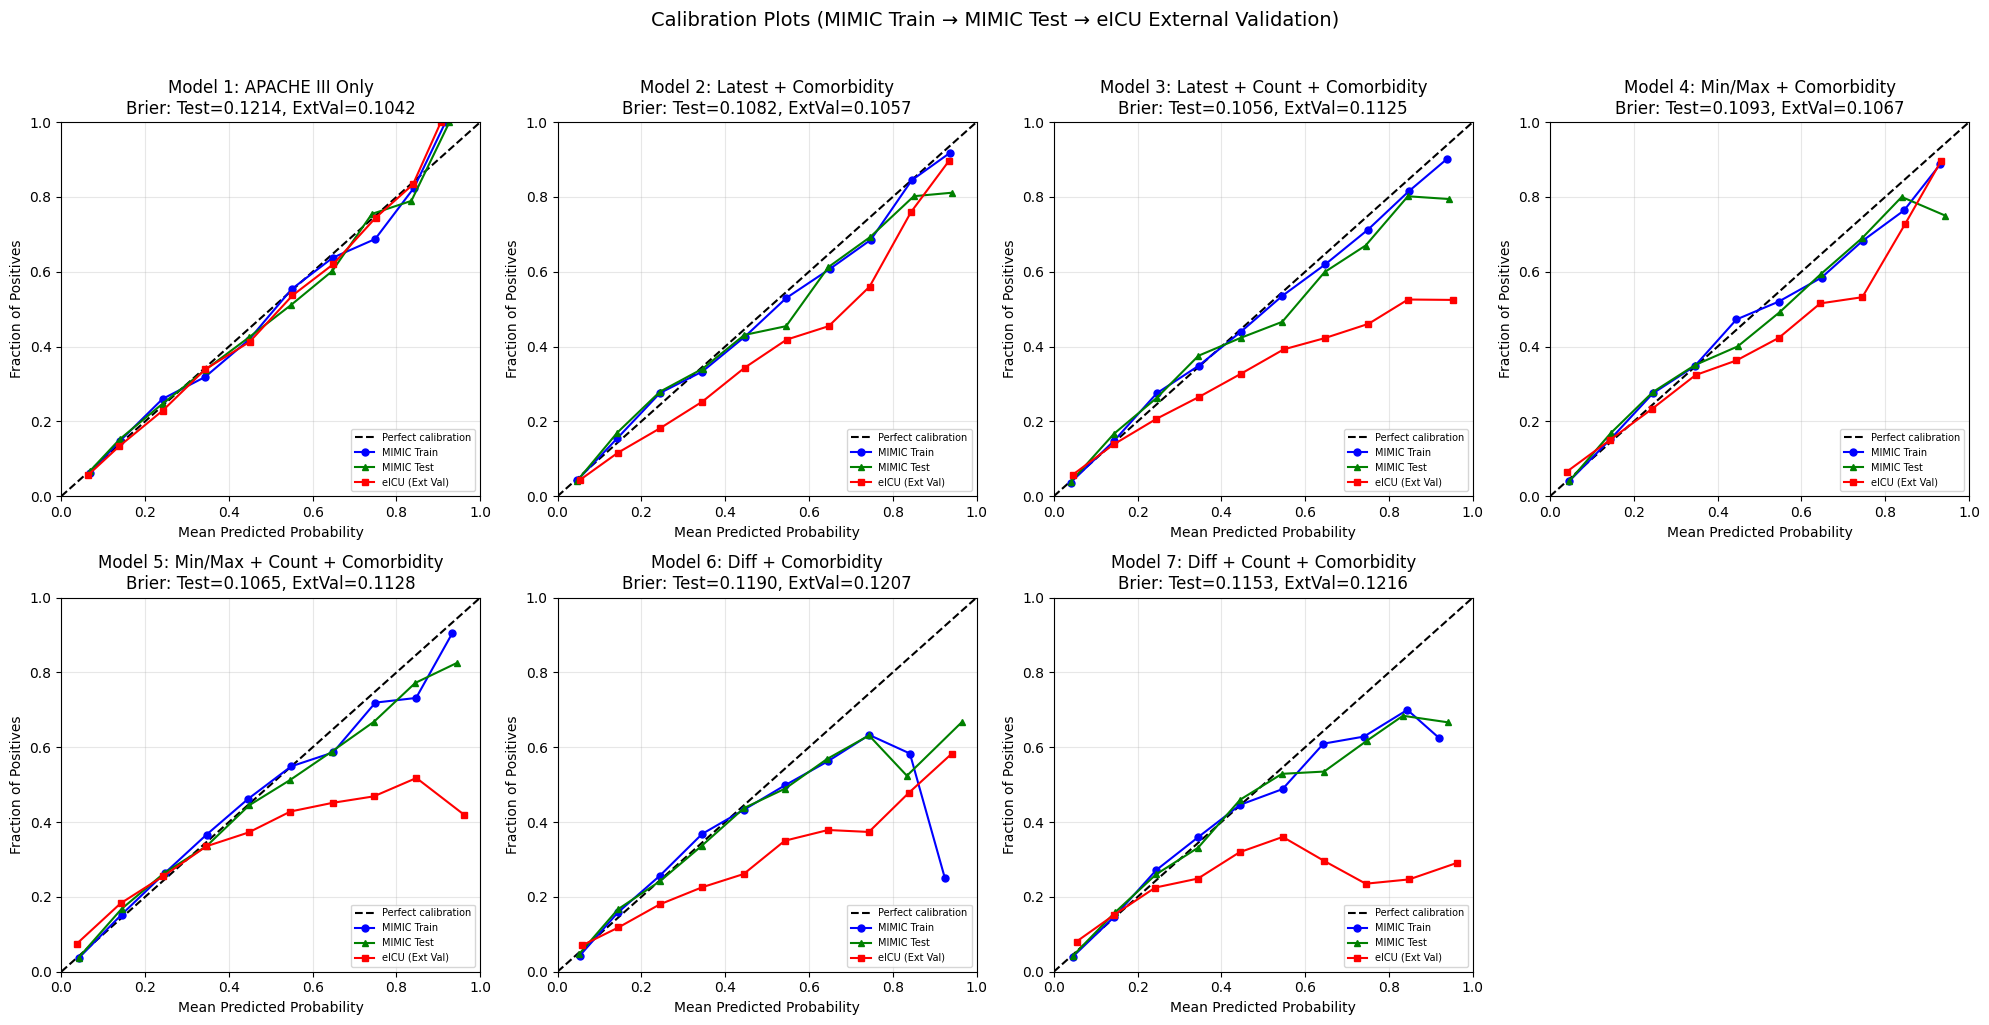

In [27]:
# Calibration Plots (3 lines per model: Train, Test, External)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (model_key, preds) in enumerate(predictions.items()):
    ax = axes[i]
    
    # Training calibration (MIMIC Train)
    fraction_pos_train, mean_pred_train = calibration_curve(
        y_train, preds['y_train_pred'], n_bins=10, strategy='uniform'
    )
    
    # Internal Test calibration (MIMIC Test)
    fraction_pos_test, mean_pred_test = calibration_curve(
        y_test, preds['y_test_pred'], n_bins=10, strategy='uniform'
    )
    
    # External Validation calibration (eICU)
    fraction_pos_ext, mean_pred_ext = calibration_curve(
        y_ext, preds['y_ext_pred'], n_bins=10, strategy='uniform'
    )
    
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.plot(mean_pred_train, fraction_pos_train, 'b-o', label='MIMIC Train', markersize=5)
    ax.plot(mean_pred_test, fraction_pos_test, 'g-^', label='MIMIC Test', markersize=5)
    ax.plot(mean_pred_ext, fraction_pos_ext, 'r-s', label='eICU (Ext Val)', markersize=5)
    
    # Brier scores
    brier_test = brier_score_loss(y_test, preds['y_test_pred'])
    brier_ext = brier_score_loss(y_ext, preds['y_ext_pred'])
    
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f"{model_key}: {pipelines[model_key]['name']}\nBrier: Test={brier_test:.4f}, ExtVal={brier_ext:.4f}")
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Calibration Plots (MIMIC Train → MIMIC Test → eICU External Validation)', fontsize=14, y=1.02)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Step 13: AUPRC, Bootstrap Confidence Intervals, and Calibration Metrics

### Why Report AUPRC?

For **imbalanced data** (low mortality rate):
- AUROC can be misleadingly high
- AUPRC is more informative for rare outcomes
- Baseline AUPRC = prevalence (not 0.5 like AUROC)

### Why Bootstrap Confidence Intervals?

A single AUROC value (e.g., 0.82) doesn't tell us how **precise** this estimate is.

**Bootstrap** procedure:
1. Randomly resample validation data (with replacement)
2. Calculate AUROC on this sample
3. Repeat 1000 times
4. Use 2.5th and 97.5th percentiles as 95% CI

**Example**: AUROC = 0.82 (95% CI: 0.79-0.85)
- We are 95% confident the true AUROC is between 0.79 and 0.85

### Calibration Metrics

| Metric | Ideal Value | Interpretation |
|--------|-------------|----------------|
| **Brier Score** | 0 | Lower = better probability estimates |
| **Calibration Slope** | 1.0 | <1 = overconfident, >1 = underconfident |
| **Calibration Intercept** | 0 | <0 = overestimates risk, >0 = underestimates |

### What Journals Expect

1. **Main Table**: AUROC and AUPRC with 95% CI
2. **Appendix Table**: Calibration metrics (Brier, slope, intercept)
3. **Figures**: ROC curves, calibration plots

In [28]:
# ============================================================
# Bootstrap CI and Calibration Metric Functions
# ============================================================

def calculate_calibration_metrics(y_true, y_pred):
    """Calculate calibration slope and intercept (CITL) via logistic recalibration:
    logit(Y) = alpha + beta * logit(p_hat).  Ideal: CITL=0, slope=1.
    """
    y_pred_clipped = np.clip(y_pred, 1e-10, 1 - 1e-10)
    logit_pred = np.log(y_pred_clipped / (1 - y_pred_clipped))
    lr_cal = LogisticRegression(solver='lbfgs', max_iter=1000)
    lr_cal.fit(logit_pred.reshape(-1, 1), y_true)
    return lr_cal.coef_[0][0], lr_cal.intercept_[0]


def bootstrap_ci(y_true, y_pred, metric_func, n_bootstrap=None, ci=0.95, random_state=42):
    """Calculate bootstrap confidence interval for a metric."""
    if n_bootstrap is None:
        n_bootstrap = N_BOOT
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    point_estimate = metric_func(y_true_arr, y_pred_arr)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        yt = y_true_arr[idx]
        yp = y_pred_arr[idx]
        if len(np.unique(yt)) < 2:
            continue
        try:
            scores.append(metric_func(yt, yp))
        except Exception:
            continue
    alpha = 1 - ci
    lo = np.percentile(scores, alpha / 2 * 100)
    hi = np.percentile(scores, (1 - alpha / 2) * 100)
    return point_estimate, lo, hi


def bootstrap_delta_ci(y_true_int, y_pred_int, y_true_ext, y_pred_ext,
                       metric_func, n_bootstrap=None, ci=0.95, random_state=42):
    """Bootstrap CI for delta = metric(external) - metric(internal).
    Resamples independently within each dataset.
    """
    if n_bootstrap is None:
        n_bootstrap = N_BOOT
    rng = np.random.RandomState(random_state)
    yti = np.asarray(y_true_int)
    ypi = np.asarray(y_pred_int)
    yte = np.asarray(y_true_ext)
    ype = np.asarray(y_pred_ext)
    n_int = len(yti)
    n_ext = len(yte)
    point_int = metric_func(yti, ypi)
    point_ext = metric_func(yte, ype)
    point_delta = point_ext - point_int
    deltas = []
    for _ in range(n_bootstrap):
        ii = rng.randint(0, n_int, n_int)
        ie = rng.randint(0, n_ext, n_ext)
        yt_i = yti[ii]
        yp_i = ypi[ii]
        yt_e = yte[ie]
        yp_e = ype[ie]
        if len(np.unique(yt_i)) < 2 or len(np.unique(yt_e)) < 2:
            continue
        try:
            deltas.append(metric_func(yt_e, yp_e) - metric_func(yt_i, yp_i))
        except Exception:
            continue
    alpha = 1 - ci
    lo = np.percentile(deltas, alpha / 2 * 100)
    hi = np.percentile(deltas, (1 - alpha / 2) * 100)
    return point_delta, lo, hi


def bootstrap_calibration_ci(y_true, y_pred, n_bootstrap=None, ci=0.95, random_state=42):
    """Bootstrap CI for calibration slope and CITL (intercept).
    Returns: (slope, slope_lo, slope_hi, intercept, int_lo, int_hi)
    """
    if n_bootstrap is None:
        n_bootstrap = N_BOOT
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    yt = np.asarray(y_true)
    yp = np.asarray(y_pred)
    point_slope, point_int = calculate_calibration_metrics(yt, yp)
    slopes = []
    intercepts = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        yti = yt[idx]
        ypi = yp[idx]
        if len(np.unique(yti)) < 2:
            continue
        try:
            s, i = calculate_calibration_metrics(yti, ypi)
            slopes.append(s)
            intercepts.append(i)
        except Exception:
            continue
    alpha = 1 - ci
    lo_p = alpha / 2 * 100
    hi_p = (1 - alpha / 2) * 100
    return (point_slope, np.percentile(slopes, lo_p), np.percentile(slopes, hi_p),
            point_int, np.percentile(intercepts, lo_p), np.percentile(intercepts, hi_p))


print('Bootstrap CI and calibration functions defined.')
print(f'Bootstrap iterations: N_BOOT = {N_BOOT}')
print('Confidence level: 95%')


Bootstrap CI and calibration functions defined.
Bootstrap iterations: N_BOOT = 2000
Confidence level: 95%


In [29]:
# Calculate AUROC, AUPRC with Bootstrap CI + Calibration Metrics
# For Internal Test (MIMIC 40%) and External Validation (eICU)

print("=" * 100)
print("CALCULATING COMPREHENSIVE METRICS WITH BOOTSTRAP CI")
print("=" * 100)

comprehensive_results = []

for model_key, config in pipelines.items():
    pipeline = config['pipeline']
    y_test_pred = predictions[model_key]['y_test_pred']
    y_ext_pred = predictions[model_key]['y_ext_pred']

    # Internal Test Metrics
    auroc_test, auroc_test_lo, auroc_test_hi = bootstrap_ci(y_test, y_test_pred, roc_auc_score)
    auprc_test, auprc_test_lo, auprc_test_hi = bootstrap_ci(y_test, y_test_pred, average_precision_score)
    brier_test = brier_score_loss(y_test, y_test_pred)
    cal_slope_test, cal_int_test = calculate_calibration_metrics(y_test, y_test_pred)

    # External Validation Metrics
    auroc_ext, auroc_ext_lo, auroc_ext_hi = bootstrap_ci(y_ext, y_ext_pred, roc_auc_score)
    auprc_ext, auprc_ext_lo, auprc_ext_hi = bootstrap_ci(y_ext, y_ext_pred, average_precision_score)
    brier_ext = brier_score_loss(y_ext, y_ext_pred)
    cal_slope_ext, cal_int_ext = calculate_calibration_metrics(y_ext, y_ext_pred)

    comprehensive_results.append({
        'Model': model_key,
        'Description': config['name'],
        'Test AUROC': auroc_test,
        'Test AUROC 95% CI': f"({auroc_test_lo:.3f}-{auroc_test_hi:.3f})",
        'Test AUPRC': auprc_test,
        'Test AUPRC 95% CI': f"({auprc_test_lo:.3f}-{auprc_test_hi:.3f})",
        'Test Brier': brier_test,
        'Test Cal.Slope': cal_slope_test,
        'Test Cal.Intercept': cal_int_test,
        'Ext AUROC': auroc_ext,
        'Ext AUROC 95% CI': f"({auroc_ext_lo:.3f}-{auroc_ext_hi:.3f})",
        'Ext AUPRC': auprc_ext,
        'Ext AUPRC 95% CI': f"({auprc_ext_lo:.3f}-{auprc_ext_hi:.3f})",
        'Ext Brier': brier_ext,
        'Ext Cal.Slope': cal_slope_ext,
        'Ext Cal.Intercept': cal_int_ext,
    })
    print(f"  {model_key} done.")

comp_df = pd.DataFrame(comprehensive_results)
print("\nAll metrics calculated.")

CALCULATING COMPREHENSIVE METRICS WITH BOOTSTRAP CI
  Model 1 done.
  Model 2 done.
  Model 3 done.
  Model 4 done.
  Model 5 done.
  Model 6 done.
  Model 7 done.

All metrics calculated.


In [30]:
# Discrimination Metrics Table (AUROC + AUPRC with 95% CI)
print("=" * 120)
print("TABLE: Discrimination Performance (Internal Test & External Validation)")
print("=" * 120)

for _, row in comp_df.iterrows():
    print(f"\n{row['Model']}: {row['Description']}")
    print(f"  Internal Test:       AUROC = {row['Test AUROC']:.3f} {row['Test AUROC 95% CI']}   AUPRC = {row['Test AUPRC']:.3f} {row['Test AUPRC 95% CI']}")
    print(f"  External Validation: AUROC = {row['Ext AUROC']:.3f} {row['Ext AUROC 95% CI']}   AUPRC = {row['Ext AUPRC']:.3f} {row['Ext AUPRC 95% CI']}")

print("\n" + "=" * 120)

TABLE: Discrimination Performance (Internal Test & External Validation)

Model 1: APACHE III Only
  Internal Test:       AUROC = 0.731 (0.719-0.743)   AUPRC = 0.373 (0.353-0.396)
  External Validation: AUROC = 0.748 (0.740-0.755)   AUPRC = 0.377 (0.363-0.392)

Model 2: Latest + Comorbidity
  Internal Test:       AUROC = 0.819 (0.809-0.829)   AUPRC = 0.490 (0.467-0.514)
  External Validation: AUROC = 0.772 (0.764-0.779)   AUPRC = 0.397 (0.382-0.412)

Model 3: Latest + Count + Comorbidity
  Internal Test:       AUROC = 0.834 (0.824-0.843)   AUPRC = 0.509 (0.486-0.533)
  External Validation: AUROC = 0.752 (0.744-0.759)   AUPRC = 0.340 (0.326-0.354)

Model 4: Min/Max + Comorbidity
  Internal Test:       AUROC = 0.820 (0.810-0.829)   AUPRC = 0.474 (0.451-0.501)
  External Validation: AUROC = 0.745 (0.737-0.753)   AUPRC = 0.365 (0.350-0.381)

Model 5: Min/Max + Count + Comorbidity
  Internal Test:       AUROC = 0.831 (0.822-0.840)   AUPRC = 0.498 (0.475-0.524)
  External Validation: AUROC = 

In [31]:
# Calibration Metrics Table (Brier, Slope, Intercept)
print("=" * 120)
print("TABLE: Calibration Performance (Internal Test & External Validation)")
print("=" * 120)

cal_display = comp_df[['Model', 'Description', 'Test Brier', 'Test Cal.Slope', 'Test Cal.Intercept',
                        'Ext Brier', 'Ext Cal.Slope', 'Ext Cal.Intercept']].copy()

for col in ['Test Brier', 'Ext Brier']:
    cal_display[col] = cal_display[col].map(lambda x: f"{x:.4f}")
for col in ['Test Cal.Slope', 'Ext Cal.Slope']:
    cal_display[col] = cal_display[col].map(lambda x: f"{x:.3f}")
for col in ['Test Cal.Intercept', 'Ext Cal.Intercept']:
    cal_display[col] = cal_display[col].map(lambda x: f"{x:.3f}")

print(cal_display.to_string(index=False))
print("\n" + "=" * 120)

TABLE: Calibration Performance (Internal Test & External Validation)
  Model                   Description Test Brier Test Cal.Slope Test Cal.Intercept Ext Brier Ext Cal.Slope Ext Cal.Intercept
Model 1               APACHE III Only     0.1214          0.967             -0.027    0.1042         1.007            -0.065
Model 2          Latest + Comorbidity     0.1082          0.959             -0.044    0.1057         0.874            -0.519
Model 3  Latest + Count + Comorbidity     0.1056          0.938             -0.069    0.1125         0.582            -0.804
Model 4         Min/Max + Comorbidity     0.1093          0.961             -0.048    0.1067         0.649            -0.479
Model 5 Min/Max + Count + Comorbidity     0.1065          0.960             -0.052    0.1128         0.505            -0.649
Model 6            Diff + Comorbidity     0.1190          0.952             -0.064    0.1207         0.593            -0.895
Model 7    Diff + Count + Comorbidity     0.1153        

## Step 14: Threshold-Based Classification Metrics

### Why Do We Need a Threshold?

The model outputs **probabilities** (0 to 1), but clinical decisions are often **binary** (treat/don't treat). To convert probabilities to predictions, we need a **threshold**.

| Threshold | Effect on Predictions |
|-----------|----------------------|
| **0.5** (default) | Balanced - standard classification |
| **Lower (e.g., 0.3)** | More positive predictions (higher sensitivity) |
| **Higher (e.g., 0.7)** | Fewer positive predictions (higher specificity) |

### Metrics at Default Threshold (0.5)

| Metric | Formula | Clinical Interpretation |
|--------|---------|------------------------|
| **Sensitivity (Sn)** | TP / (TP + FN) | % of deaths correctly identified |
| **Specificity (Sp)** | TN / (TN + FP) | % of survivors correctly identified |
| **PPV** | TP / (TP + FP) | If predicted death, probability of actual death |
| **NPV** | TN / (TN + FN) | If predicted survival, probability of actual survival |
| **Accuracy** | (TP + TN) / Total | % of all predictions correct |
| **Precision** | Same as PPV | Positive predictive value |
| **Recall** | Same as Sensitivity | True positive rate |
| **F1 Score** | 2 x (Precision x Recall) / (Precision + Recall) | Harmonic mean of precision and recall |

### Confusion Matrix

```
                    Predicted
                 Negative  Positive
Actual Negative    TN        FP
       Positive    FN        TP
```

### Important Note

These metrics **depend on the chosen threshold**. AUROC and AUPRC are preferred for model comparison because they evaluate performance across **all possible thresholds**.

In [32]:
# Threshold-Based Classification Metrics
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix
)

THRESHOLD = 0.5

def calculate_threshold_metrics(y_true, y_pred_proba, threshold=0.5):
    """Calculate all threshold-based classification metrics."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {
        'Accuracy': accuracy, 'Sensitivity': sensitivity, 'Specificity': specificity,
        'PPV': ppv, 'NPV': npv, 'F1_Score': f1,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

print(f"Threshold-based metrics function defined. Default threshold: {THRESHOLD}")

Threshold-based metrics function defined. Default threshold: 0.5


In [33]:
# Calculate Threshold-Based Metrics for Internal Test and External Validation

threshold_results = []

for model_key, config in pipelines.items():
    # Internal Test
    y_test_pred = predictions[model_key]['y_test_pred']
    metrics_test = calculate_threshold_metrics(y_test, y_test_pred, threshold=THRESHOLD)
    metrics_test['Model'] = model_key
    metrics_test['Dataset'] = 'Internal Test'
    threshold_results.append(metrics_test)

    # External Validation
    y_ext_pred = predictions[model_key]['y_ext_pred']
    metrics_ext = calculate_threshold_metrics(y_ext, y_ext_pred, threshold=THRESHOLD)
    metrics_ext['Model'] = model_key
    metrics_ext['Dataset'] = 'External Validation'
    threshold_results.append(metrics_ext)

threshold_df = pd.DataFrame(threshold_results)

# Display Internal Test
print("=" * 120)
print(f"TABLE: Classification Metrics at Threshold = {THRESHOLD} (Internal Test - MIMIC 40%)")
print("=" * 120)
test_cols = ['Model', 'Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1_Score']
test_display = threshold_df[threshold_df['Dataset'] == 'Internal Test'][test_cols].copy()
for col in test_cols[1:]:
    test_display[col] = test_display[col].map(lambda x: f"{x:.3f}")
print(test_display.to_string(index=False))

print()

# Display External Validation
print("=" * 120)
print(f"TABLE: Classification Metrics at Threshold = {THRESHOLD} (External Validation - eICU)")
print("=" * 120)
ext_display = threshold_df[threshold_df['Dataset'] == 'External Validation'][test_cols].copy()
for col in test_cols[1:]:
    ext_display[col] = ext_display[col].map(lambda x: f"{x:.3f}")
print(ext_display.to_string(index=False))

print("\nNote: Sensitivity = Recall = True Positive Rate")
print("      PPV = Precision = Positive Predictive Value")
print("      NPV = Negative Predictive Value")

TABLE: Classification Metrics at Threshold = 0.5 (Internal Test - MIMIC 40%)
  Model Accuracy Sensitivity Specificity   PPV   NPV F1_Score
Model 1    0.842       0.112       0.985 0.588 0.851    0.188
Model 2    0.851       0.250       0.968 0.605 0.869    0.353
Model 3    0.854       0.275       0.966 0.614 0.873    0.380
Model 4    0.850       0.240       0.969 0.602 0.867    0.343
Model 5    0.853       0.257       0.969 0.615 0.870    0.363
Model 6    0.839       0.121       0.979 0.532 0.851    0.197
Model 7    0.842       0.163       0.974 0.555 0.857    0.252

TABLE: Classification Metrics at Threshold = 0.5 (External Validation - eICU)
  Model Accuracy Sensitivity Specificity   PPV   NPV F1_Score
Model 1    0.868       0.134       0.986 0.612 0.876    0.220
Model 2    0.861       0.242       0.961 0.502 0.887    0.327
Model 3    0.853       0.241       0.952 0.447 0.886    0.314
Model 4    0.862       0.175       0.973 0.513 0.880    0.261
Model 5    0.856       0.154       0.9

## Step 15: Model Coefficients (Logistic Regression Interpretability)

### Why Examine Coefficients?

Logistic regression coefficients represent the **log-odds ratio** for each feature:
- **Positive coefficient**: Higher values of this feature -> higher predicted mortality
- **Negative coefficient**: Higher values of this feature -> lower predicted mortality
- **Magnitude**: Larger absolute values indicate stronger associations

The **odds ratio** (exp(coefficient)) is more clinically interpretable:
- OR > 1: The feature increases the odds of mortality
- OR < 1: The feature decreases the odds of mortality
- OR = 1: No effect

### Important Caveats

- Coefficients are only valid for **logistic regression** (not XGBoost)
- Features are **standardized** (mean=0, std=1), so coefficients are comparable
- Coefficients reflect **associations**, not necessarily **causal relationships**

In [34]:
# Model Coefficients for Logistic Regression (Best Model on Internal Test)
best_model_key = results_df.loc[results_df['Test AUC'].idxmax(), 'Model']
best_pipeline = pipelines[best_model_key]['pipeline']

print(f"MODEL COEFFICIENTS: {best_model_key} ({pipelines[best_model_key]['name']})")
print("=" * 80)

preprocessor = best_pipeline.named_steps['preprocessor']
classifier = best_pipeline.named_steps['classifier']

feature_names = []
for name, trans, cols in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(cols)
    elif name == 'cat':
        if hasattr(trans.named_steps.get('onehot', None), 'get_feature_names_out'):
            feature_names.extend(trans.named_steps['onehot'].get_feature_names_out(cols))
        else:
            feature_names.extend(cols)

coefficients = classifier.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names[:len(coefficients)],
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))
print("\nNote: Features are standardized. Positive = increases mortality risk.")

MODEL COEFFICIENTS: Model 3 (Latest + Count + Comorbidity)
                    Feature  Coefficient  Odds Ratio
              glucose_count     0.522909    1.686929
                        age     0.486781    1.627069
                  wbc_count     0.341987    1.407742
    comorbidity_cancer_mets     0.314186    1.369144
               sodium_count     0.284407    1.328974
                  gcs_count     0.269583    1.309419
                  hr_latest     0.251233    1.285609
                 bun_latest     0.223088    1.249930
             aa_grad_latest     0.218966    1.244789
       comorbidity_leukemia     0.216919    1.242244
                bili_latest     0.202819    1.224851
                  rr_latest     0.186793    1.205377
                 bili_count     0.175658    1.192031
                   rr_count     0.077001    1.080043
                 pao2_count     0.076153    1.079128
             glucose_latest     0.075377    1.078291
                 wbc_latest     0.041207

## Step 16: Predicted Probability Distribution

### How to Interpret Probability Distribution Plots

- **Green (Survived)**: Distribution of predicted probabilities for patients who survived
- **Red (Died)**: Distribution of predicted probabilities for patients who died
- **Good model**: Survived patients cluster near 0, died patients cluster near 1
- **Poor model**: The two distributions overlap heavily

A well-discriminating model should show clear **separation** between the two distributions. The degree of overlap reflects the model's ability to distinguish between outcomes.

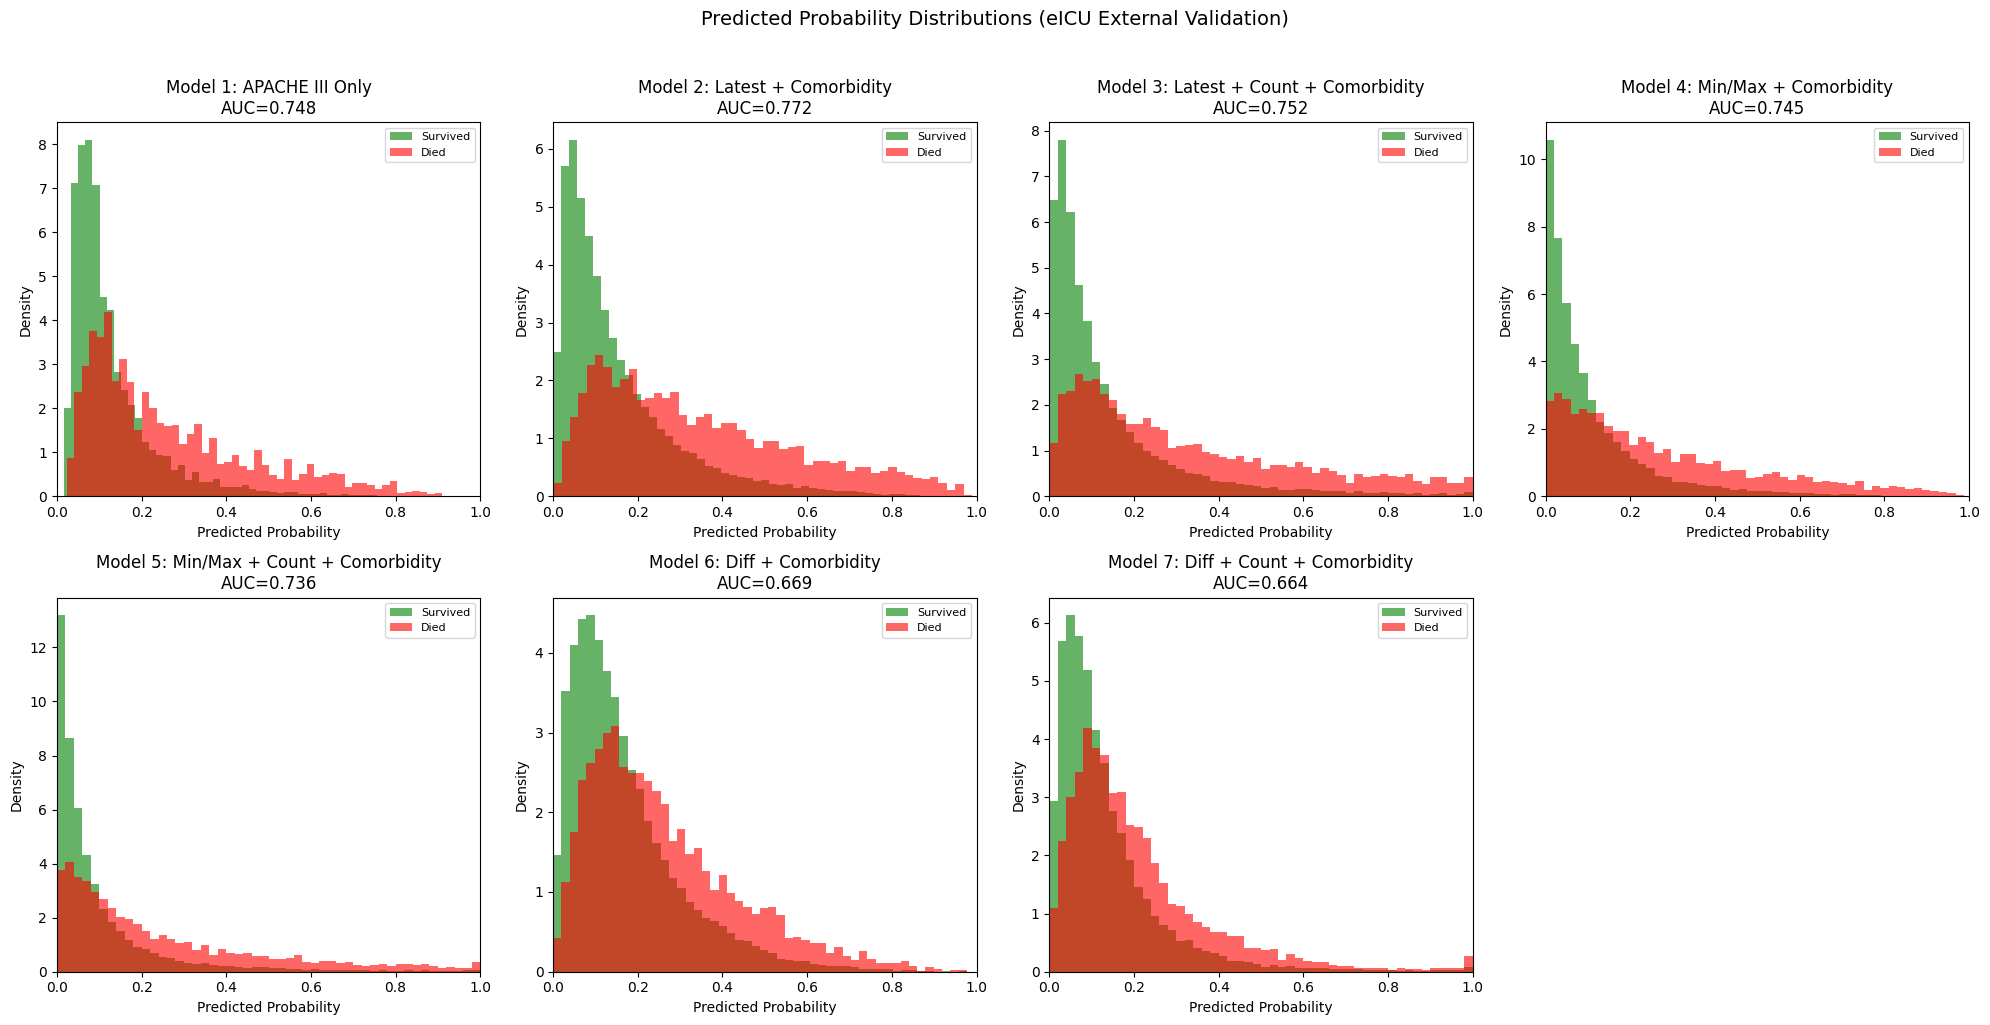

In [35]:
# Predicted Probability Distribution (External Validation)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (model_key, preds) in enumerate(predictions.items()):
    ax = axes[i]
    y_pred_ext = preds['y_ext_pred']
    ax.hist(y_pred_ext[y_ext == 0], bins=50, alpha=0.6, color='green', label='Survived', density=True)
    ax.hist(y_pred_ext[y_ext == 1], bins=50, alpha=0.6, color='red', label='Died', density=True)
    auc = roc_auc_score(y_ext, y_pred_ext)
    ax.set_title(f"{model_key}: {pipelines[model_key]['name']}\nAUC={auc:.3f}")
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1])

plt.suptitle('Predicted Probability Distributions (eICU External Validation)', fontsize=14, y=1.02)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Step 17: XGBoost Feature Importance

### What is Feature Importance?

XGBoost calculates feature importance based on how much each feature contributes to reducing prediction error across all trees in the ensemble.

- **Higher importance**: The feature is used more frequently and effectively in splitting decisions
- **Lower importance**: The feature contributes less to the model's predictions

Unlike logistic regression coefficients, feature importance does not indicate the **direction** of the relationship (positive or negative), only its **magnitude**.

Feature Importance: XGB Model 3 (Latest + Count + Comorbidity)


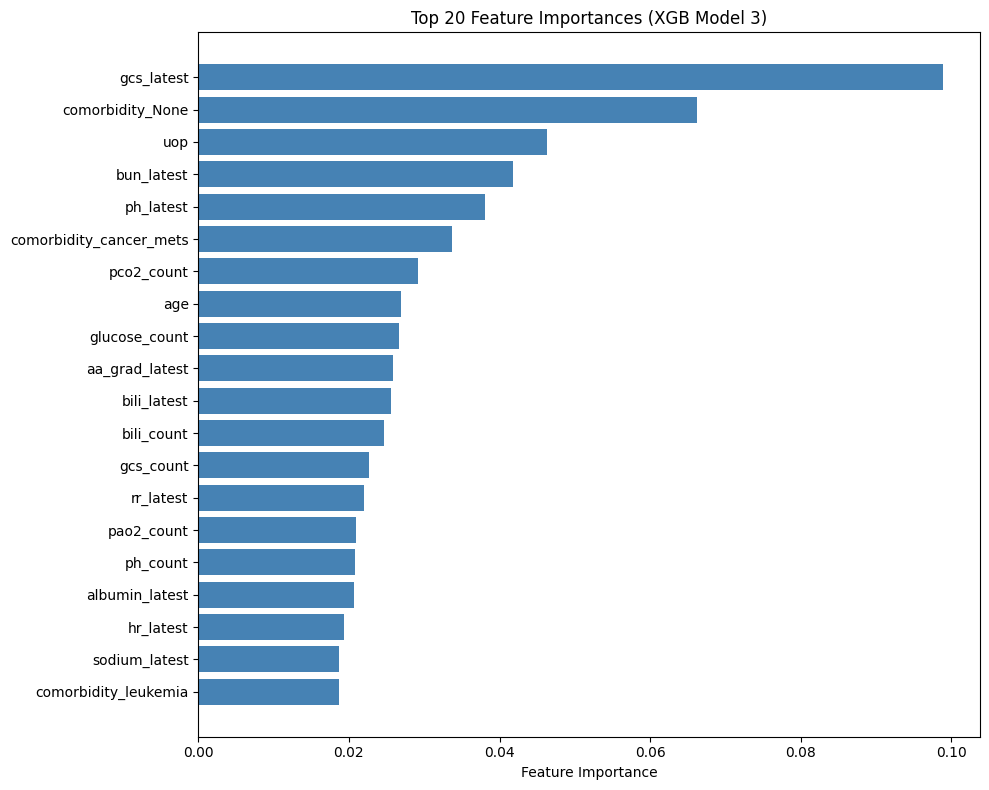

                Feature  Importance
             gcs_latest    0.098873
       comorbidity_None    0.066189
                    uop    0.046247
             bun_latest    0.041751
              ph_latest    0.038102
comorbidity_cancer_mets    0.033711
             pco2_count    0.029240
                    age    0.026912
          glucose_count    0.026712
         aa_grad_latest    0.025848
            bili_latest    0.025650
             bili_count    0.024646
              gcs_count    0.022717
              rr_latest    0.022025
             pao2_count    0.020949
               ph_count    0.020851
         albumin_latest    0.020693
              hr_latest    0.019341
          sodium_latest    0.018744
   comorbidity_leukemia    0.018701


In [36]:
# XGBoost Feature Importance (Best Model)
if xgb_pipelines:
    best_xgb_key = max(xgb_pipelines.keys(),
                       key=lambda k: roc_auc_score(y_test, xgb_predictions[k]['y_test_pred']))
    best_xgb = xgb_pipelines[best_xgb_key]

    print(f"Feature Importance: XGB {best_xgb_key} ({pipelines[best_xgb_key]['name']})")
    print("=" * 80)

    preprocessor = best_xgb.named_steps['preprocessor']
    xgb_classifier = best_xgb.named_steps['classifier']

    feat_names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'num':
            feat_names.extend(cols)
        elif name == 'cat':
            if hasattr(trans.named_steps.get('onehot', None), 'get_feature_names_out'):
                feat_names.extend(trans.named_steps['onehot'].get_feature_names_out(cols))
            else:
                feat_names.extend(cols)

    importances = xgb_classifier.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feat_names[:len(importances)],
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Plot top 20 features
    top_n = min(20, len(importance_df))
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = importance_df.head(top_n)
    ax.barh(range(top_n), top_features['Importance'].values, color='steelblue')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features['Feature'].values)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {top_n} Feature Importances (XGB {best_xgb_key})')
    plt.tight_layout()
    plt.show()

    print(importance_df.head(20).to_string(index=False))

## Step 18: Publication-Quality Outputs

This section exports all performance metrics and figures in publication-ready formats to `outputs/outputs_for_manuscript/`.

In calibration plot, 
- uniform: ‘A reliability diagram dividing the interval from 0 to 1 into 10 equally spaced bins’  
- quantile: ‘A reliability diagram dividing the distribution of predicted probabilities into 10 quantiles (roughly equal numbers)’  

### Outputs Generated

| File | Description |
|------|-------------|
| `Table_LR_performance.csv` | Logistic regression performance (AUROC, AUPRC, Brier, Optimism) |
| `Table_XGB_performance.csv` | XGBoost performance (AUROC, AUPRC, Brier, Optimism) |
| `Table_LR_vs_XGB_comparison.csv` | Side-by-side LR vs XGBoost comparison |
| `Table_external_validation_performance.csv` | External validation with Delta AUROC |
| `Table_calibration_metrics.csv` | Calibration slope, intercept, Brier score |
| `Table_threshold_metrics.csv` | Accuracy, Sensitivity, Specificity, PPV, NPV, F1 |
| `Table_LR_coefficients.csv` | Logistic regression coefficients and odds ratios |
| `Figure_ROC_test_vs_external.png/pdf` | ROC curves: internal test vs external |
| `Figure_Calibration_external_validation.png/pdf` | Calibration plots |
| `Figure_PRC_external_validation.png/pdf` | Precision-recall curves |
| `Figure_domain_shift_bar.png/pdf` | Domain shift bar chart |
| `Figure_predicted_probability_distribution.png/pdf` | Predicted probability histograms |
| `Figure_XGB_feature_importance.png/pdf` | XGBoost feature importance |


In [37]:
# ============================================================
# Step 18: Publication-Quality Outputs — Table 2
# ============================================================
from pathlib import Path

OUT_DIR = Path('../outputs/outputs_for_manuscript')
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5', 'Model 6', 'Model 7']

# --- Helper: format values with CI ---
def fmt_ci(point, lo, hi):
    return f"{point:.3f} ({lo:.3f}\u2013{hi:.3f})"

def fmt_delta_ci(point, lo, hi):
    sign = '+' if point >= 0 else ''
    return f"{sign}{point:.3f} ({lo:.3f}\u2013{hi:.3f})"

# --- Helper: save DataFrame as Word table ---
def save_table_as_docx(df, title, footnotes_str, filepath):
    doc = Document()
    # Title
    p = doc.add_paragraph()
    run = p.add_run(title)
    run.bold = True
    run.font.size = Pt(11)
    # Table
    table = doc.add_table(rows=len(df) + 1, cols=len(df.columns), style='Table Grid')
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    for j, col in enumerate(df.columns):
        cell = table.rows[0].cells[j]
        cell.text = str(col)
        for paragraph in cell.paragraphs:
            for run in paragraph.runs:
                run.bold = True
                run.font.size = Pt(8)
    for i, (_, row) in enumerate(df.iterrows()):
        for j, val in enumerate(row):
            cell = table.rows[i + 1].cells[j]
            cell.text = str(val)
            for paragraph in cell.paragraphs:
                for run in paragraph.runs:
                    run.font.size = Pt(8)
    doc.add_paragraph()
    p = doc.add_paragraph()
    run = p.add_run(footnotes_str)
    run.font.size = Pt(8)
    run.italic = True
    doc.save(filepath)

# --- Compute Table 2 ---
print("=" * 60)
print("Computing Table 2: Domain Shift Performance")
print("=" * 60)

rows_table2 = []
for algo_name in ['Logistic regression', 'XGBoost']:
    for mk in MODEL_ORDER:
        config = pipelines[mk]
        print(f"  {algo_name} - {mk}...")

        if algo_name == 'Logistic regression':
            pipe = config['pipeline']
        else:
            if mk not in xgb_pipelines:
                print(f"    Skipped (no XGBoost model)")
                continue
            pipe = xgb_pipelines[mk]

        y_pred_train = pipe.predict_proba(config['X_train'])[:, 1]
        y_pred_test = pipe.predict_proba(config['X_test'])[:, 1]
        y_pred_ext = pipe.predict_proba(config['X_ext'])[:, 1]
        n_predictors = len(config['X_train'].columns)

        # AUROC
        auroc_int = bootstrap_ci(y_test, y_pred_test, roc_auc_score)
        auroc_ext = bootstrap_ci(y_ext, y_pred_ext, roc_auc_score)
        d_auroc = bootstrap_delta_ci(y_test, y_pred_test, y_ext, y_pred_ext, roc_auc_score)

        # AUPRC
        auprc_int = bootstrap_ci(y_test, y_pred_test, average_precision_score)
        auprc_ext = bootstrap_ci(y_ext, y_pred_ext, average_precision_score)
        d_auprc = bootstrap_delta_ci(y_test, y_pred_test, y_ext, y_pred_ext, average_precision_score)

        # Brier
        brier_int = bootstrap_ci(y_test, y_pred_test, brier_score_loss)
        brier_ext = bootstrap_ci(y_ext, y_pred_ext, brier_score_loss)
        d_brier = bootstrap_delta_ci(y_test, y_pred_test, y_ext, y_pred_ext, brier_score_loss)

        # Calibration (external only)
        cal = bootstrap_calibration_ci(y_ext, y_pred_ext)
        # cal = (slope, slope_lo, slope_hi, intercept, int_lo, int_hi)

        # Overfitting gap
        train_auroc = roc_auc_score(y_train, y_pred_train)
        overfitting_gap = train_auroc - auroc_int[0]

        rows_table2.append({
            'Algorithm': algo_name,
            'Model ID': mk,
            'Feature set (specification)': config['name'],
            '# Predictors': n_predictors,
            'AUROC (Internal, 95% CI)': fmt_ci(*auroc_int),
            'AUROC (External, 95% CI)': fmt_ci(*auroc_ext),
            '\u0394AUROC (External \u2212 Internal, 95% CI)': fmt_delta_ci(*d_auroc),
            'AUPRC (Internal, 95% CI)': fmt_ci(*auprc_int),
            'AUPRC (External, 95% CI)': fmt_ci(*auprc_ext),
            '\u0394AUPRC (External \u2212 Internal, 95% CI)': fmt_delta_ci(*d_auprc),
            'Brier (Internal, 95% CI)': fmt_ci(*brier_int),
            'Brier (External, 95% CI)': fmt_ci(*brier_ext),
            '\u0394Brier (External \u2212 Internal, 95% CI)': fmt_delta_ci(*d_brier),
            'Calibration intercept in external (CITL, 95% CI)': fmt_ci(cal[3], cal[4], cal[5]),
            'Calibration slope in external (95% CI)': fmt_ci(cal[0], cal[1], cal[2]),
            'Overfitting gap (Train \u2212 Internal AUROC)': f"{overfitting_gap:.3f}",
        })

df_table2 = pd.DataFrame(rows_table2)
display(df_table2)

# --- Footnotes ---
prev_int = y_test.mean()
prev_ext = y_ext.mean()
FOOTNOTES_TABLE2 = (
    f"Abbreviations: AUROC, area under the receiver operating characteristic curve; "
    f"AUPRC, area under the precision\u2013recall curve; CITL, calibration-in-the-large; "
    f"CI, confidence interval.\n"
    f"1. Internal validation: held-out MIMIC-IV test set (40%). "
    f"External validation: independent eICU cohort.\n"
    f"2. \u0394 = External \u2212 Internal. Negative \u0394 indicates performance degradation (domain shift).\n"
    f"3. 95% CIs: bootstrap resampling (B = {N_BOOT}, percentile method). "
    f"\u0394 CIs from bootstrap distribution of the difference.\n"
    f"4. Calibration via logistic recalibration: logit(Y) = \u03b1 + \u03b2\u00b7logit(p\u0302). "
    f"Ideal: CITL = 0, slope = 1.\n"
    f"5. Brier score: lower is better. \u0394Brier > 0 = worse external performance.\n"
    f"6. Outcome prevalence: internal = {prev_int:.1%}; external = {prev_ext:.1%}. "
    f"AUPRC is prevalence-dependent.\n"
    f"7. Overfitting gap = Train AUROC \u2212 Internal AUROC.\n"
    f"8. Consistent preprocessing across internal and external datasets."
)

# Save .md
md_text = "### Table 2. Internal-to-external validation performance (domain shift) across model specifications and algorithms\n\n"
md_text += df_table2.to_markdown(index=False)
md_text += "\n\n" + FOOTNOTES_TABLE2
with open(OUT_DIR / 'Table_domain_shift_performance.md', 'w', encoding='utf-8') as f:
    f.write(md_text)
print("\nSaved: Table_domain_shift_performance.md")

# Save .docx
save_table_as_docx(
    df_table2,
    'Table 2. Internal-to-external validation performance (domain shift) across model specifications and algorithms',
    FOOTNOTES_TABLE2,
    OUT_DIR / 'Table_domain_shift_performance.docx'
)
print("Saved: Table_domain_shift_performance.docx")


Computing Table 2: Domain Shift Performance
  Logistic regression - Model 1...
  Logistic regression - Model 2...
  Logistic regression - Model 3...
  Logistic regression - Model 4...
  Logistic regression - Model 5...
  Logistic regression - Model 6...
  Logistic regression - Model 7...
  XGBoost - Model 1...
  XGBoost - Model 2...
  XGBoost - Model 3...
  XGBoost - Model 4...
  XGBoost - Model 5...
  XGBoost - Model 6...
  XGBoost - Model 7...


,Algorithm,Model ID,Feature set (specification),# Predictors,"AUROC (Internal, 95% CI)","AUROC (External, 95% CI)","ΔAUROC (External − Internal, 95% CI)","AUPRC (Internal, 95% CI)","AUPRC (External, 95% CI)","ΔAUPRC (External − Internal, 95% CI)","Brier (Internal, 95% CI)","Brier (External, 95% CI)","ΔBrier (External − Internal, 95% CI)","Calibration intercept in external (CITL, 95% CI)",Calibration slope in external (95% CI),Overfitting gap (Train − Internal AUROC)
0,Logistic regression,Model 1,APACHE III Only,1,0.731 (0.719–0.743),0.748 (0.740–0.755),+0.017 (0.002–0.031),0.373 (0.353–0.396),0.377 (0.363–0.392),+0.004 (-0.024–0.029),0.121 (0.118–0.126),0.104 (0.102–0.107),-0.017 (-0.022–-0.012),-0.065 (-0.128–-0.001),1.007 (0.971–1.044),0.008
1,Logistic regression,Model 2,Latest + Comorbidity,21,0.819 (0.809–0.829),0.772 (0.764–0.779),-0.047 (-0.059–-0.035),0.490 (0.467–0.514),0.397 (0.382–0.412),-0.093 (-0.121–-0.065),0.108 (0.105–0.112),0.106 (0.104–0.108),-0.002 (-0.007–0.002),-0.519 (-0.567–-0.473),0.874 (0.843–0.904),0.006
2,Logistic regression,Model 3,Latest + Count + Comorbidity,39,0.834 (0.824–0.843),0.752 (0.744–0.759),-0.082 (-0.093–-0.070),0.509 (0.486–0.533),0.340 (0.326–0.354),-0.169 (-0.196–-0.140),0.106 (0.102–0.109),0.113 (0.110–0.115),+0.007 (0.002–0.011),-0.804 (-0.857–-0.749),0.582 (0.555–0.609),0.009
3,Logistic regression,Model 4,Min/Max + Comorbidity,39,0.820 (0.810–0.829),0.745 (0.737–0.753),-0.074 (-0.086–-0.062),0.474 (0.451–0.501),0.365 (0.350–0.381),-0.109 (-0.137–-0.082),0.109 (0.106–0.113),0.107 (0.104–0.109),-0.003 (-0.007–0.002),-0.479 (-0.533–-0.424),0.649 (0.622–0.676),0.006
4,Logistic regression,Model 5,Min/Max + Count + Comorbidity,57,0.831 (0.822–0.840),0.736 (0.727–0.744),-0.096 (-0.108–-0.083),0.498 (0.475–0.524),0.319 (0.307–0.333),-0.179 (-0.206–-0.151),0.106 (0.103–0.110),0.113 (0.110–0.116),+0.006 (0.002–0.011),-0.649 (-0.710–-0.586),0.505 (0.480–0.530),0.006
5,Logistic regression,Model 6,Diff + Comorbidity,21,0.768 (0.757–0.779),0.669 (0.661–0.677),-0.098 (-0.112–-0.084),0.381 (0.361–0.404),0.250 (0.240–0.262),-0.131 (-0.157–-0.106),0.119 (0.115–0.123),0.121 (0.118–0.123),+0.002 (-0.003–0.006),-0.895 (-0.952–-0.840),0.593 (0.558–0.628),0.008
6,Logistic regression,Model 7,Diff + Count + Comorbidity,39,0.789 (0.780–0.799),0.664 (0.655–0.672),-0.125 (-0.139–-0.112),0.415 (0.394–0.440),0.231 (0.222–0.241),-0.184 (-0.209–-0.159),0.115 (0.112–0.119),0.122 (0.119–0.124),+0.006 (0.002–0.011),-1.013 (-1.081–-0.942),0.417 (0.385–0.451),0.007
7,XGBoost,Model 1,APACHE III Only,1,0.730 (0.718–0.742),0.748 (0.740–0.755),+0.018 (0.003–0.032),0.372 (0.352–0.394),0.376 (0.361–0.391),+0.004 (-0.024–0.030),0.121 (0.118–0.126),0.104 (0.102–0.107),-0.017 (-0.022–-0.012),-0.003 (-0.067–0.062),1.046 (1.008–1.084),0.010
8,XGBoost,Model 2,Latest + Comorbidity,21,0.849 (0.840–0.858),0.801 (0.794–0.808),-0.048 (-0.059–-0.037),0.544 (0.521–0.569),0.452 (0.437–0.468),-0.092 (-0.121–-0.064),0.101 (0.098–0.105),0.099 (0.097–0.101),-0.002 (-0.007–0.002),-0.373 (-0.422–-0.325),0.898 (0.869–0.926),0.071
9,XGBoost,Model 3,Latest + Count + Comorbidity,39,0.859 (0.851–0.868),0.805 (0.798–0.811),-0.055 (-0.065–-0.044),0.562 (0.539–0.586),0.462 (0.446–0.477),-0.100 (-0.129–-0.072),0.099 (0.095–0.102),0.098 (0.095–0.100),-0.001 (-0.006–0.003),-0.307 (-0.359–-0.258),0.927 (0.898–0.955),0.072



Saved: Table_domain_shift_performance.md
Saved: Table_domain_shift_performance.docx


Creating Figure 2a...
Saved: Figure_2a_delta_AUROC_vs_complexity.png


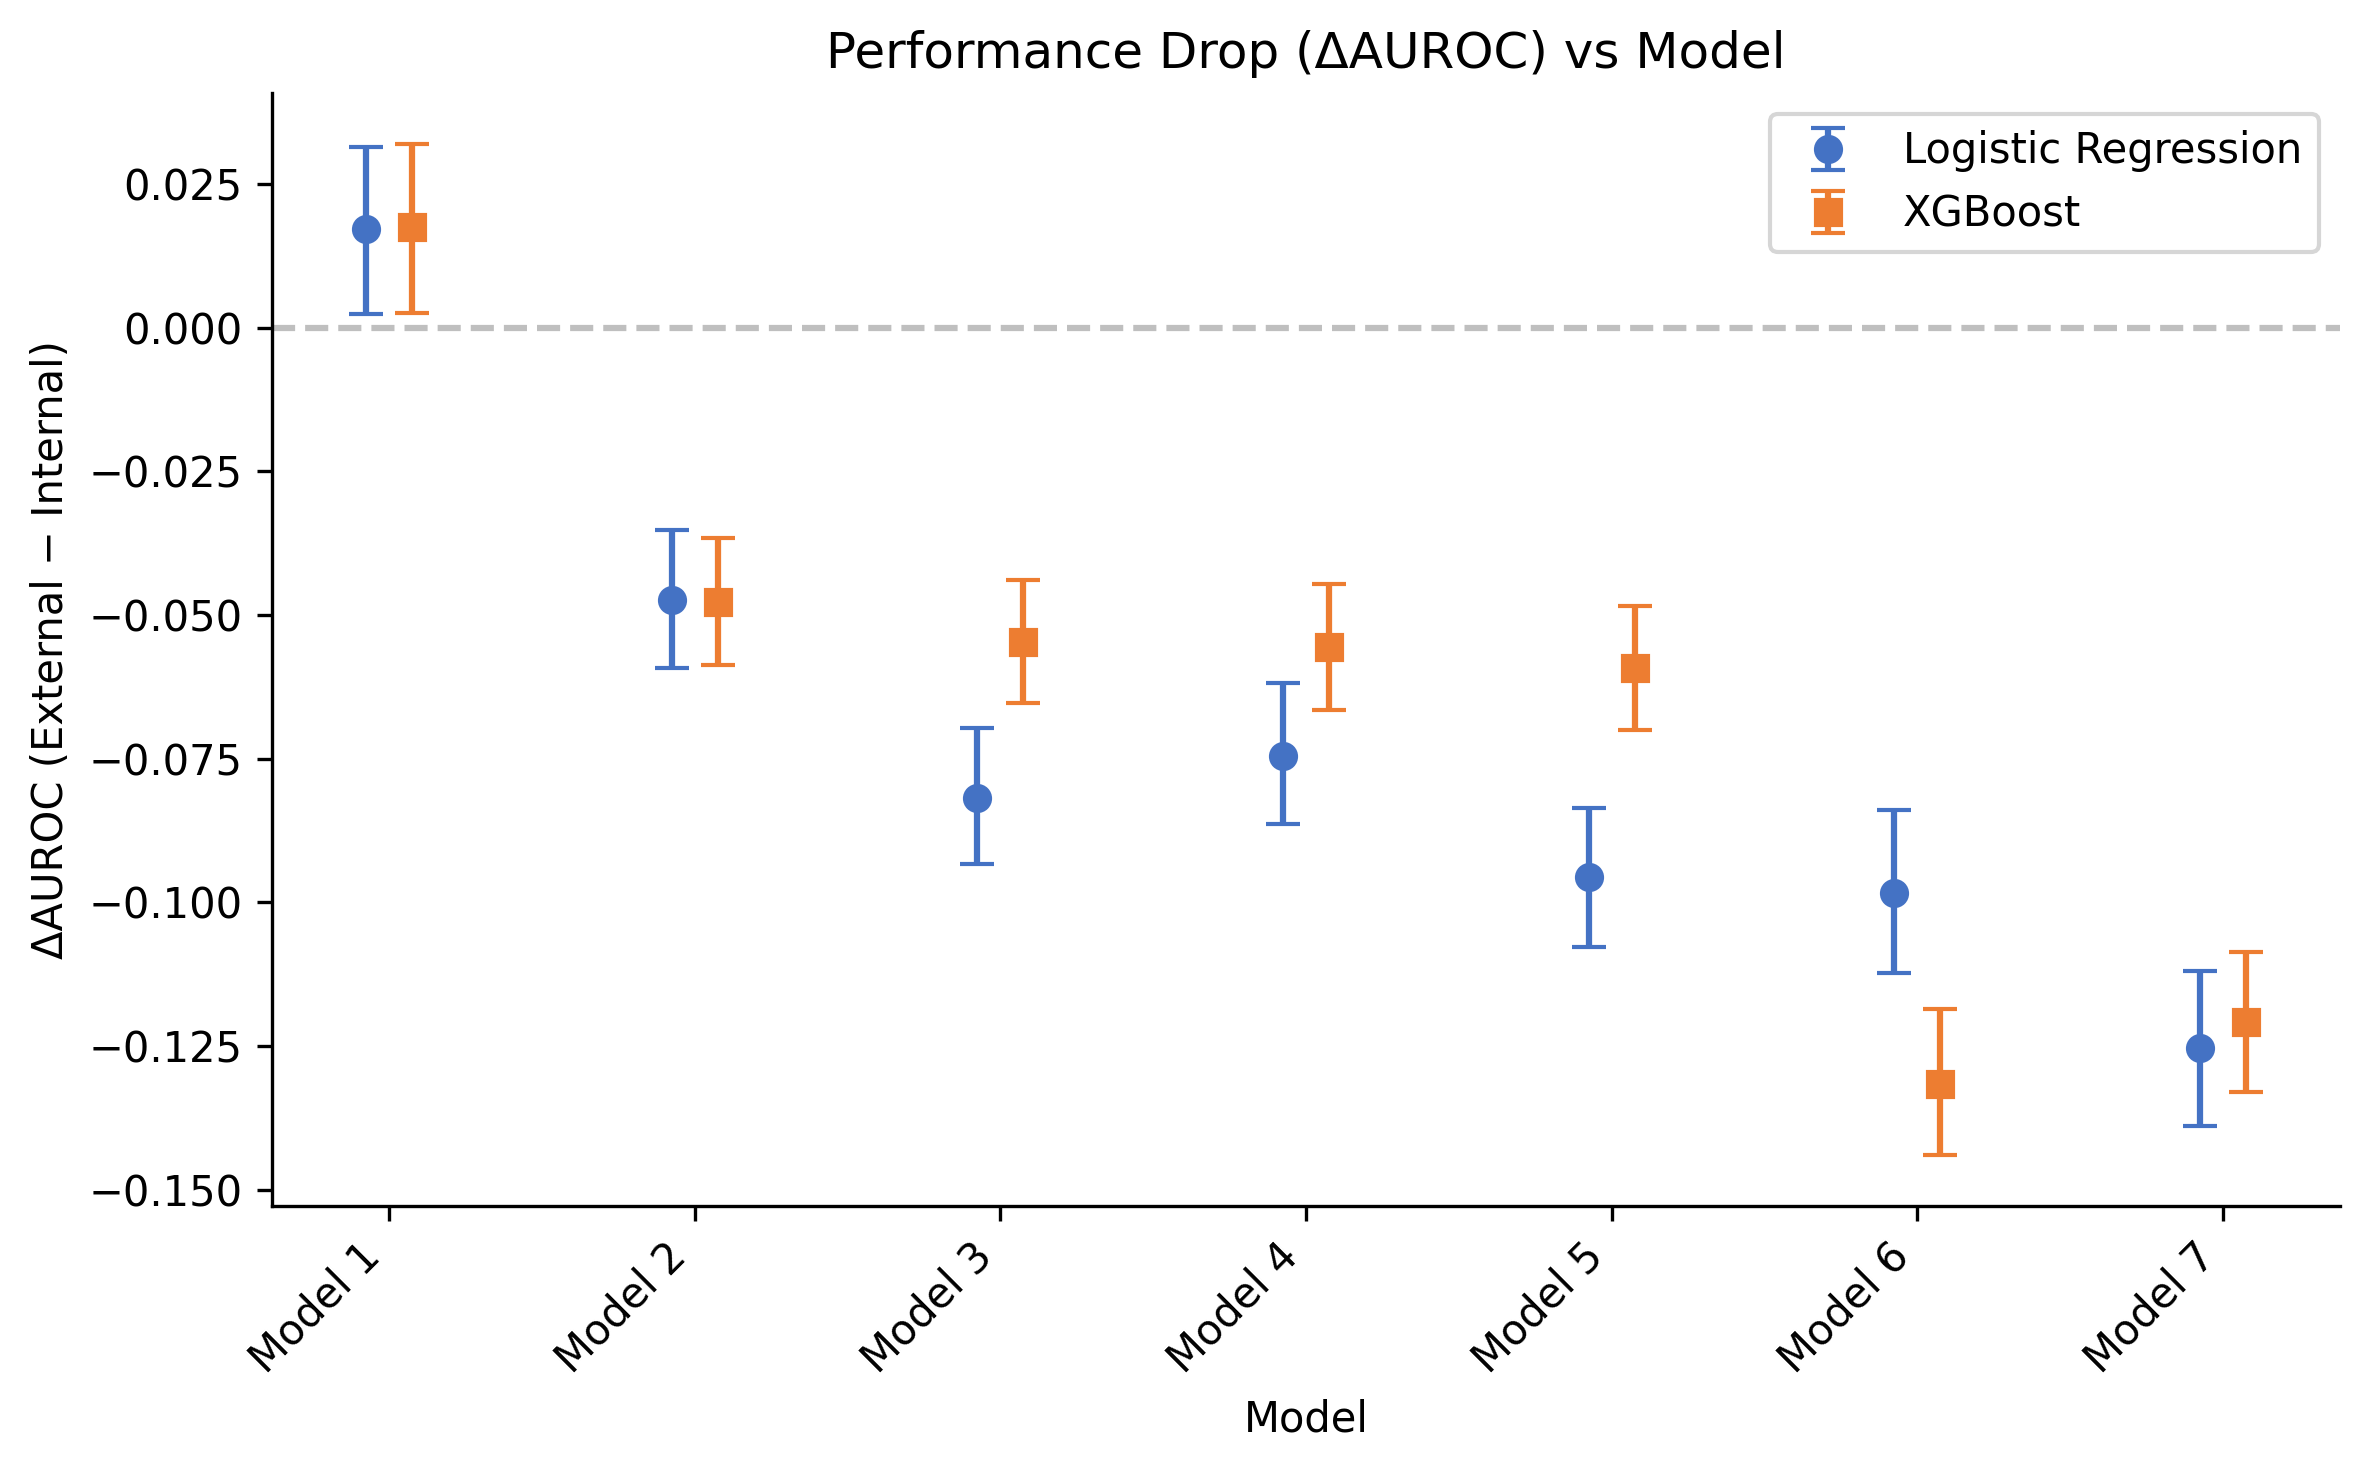

Creating Figure 2b...
Saved: Figure_2b_delta_AUPRC_vs_complexity.png


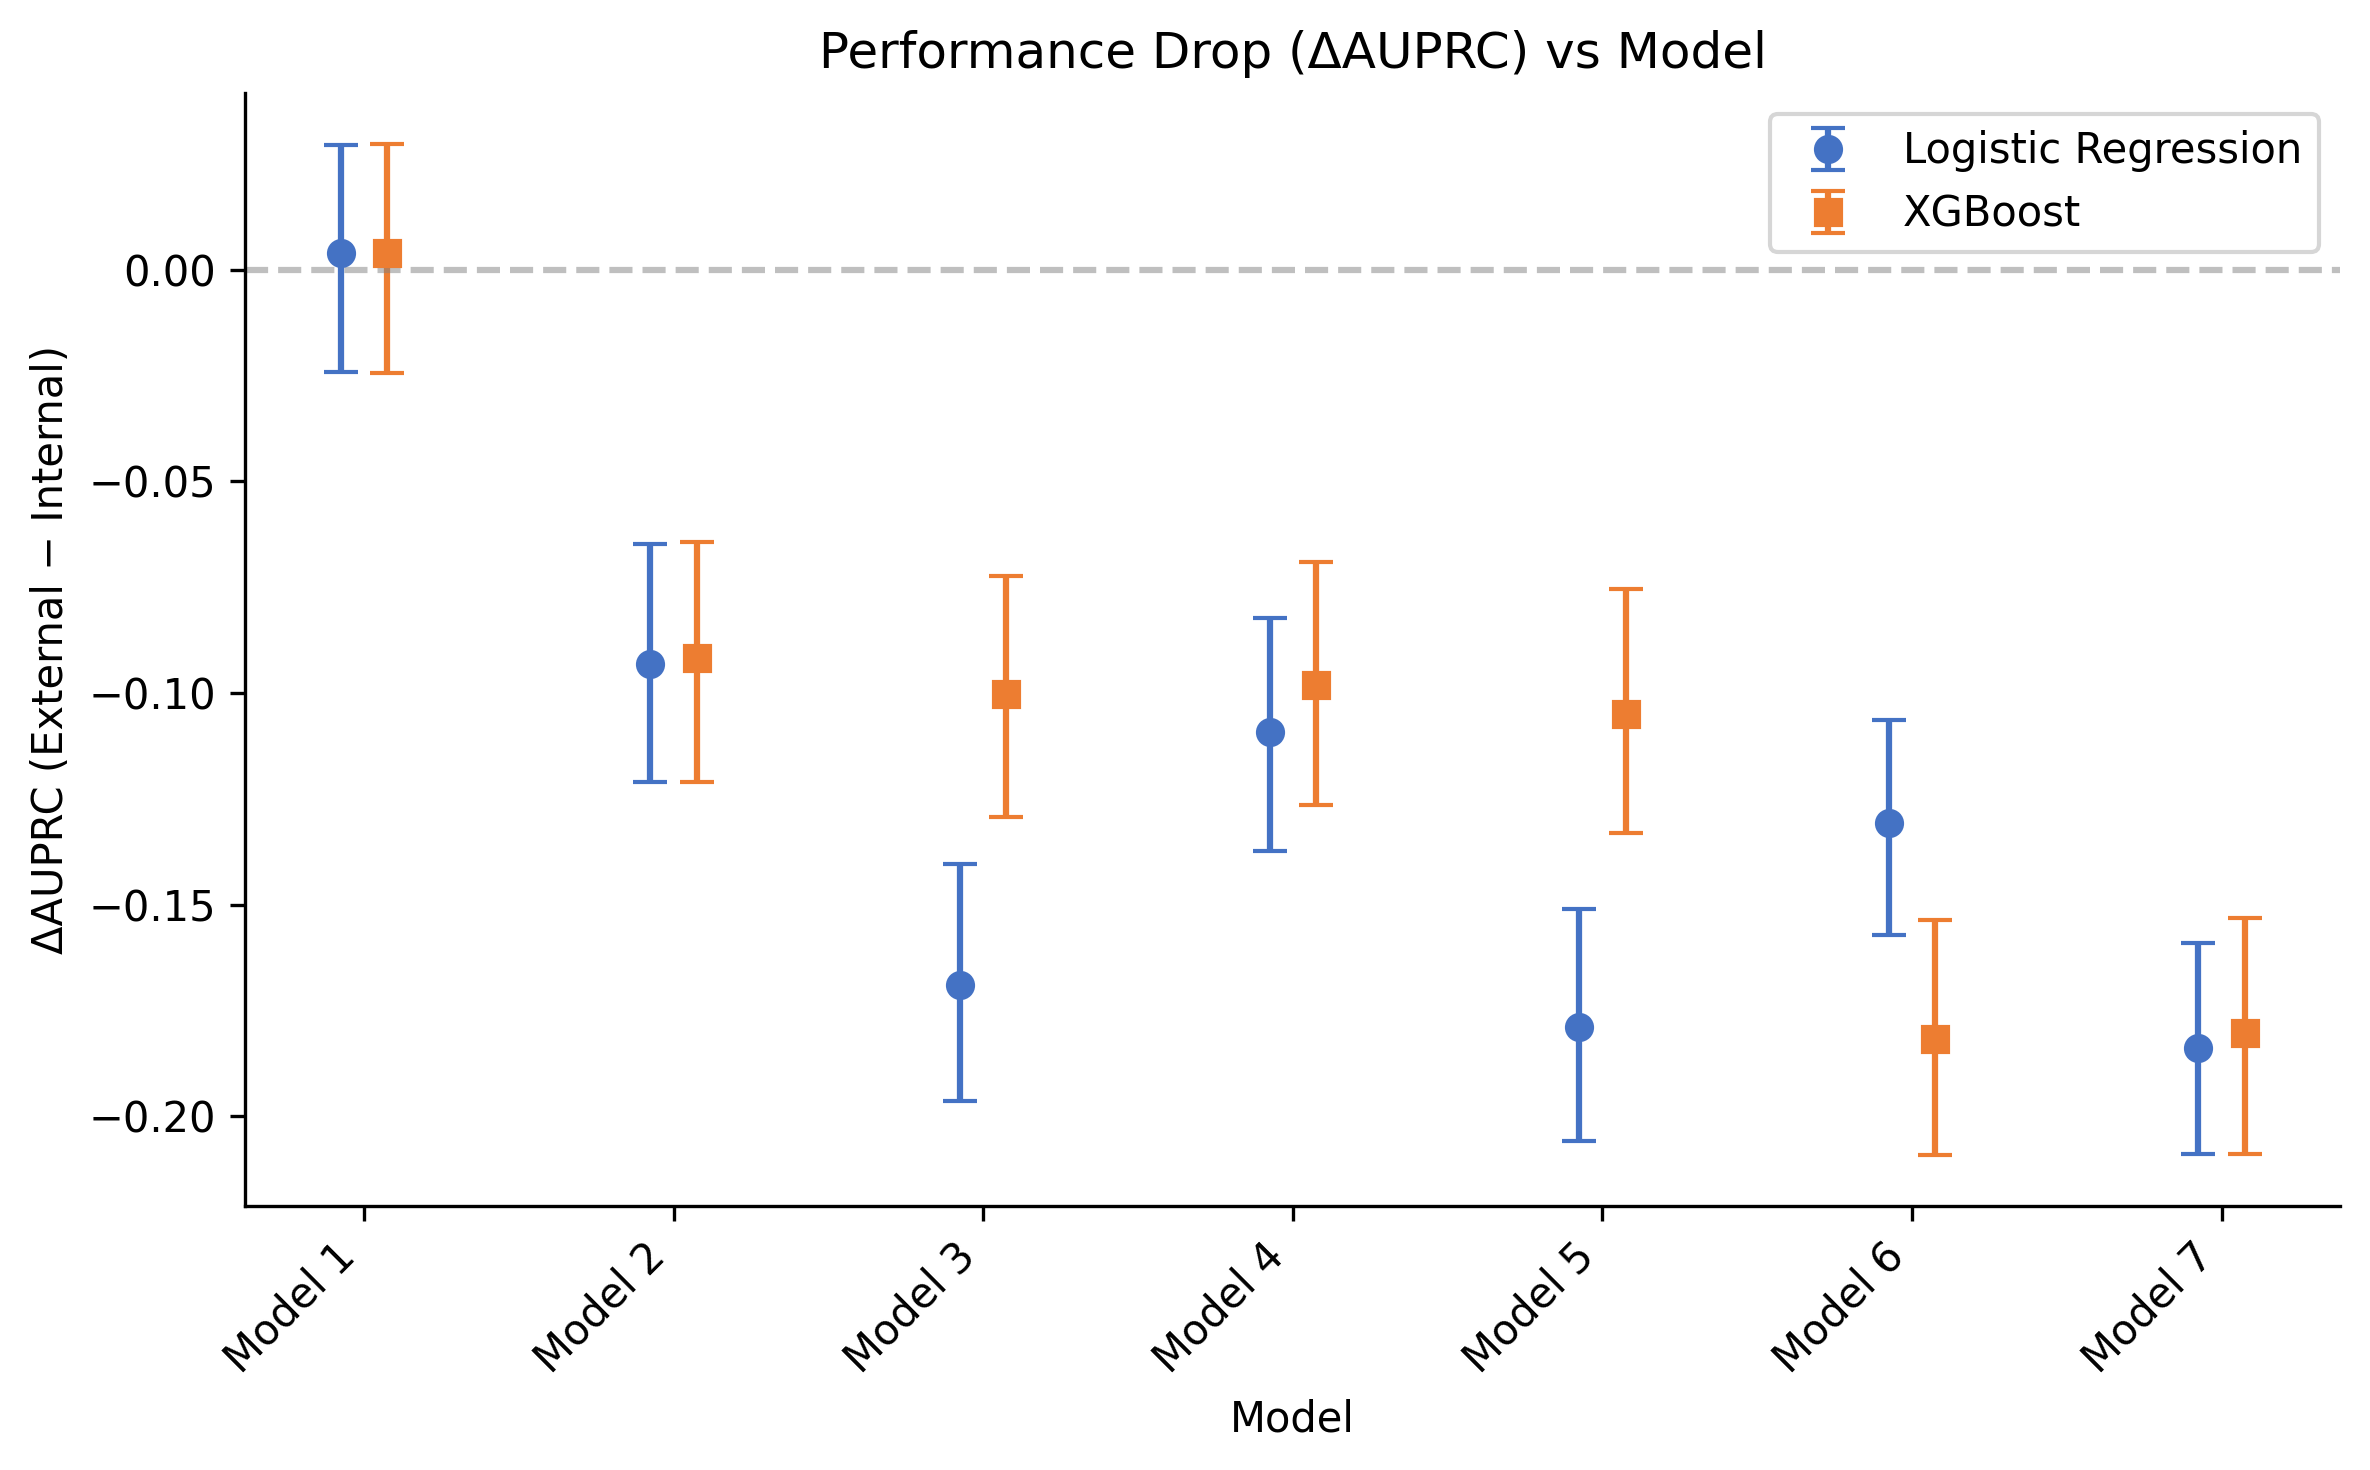

Creating Figure 3...
Saved: Figure_3_Calibration_external_LR.png


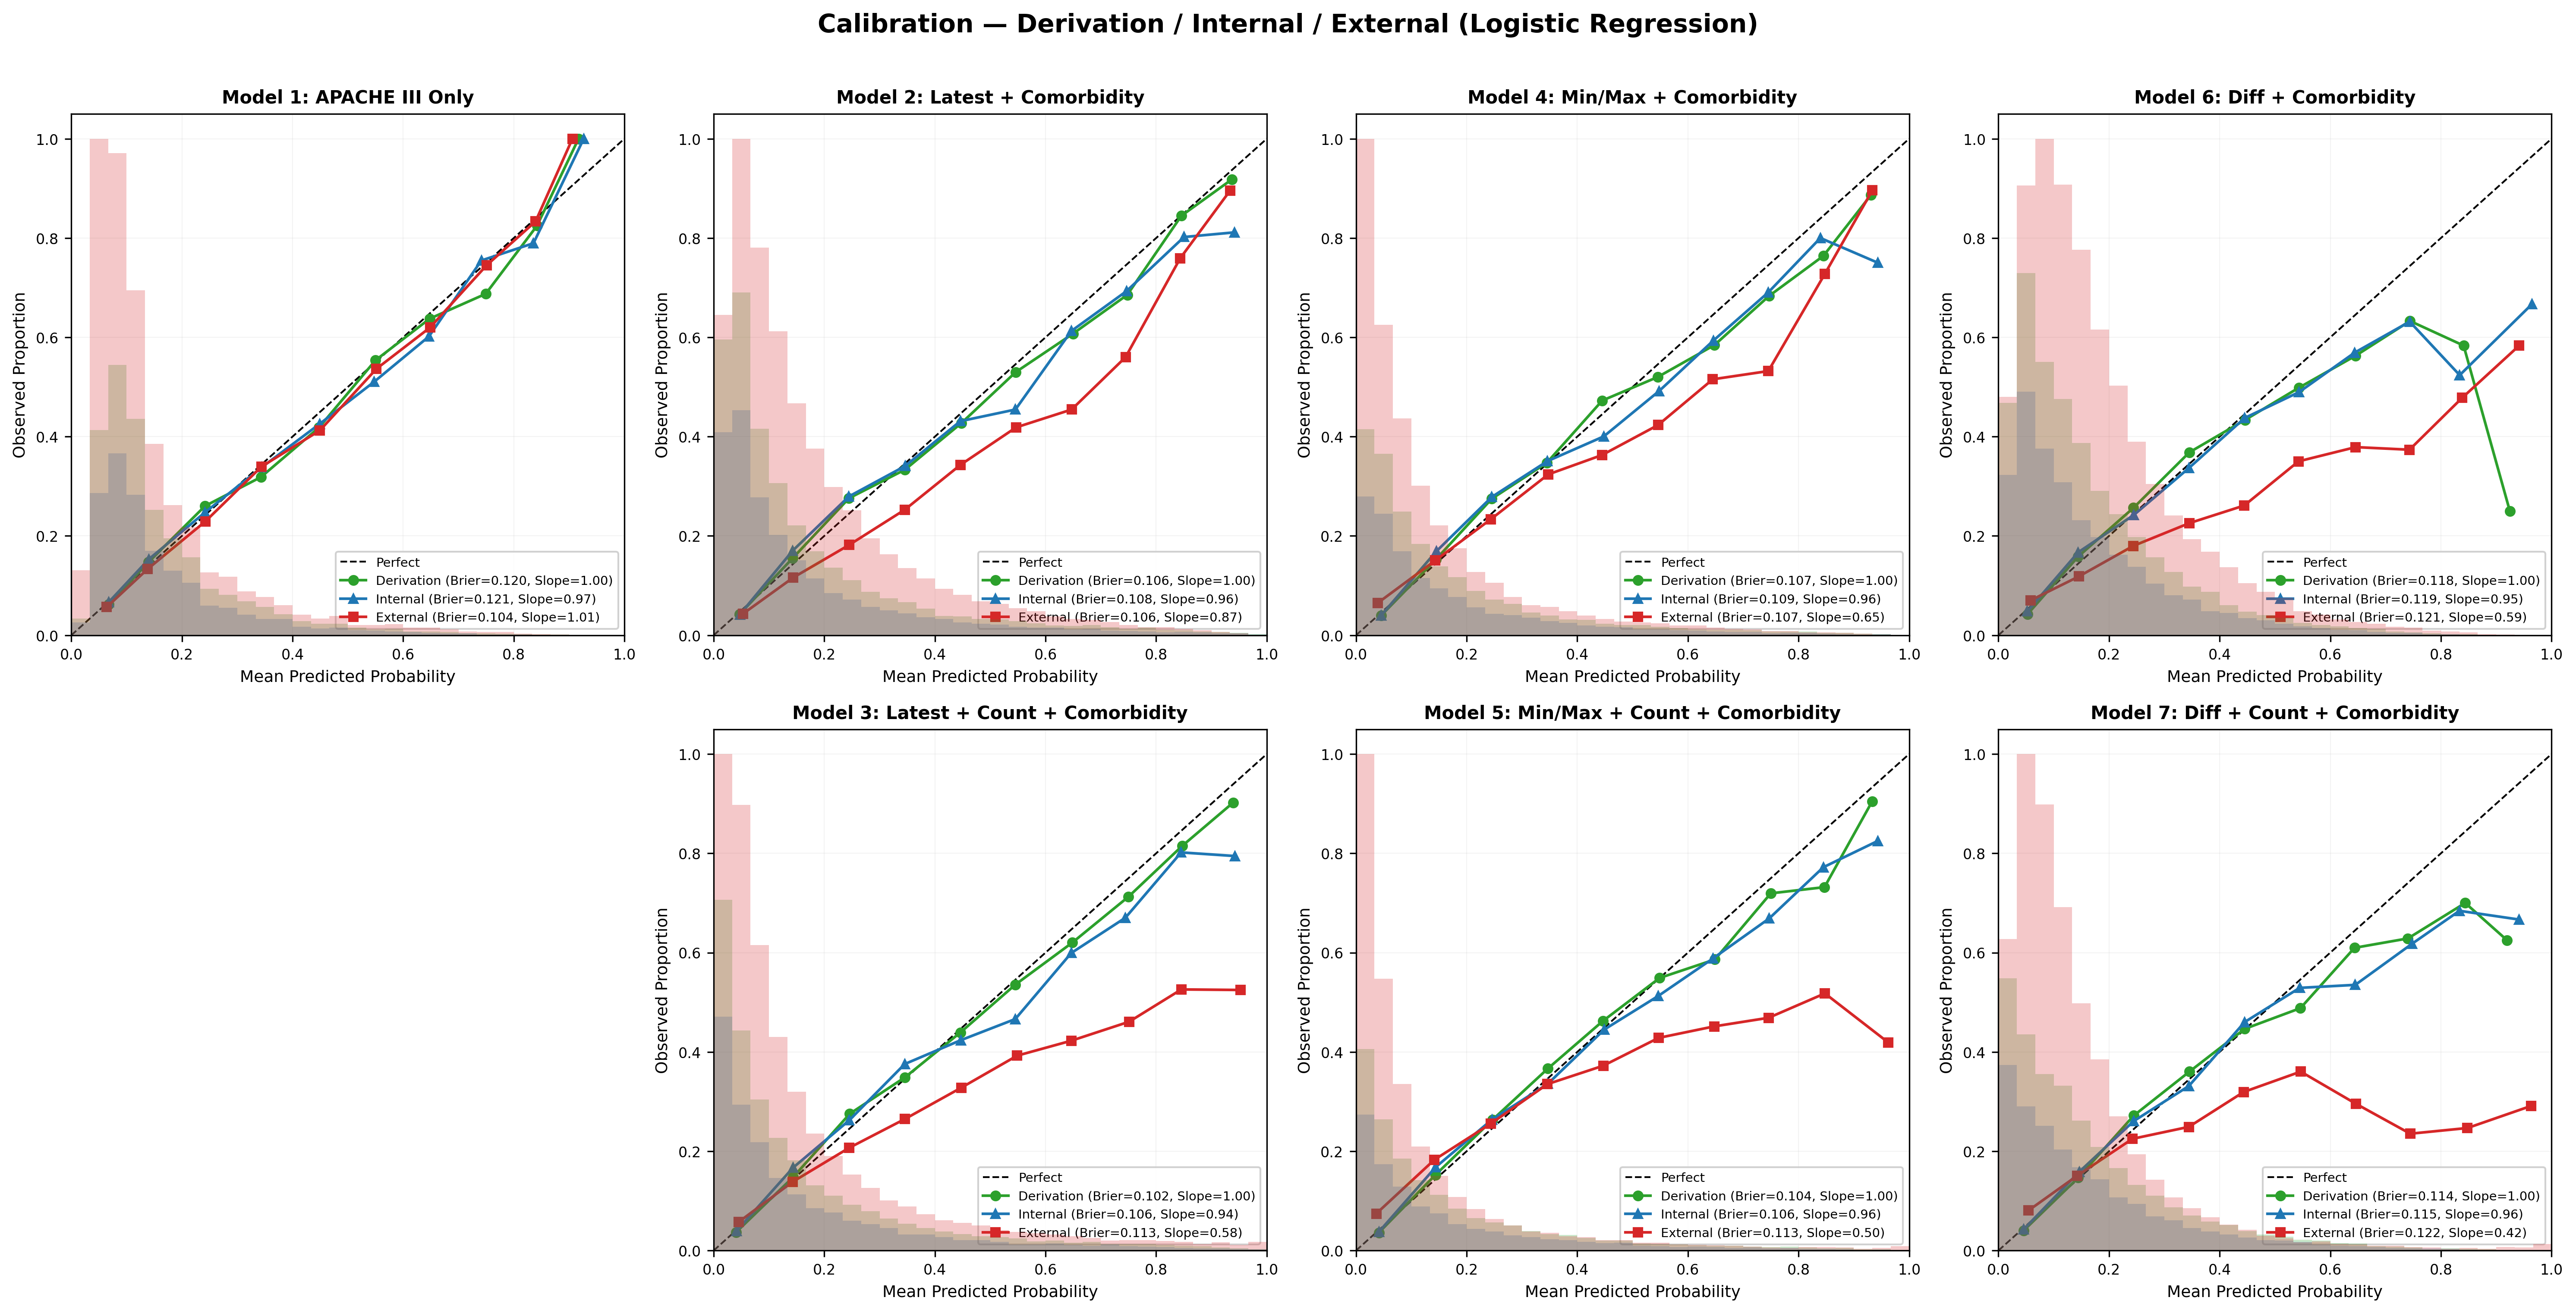

Creating Figure 4...
Saved: Figure_4_Calibration_external_XGB.png


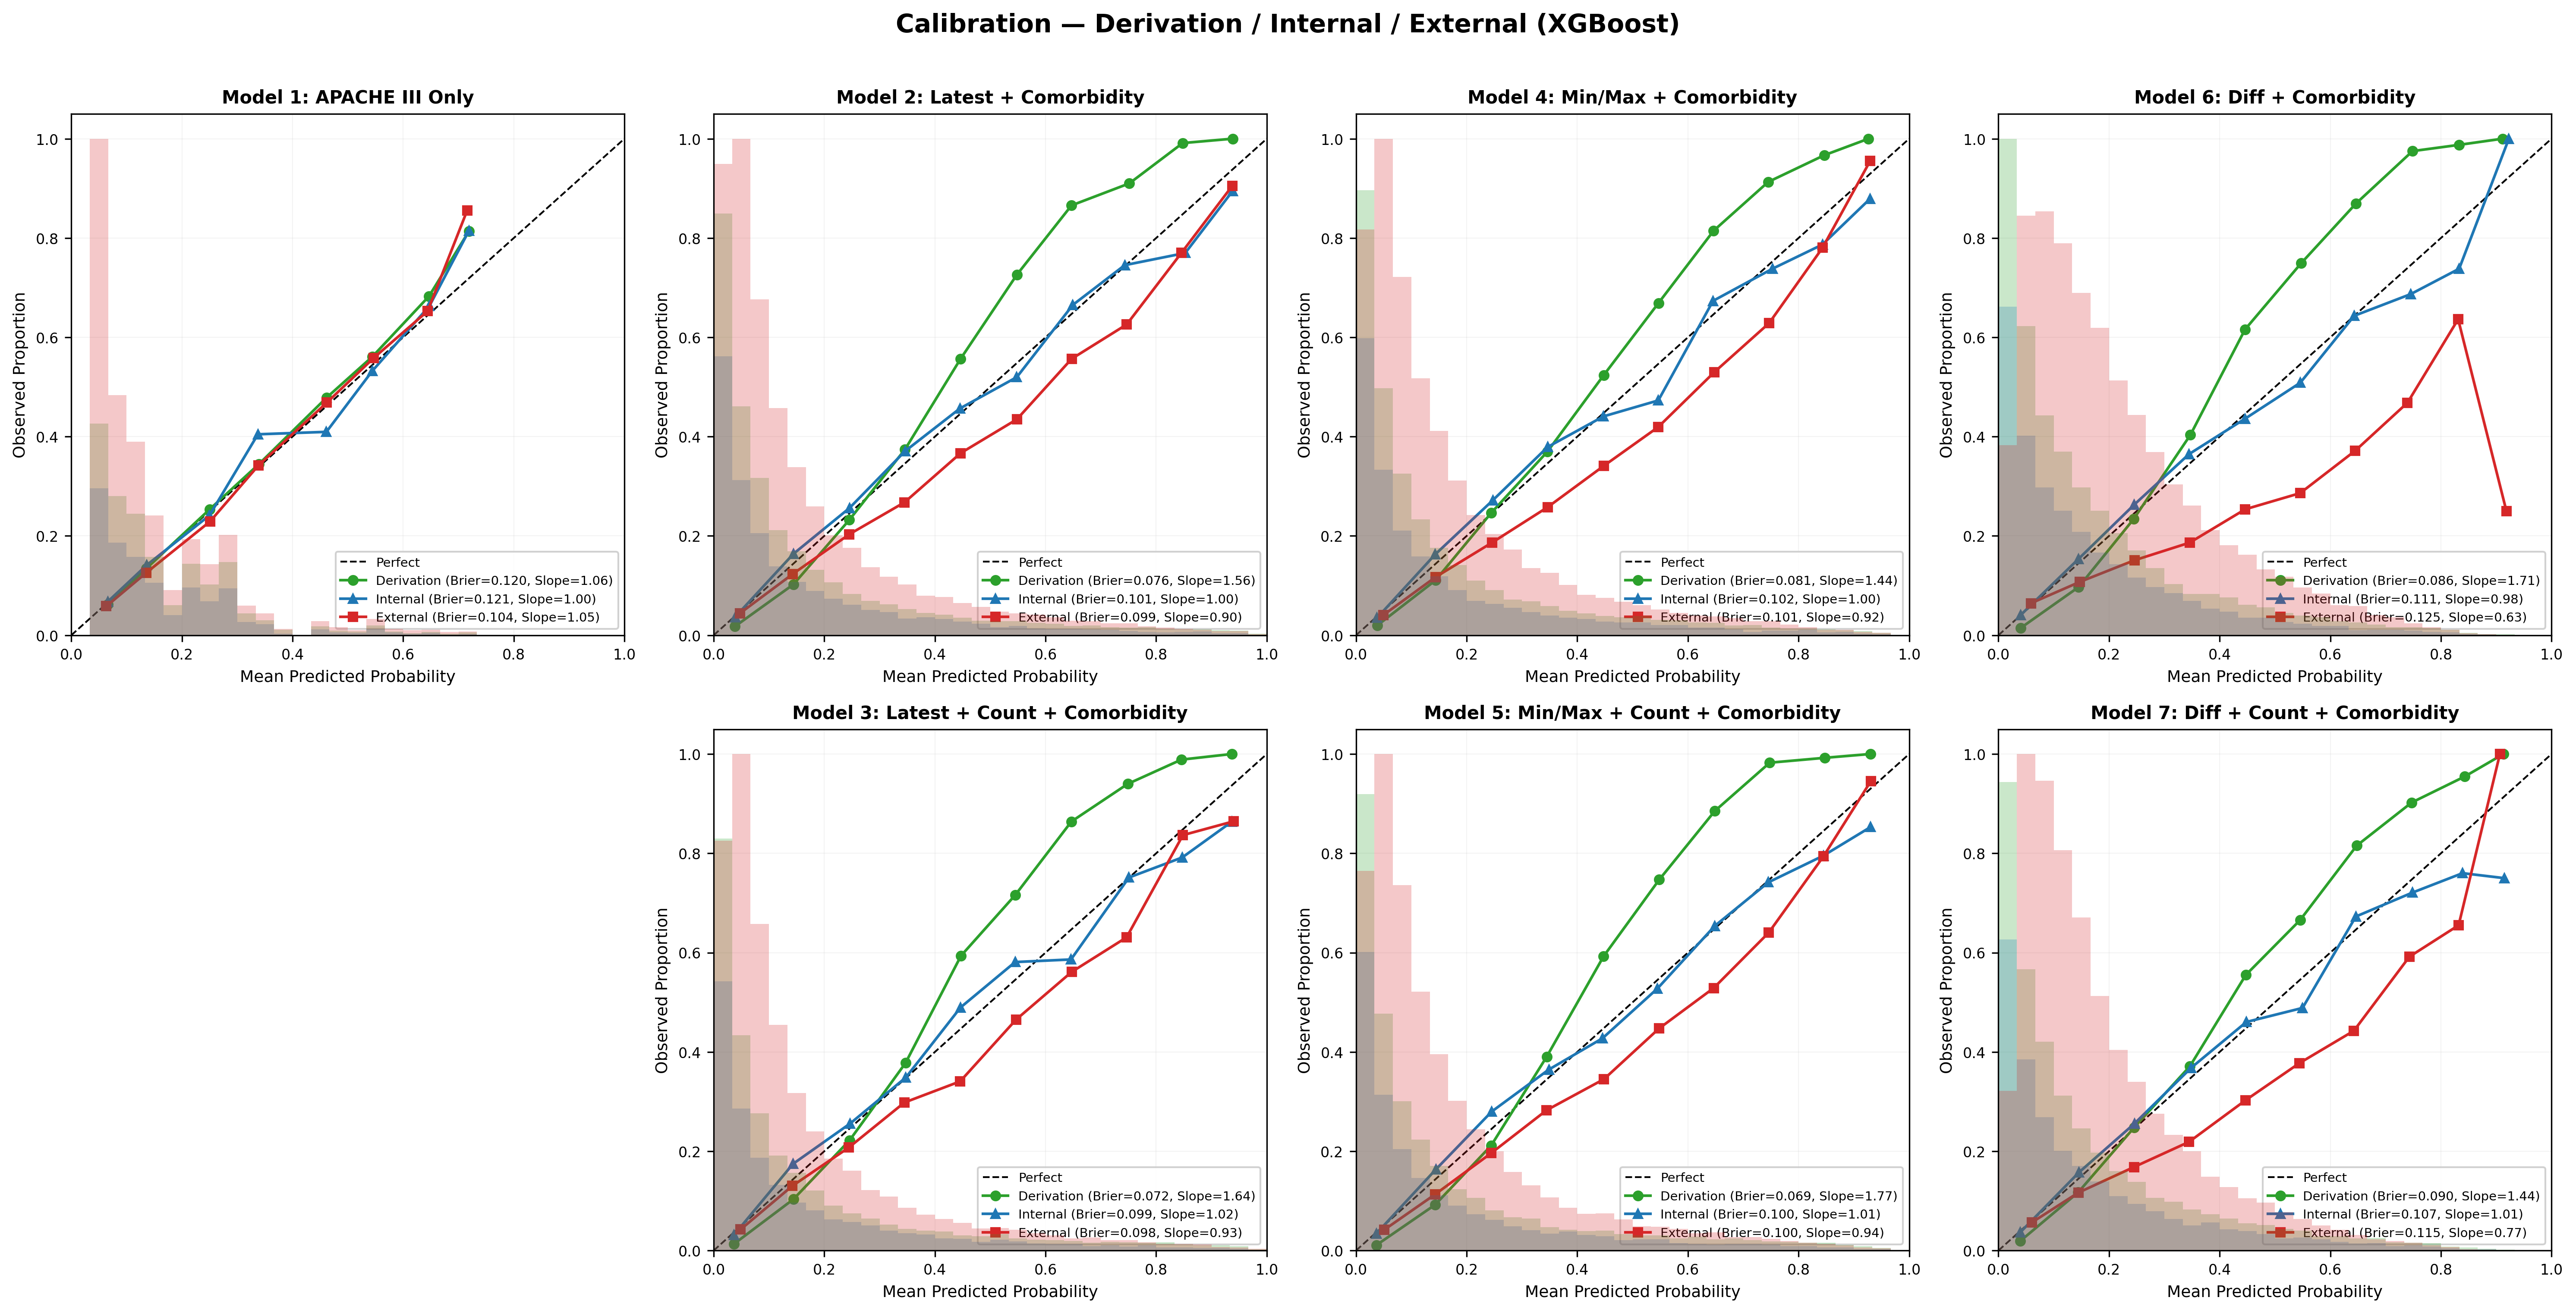

Creating S.Figure 2...
Saved: SFigure_2_ROC_test_vs_external_LR.png


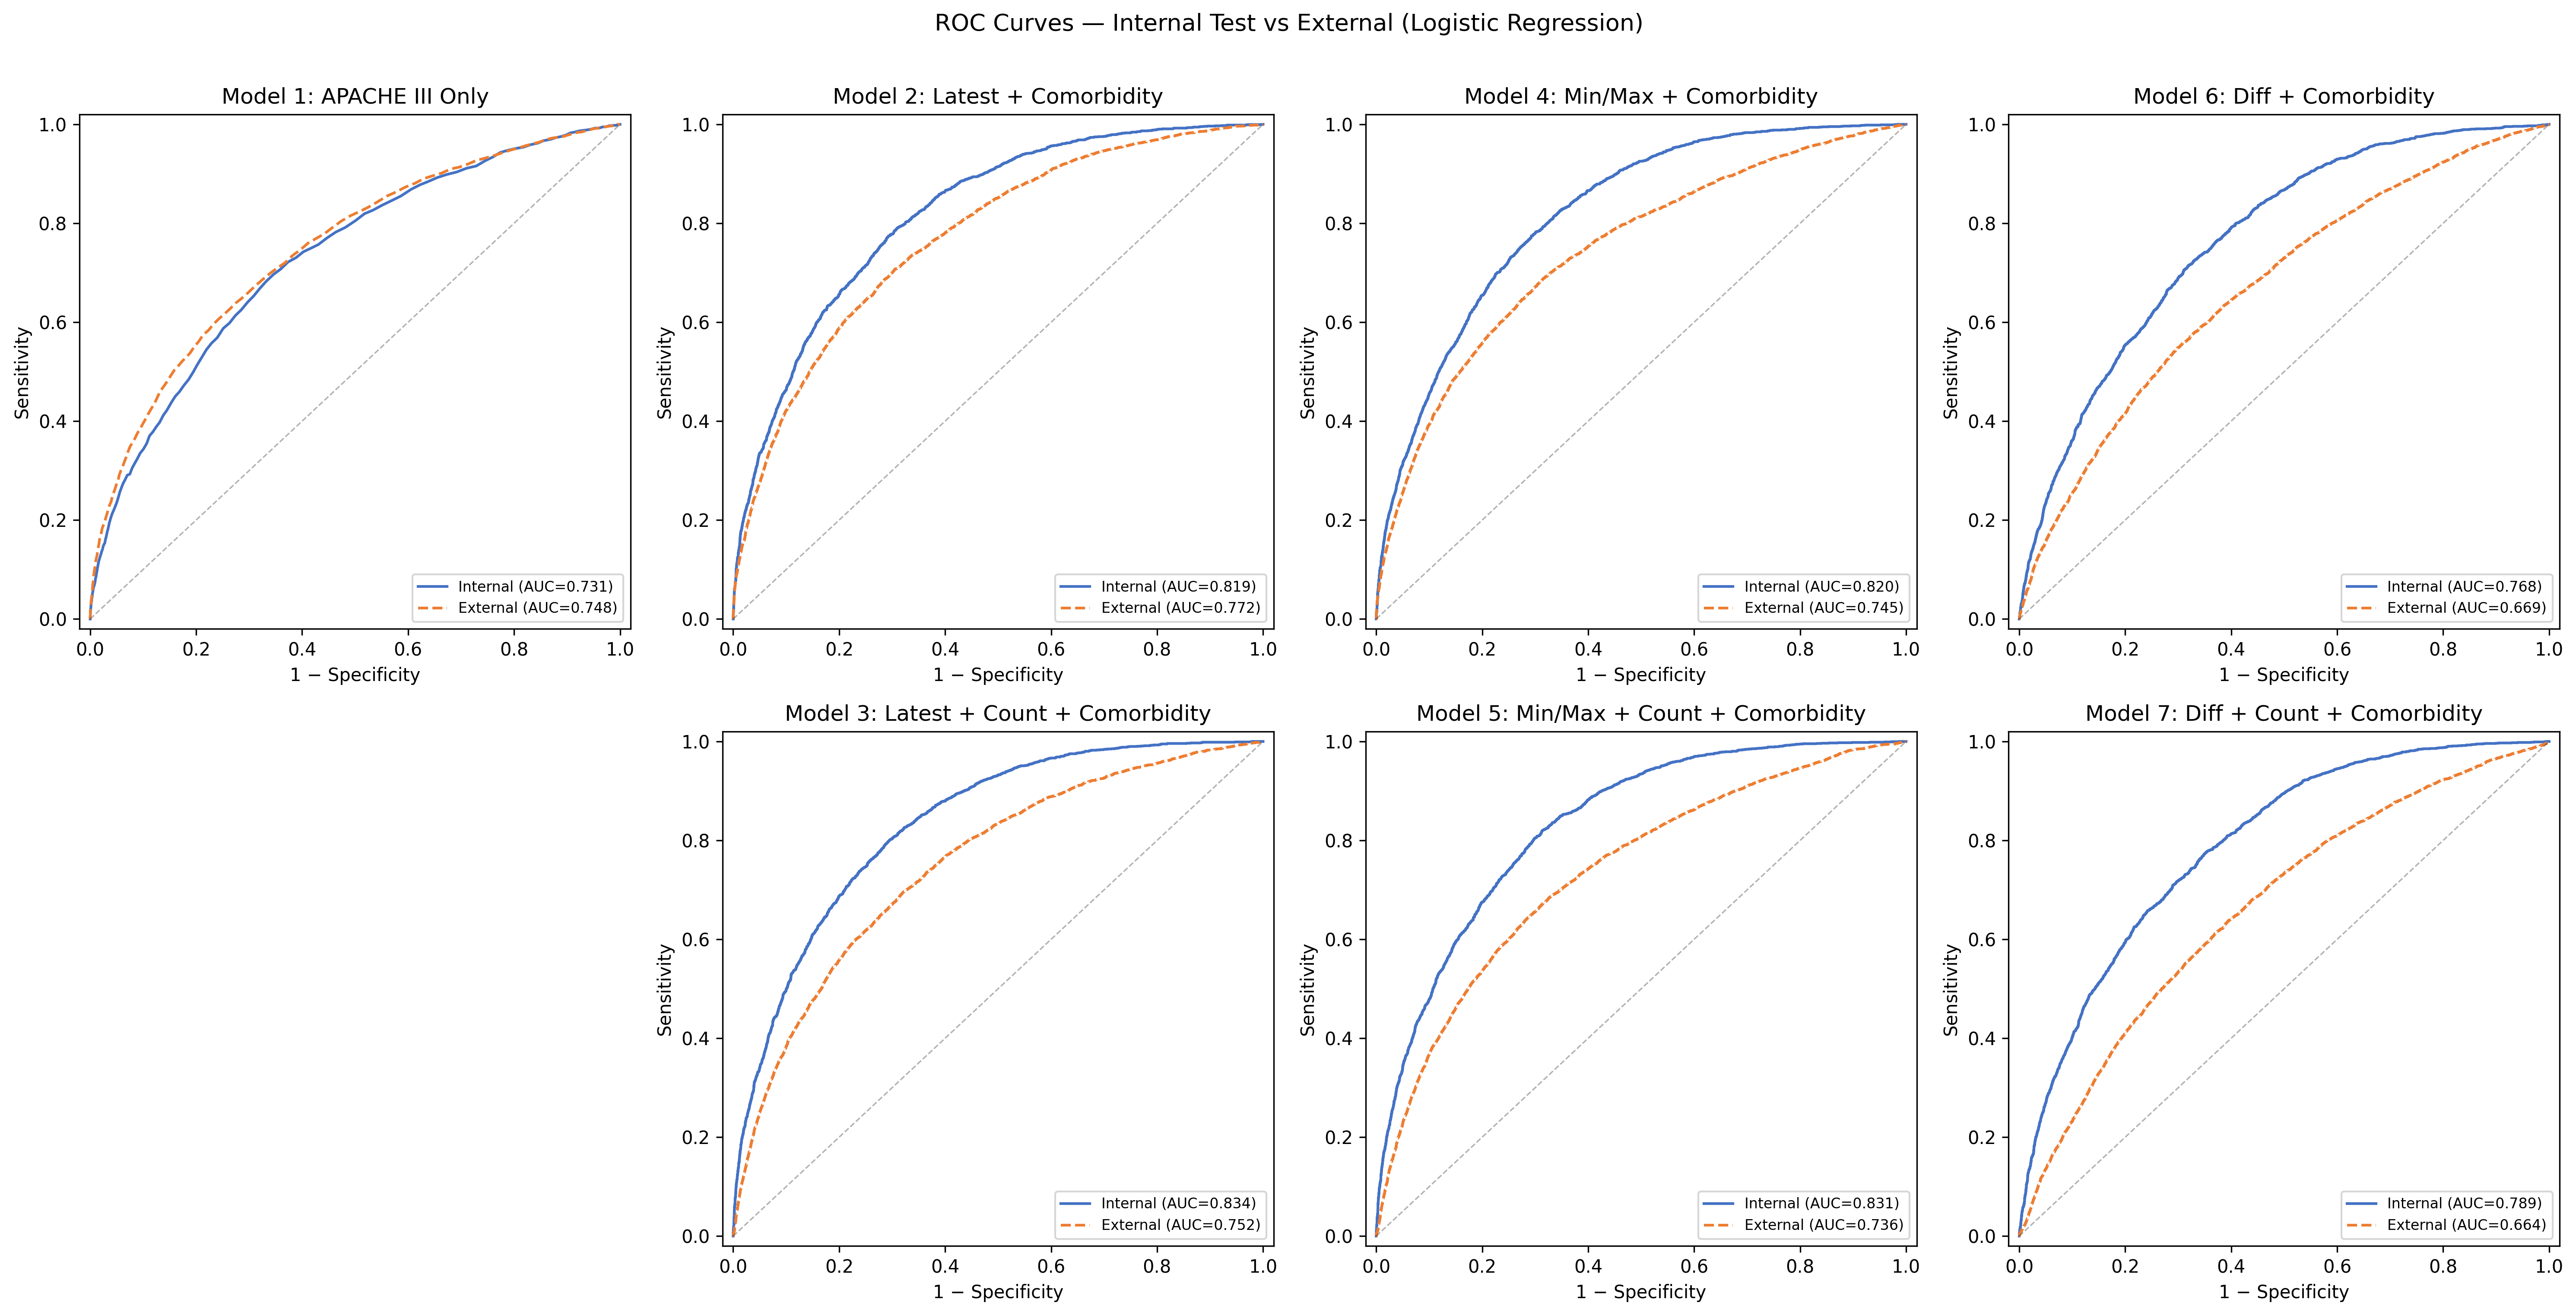

Creating S.Figure 3...
Saved: SFigure_3_PRC_external_LR.png


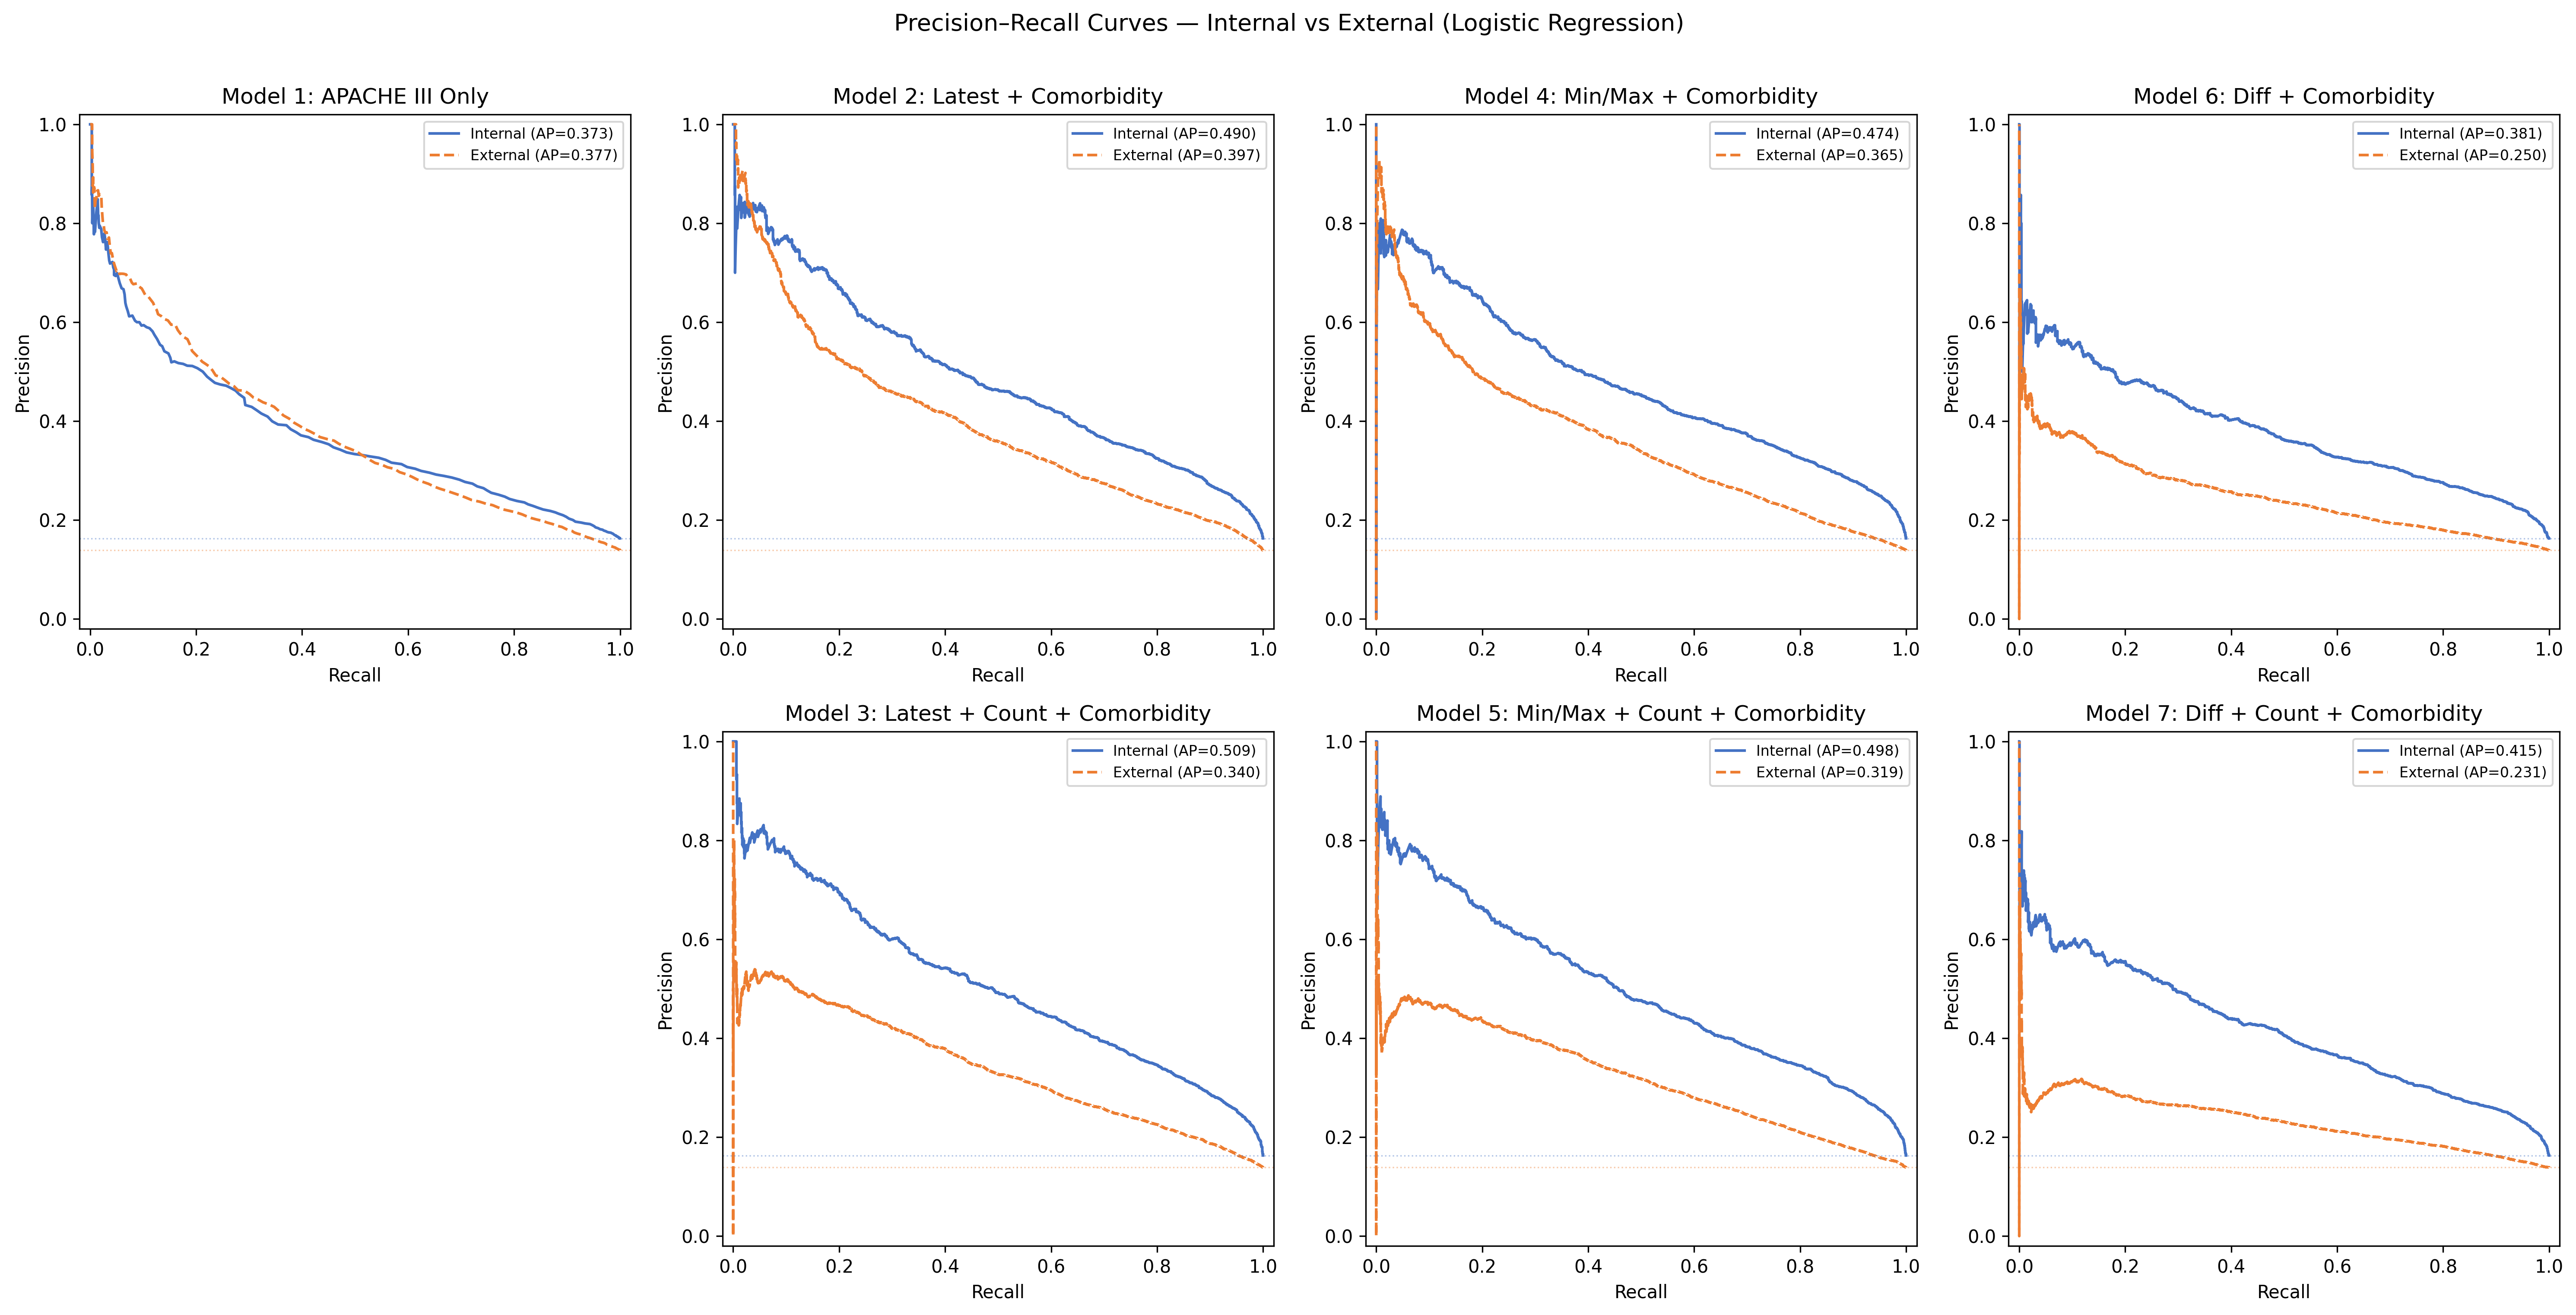

Creating S.Figure 4...
Saved: SFigure_4_ROC_test_vs_external_XGB.png


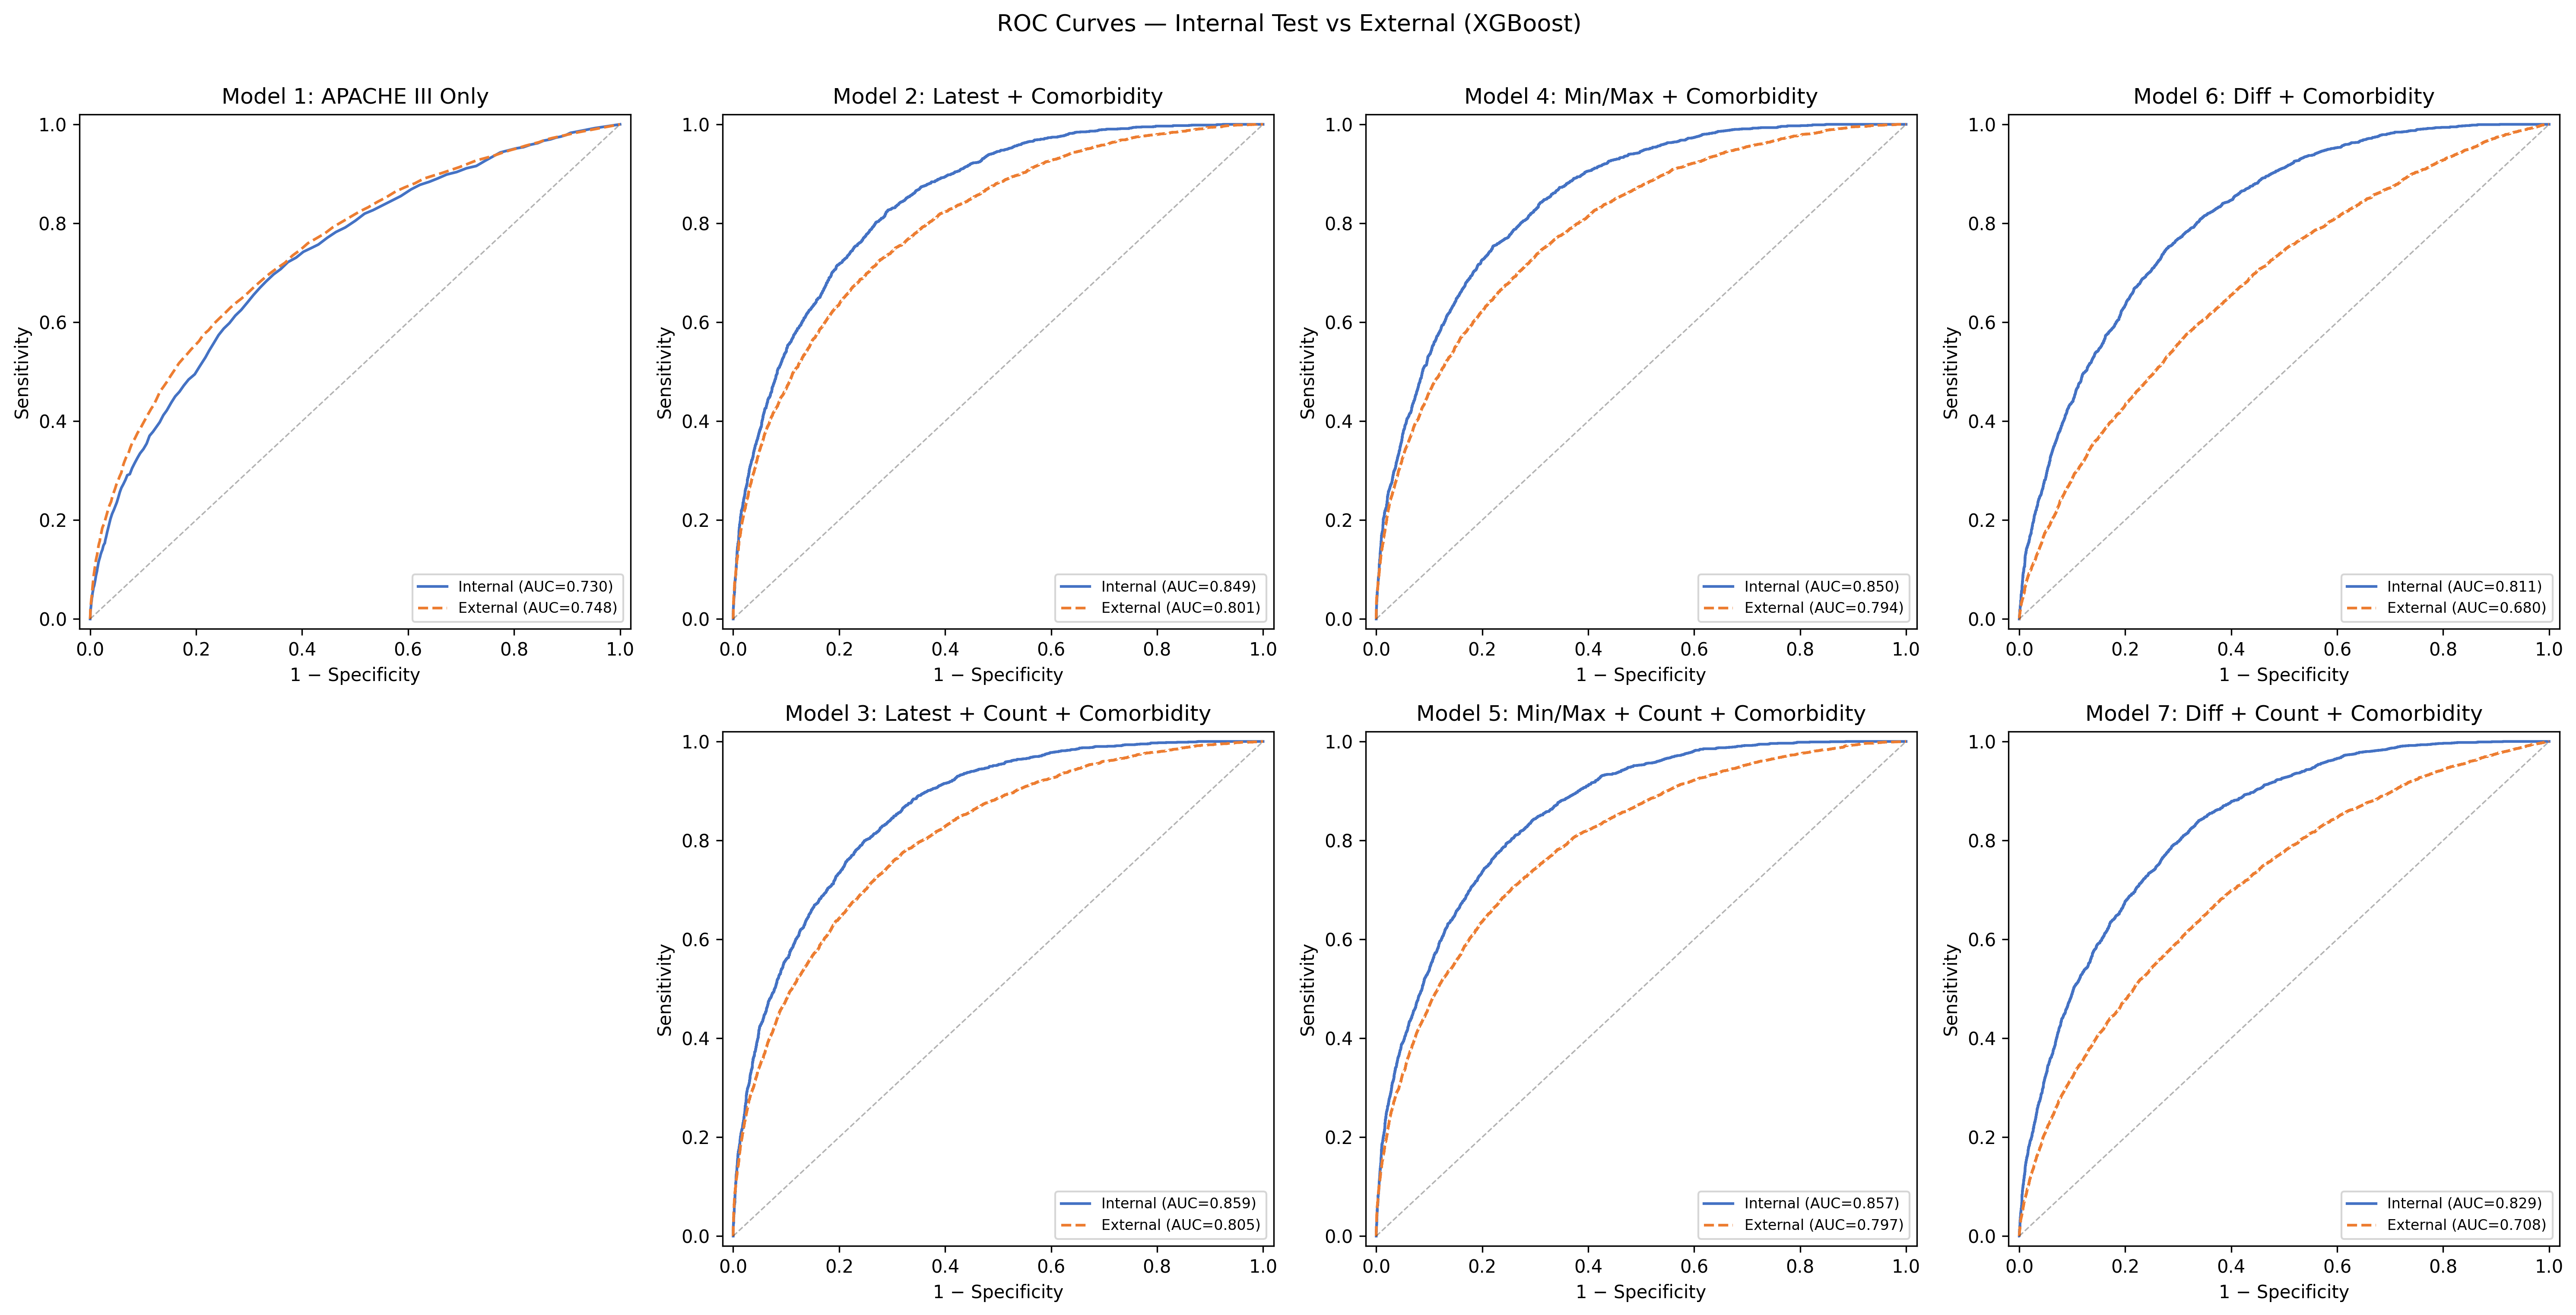

Creating S.Figure 5...
Saved: SFigure_5_PRC_external_XGB.png


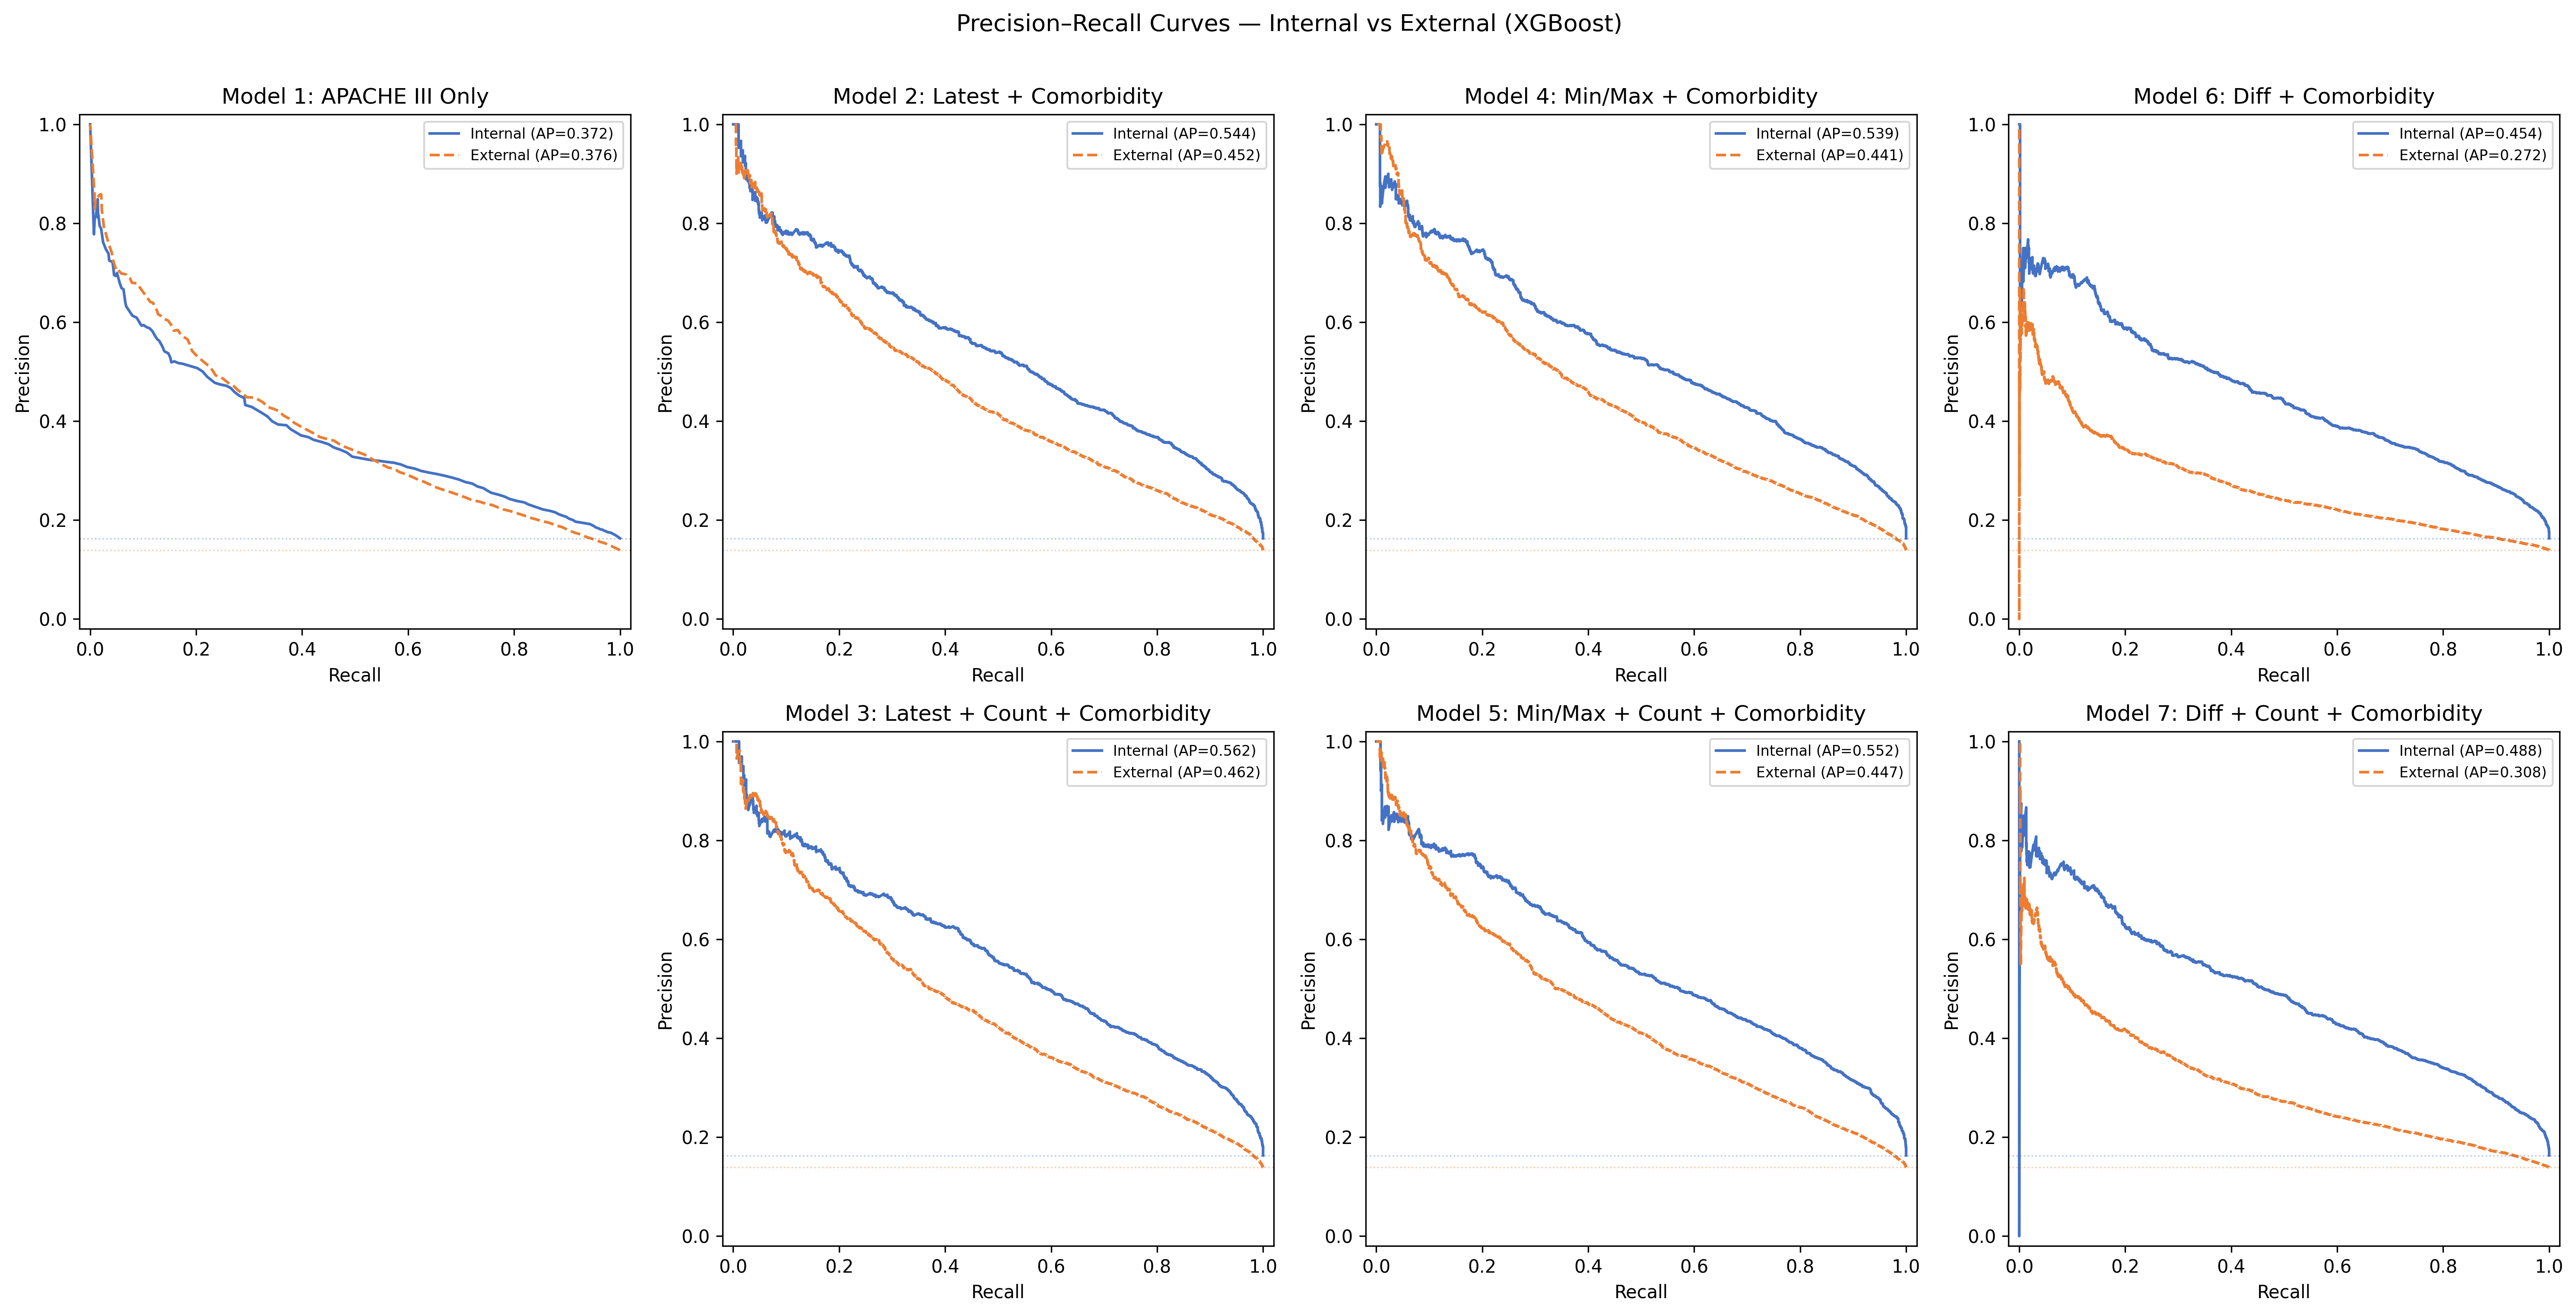


All publication figures saved to: ..\outputs\outputs_for_manuscript


In [48]:
# ============================================================
# Publication Figures (PNG only, 300 DPI)
# ============================================================
import matplotlib
matplotlib.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})

# 2x4 layout: (row, col, model_key)
# row1: M1, M2, M4, M6  |  row2: blank, M3, M5, M7
GRID_LAYOUT = [
    (0, 0, 'Model 1'), (0, 1, 'Model 2'), (0, 2, 'Model 4'), (0, 3, 'Model 6'),
    (1, 1, 'Model 3'), (1, 2, 'Model 5'), (1, 3, 'Model 7'),
]
MODEL_ORDER = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5', 'Model 6', 'Model 7']

def create_2x4_figure(figsize=(20, 10)):
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes[1, 0].set_visible(False)
    return fig, axes

# ============================================================
# Figure 2a: Delta AUROC vs Model
# ============================================================
print("Creating Figure 2a...")
fig, ax = plt.subplots(figsize=(8, 5))
dodge = 0.15
for ai, (algo_label, get_pipe, color, marker) in enumerate([
    ('Logistic Regression', lambda mk: pipelines[mk]['pipeline'], '#4472C4', 'o'),
    ('XGBoost', lambda mk: xgb_pipelines.get(mk), '#ED7D31', 's'),
]):
    offset = -dodge / 2 + ai * dodge
    x_positions, y_vals, y_err_lo, y_err_hi = [], [], [], []
    for idx, mk in enumerate(MODEL_ORDER):
        config = pipelines[mk]
        pipe = get_pipe(mk)
        if pipe is None:
            continue
        yp_test = pipe.predict_proba(config['X_test'])[:, 1]
        yp_ext = pipe.predict_proba(config['X_ext'])[:, 1]
        d, dlo, dhi = bootstrap_delta_ci(y_test, yp_test, y_ext, yp_ext, roc_auc_score)
        x_positions.append(idx + offset)
        y_vals.append(d)
        y_err_lo.append(d - dlo)
        y_err_hi.append(dhi - d)
    ax.errorbar(x_positions, y_vals, yerr=[y_err_lo, y_err_hi], fmt='', marker=marker, linestyle='none',
                color=color, label=algo_label, capsize=4, linewidth=1.5, markersize=6)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, rotation=45, ha="right")
ax.set_xlabel('Model')
ax.set_ylabel('ΔAUROC (External − Internal)')
ax.set_title('Performance Drop (ΔAUROC) vs Model')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'Figure_2a_delta_AUROC_vs_complexity.png')
print("Saved: Figure_2a_delta_AUROC_vs_complexity.png")
plt.show()

# ============================================================
# Figure 2b: Delta AUPRC vs Model
# ============================================================
print("Creating Figure 2b...")
fig, ax = plt.subplots(figsize=(8, 5))
dodge = 0.15
for ai, (algo_label, get_pipe, color, marker) in enumerate([
    ('Logistic Regression', lambda mk: pipelines[mk]['pipeline'], '#4472C4', 'o'),
    ('XGBoost', lambda mk: xgb_pipelines.get(mk), '#ED7D31', 's'),
]):
    offset = -dodge / 2 + ai * dodge
    x_positions, y_vals, y_err_lo, y_err_hi = [], [], [], []
    for idx, mk in enumerate(MODEL_ORDER):
        config = pipelines[mk]
        pipe = get_pipe(mk)
        if pipe is None:
            continue
        yp_test = pipe.predict_proba(config['X_test'])[:, 1]
        yp_ext = pipe.predict_proba(config['X_ext'])[:, 1]
        d, dlo, dhi = bootstrap_delta_ci(y_test, yp_test, y_ext, yp_ext, average_precision_score)
        x_positions.append(idx + offset)
        y_vals.append(d)
        y_err_lo.append(d - dlo)
        y_err_hi.append(dhi - d)
    ax.errorbar(x_positions, y_vals, yerr=[y_err_lo, y_err_hi], fmt='', marker=marker, linestyle='none',
                color=color, label=algo_label, capsize=4, linewidth=1.5, markersize=6)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, rotation=45, ha="right")
ax.set_xlabel('Model')
ax.set_ylabel('ΔAUPRC (External − Internal)')
ax.set_title('Performance Drop (ΔAUPRC) vs Model')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'Figure_2b_delta_AUPRC_vs_complexity.png')
print("Saved: Figure_2b_delta_AUPRC_vs_complexity.png")
plt.show()

# ============================================================
# Figure 3: Calibration — Derivation / Internal / External (Logistic Regression)
# ============================================================
print("Creating Figure 3...")
fig, axes = create_2x4_figure(figsize=(20, 10))
for r, c, mk in GRID_LAYOUT:
    ax = axes[r, c]
    config = pipelines[mk]
    pipe = config['pipeline']
    # Secondary axis for histogram
    ax2 = ax.twinx()
    ax2.set_ylabel('')
    ax2.set_yticks([])
    # Perfect calibration diagonal (dashed)
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1.0,
            label='Perfect', zorder=3)
    for label, X, y_true, color, marker in [
        ('Derivation', config['X_train'], y_train, '#2CA02C', 'o'),
        ('Internal',   config['X_test'],  y_test,  '#1F77B4', '^'),
        ('External',   config['X_ext'],   y_ext,   '#D62728', 's'),
    ]:
        y_pred = pipe.predict_proba(X)[:, 1]
        # Histogram of predicted probabilities (background)
        ax2.hist(y_pred, bins=30, range=(0, 1), alpha=0.25, color=color, zorder=0)
        # Calibration curve
        frac_pos, mean_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy='uniform')
        brier = brier_score_loss(y_true, y_pred)
        slope, _ = calculate_calibration_metrics(y_true, y_pred)
        ax.plot(mean_pred, frac_pos, marker=marker, linestyle='-', color=color,
                linewidth=1.5, markersize=5, markeredgecolor=color, markerfacecolor=color,
                label=f'{label} (Brier={brier:.3f}, Slope={slope:.2f})', zorder=4)
    ax.set_xlabel('Mean Predicted Probability', fontsize=9)
    ax.set_ylabel('Observed Proportion', fontsize=9)
    ax.set_title(f'{mk}: {config["name"]}', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7, frameon=True, framealpha=0.9, edgecolor='0.8')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
fig.suptitle('Calibration \u2014 Derivation / Internal / External (Logistic Regression)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'Figure_3_Calibration_external_LR.png')
print("Saved: Figure_3_Calibration_external_LR.png")
plt.show()

# ============================================================
# Figure 4: Calibration — Derivation / Internal / External (XGBoost)
# ============================================================
print("Creating Figure 4...")
fig, axes = create_2x4_figure(figsize=(20, 10))
for r, c, mk in GRID_LAYOUT:
    ax = axes[r, c]
    config = pipelines[mk]
    if mk not in xgb_pipelines:
        ax.set_visible(False)
        continue
    pipe = xgb_pipelines[mk]
    # Secondary axis for histogram
    ax2 = ax.twinx()
    ax2.set_ylabel('')
    ax2.set_yticks([])
    # Perfect calibration diagonal (dashed)
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1.0,
            label='Perfect', zorder=3)
    for label, X, y_true, color, marker in [
        ('Derivation', config['X_train'], y_train, '#2CA02C', 'o'),
        ('Internal',   config['X_test'],  y_test,  '#1F77B4', '^'),
        ('External',   config['X_ext'],   y_ext,   '#D62728', 's'),
    ]:
        y_pred = pipe.predict_proba(X)[:, 1]
        # Histogram of predicted probabilities (background)
        ax2.hist(y_pred, bins=30, range=(0, 1), alpha=0.25, color=color, zorder=0)
        # Calibration curve
        frac_pos, mean_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy='uniform')
        brier = brier_score_loss(y_true, y_pred)
        slope, _ = calculate_calibration_metrics(y_true, y_pred)
        ax.plot(mean_pred, frac_pos, marker=marker, linestyle='-', color=color,
                linewidth=1.5, markersize=5, markeredgecolor=color, markerfacecolor=color,
                label=f'{label} (Brier={brier:.3f}, Slope={slope:.2f})', zorder=4)
    ax.set_xlabel('Mean Predicted Probability', fontsize=9)
    ax.set_ylabel('Observed Proportion', fontsize=9)
    ax.set_title(f'{mk}: {config["name"]}', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7, frameon=True, framealpha=0.9, edgecolor='0.8')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
fig.suptitle('Calibration \u2014 Derivation / Internal / External (XGBoost)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'Figure_4_Calibration_external_XGB.png')
print("Saved: Figure_4_Calibration_external_XGB.png")
plt.show()



# ============================================================
# S.Figure 2: ROC — Internal Test vs External (Logistic Regression)
# ============================================================
print("Creating S.Figure 2...")
fig, axes = create_2x4_figure()
for r, c, mk in GRID_LAYOUT:
    ax = axes[r, c]
    config = pipelines[mk]
    pipe = config['pipeline']
    # Internal test
    yp_test = pipe.predict_proba(config['X_test'])[:, 1]
    fpr_t, tpr_t, _ = roc_curve(y_test, yp_test)
    auc_t = roc_auc_score(y_test, yp_test)
    # External
    yp_ext = pipe.predict_proba(config['X_ext'])[:, 1]
    fpr_e, tpr_e, _ = roc_curve(y_ext, yp_ext)
    auc_e = roc_auc_score(y_ext, yp_ext)
    ax.plot(fpr_t, tpr_t, '-', color='#4472C4', label=f'Internal (AUC={auc_t:.3f})', linewidth=1.5)
    ax.plot(fpr_e, tpr_e, '--', color='#ED7D31', label=f'External (AUC={auc_e:.3f})', linewidth=1.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
    ax.set_xlabel('1 \u2212 Specificity')
    ax.set_ylabel('Sensitivity')
    ax.set_title(f'{mk}: {config["name"]}')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
fig.suptitle('ROC Curves \u2014 Internal Test vs External (Logistic Regression)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'SFigure_2_ROC_test_vs_external_LR.png')
print("Saved: SFigure_2_ROC_test_vs_external_LR.png")
plt.show()

# ============================================================
# S.Figure 3: PRC — External Validation (Logistic Regression)
# ============================================================
print("Creating S.Figure 3...")
fig, axes = create_2x4_figure()
for r, c, mk in GRID_LAYOUT:
    ax = axes[r, c]
    config = pipelines[mk]
    pipe = config['pipeline']
    for label, X, y_true, ls, clr in [
        ('Internal', config['X_test'], y_test, '-', '#4472C4'),
        ('External', config['X_ext'], y_ext, '--', '#ED7D31'),
    ]:
        yp = pipe.predict_proba(X)[:, 1]
        prec, rec, _ = precision_recall_curve(y_true, yp)
        ap = average_precision_score(y_true, yp)
        ax.plot(rec, prec, ls, color=clr, label=f'{label} (AP={ap:.3f})', linewidth=1.5)
    prev_int = y_test.mean()
    prev_ext = y_ext.mean()
    ax.axhline(y=prev_int, color='#4472C4', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.axhline(y=prev_ext, color='#ED7D31', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{mk}: {config["name"]}')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
fig.suptitle('Precision\u2013Recall Curves \u2014 Internal vs External (Logistic Regression)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'SFigure_3_PRC_external_LR.png')
print("Saved: SFigure_3_PRC_external_LR.png")
plt.show()

# ============================================================
# S.Figure 4: ROC — Internal Test vs External (XGBoost)
# ============================================================
print("Creating S.Figure 4...")
fig, axes = create_2x4_figure()
for r, c, mk in GRID_LAYOUT:
    ax = axes[r, c]
    config = pipelines[mk]
    if mk not in xgb_pipelines:
        ax.set_visible(False)
        continue
    pipe = xgb_pipelines[mk]
    yp_test = pipe.predict_proba(config['X_test'])[:, 1]
    fpr_t, tpr_t, _ = roc_curve(y_test, yp_test)
    auc_t = roc_auc_score(y_test, yp_test)
    yp_ext = pipe.predict_proba(config['X_ext'])[:, 1]
    fpr_e, tpr_e, _ = roc_curve(y_ext, yp_ext)
    auc_e = roc_auc_score(y_ext, yp_ext)
    ax.plot(fpr_t, tpr_t, '-', color='#4472C4', label=f'Internal (AUC={auc_t:.3f})', linewidth=1.5)
    ax.plot(fpr_e, tpr_e, '--', color='#ED7D31', label=f'External (AUC={auc_e:.3f})', linewidth=1.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
    ax.set_xlabel('1 \u2212 Specificity')
    ax.set_ylabel('Sensitivity')
    ax.set_title(f'{mk}: {config["name"]}')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
fig.suptitle('ROC Curves \u2014 Internal Test vs External (XGBoost)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'SFigure_4_ROC_test_vs_external_XGB.png')
print("Saved: SFigure_4_ROC_test_vs_external_XGB.png")
plt.show()

# ============================================================
# S.Figure 5: PRC — External Validation (XGBoost)
# ============================================================
print("Creating S.Figure 5...")
fig, axes = create_2x4_figure()
for r, c, mk in GRID_LAYOUT:
    ax = axes[r, c]
    config = pipelines[mk]
    if mk not in xgb_pipelines:
        ax.set_visible(False)
        continue
    pipe = xgb_pipelines[mk]
    for label, X, y_true, ls, clr in [
        ('Internal', config['X_test'], y_test, '-', '#4472C4'),
        ('External', config['X_ext'], y_ext, '--', '#ED7D31'),
    ]:
        yp = pipe.predict_proba(X)[:, 1]
        prec, rec, _ = precision_recall_curve(y_true, yp)
        ap = average_precision_score(y_true, yp)
        ax.plot(rec, prec, ls, color=clr, label=f'{label} (AP={ap:.3f})', linewidth=1.5)
    prev_int = y_test.mean()
    prev_ext = y_ext.mean()
    ax.axhline(y=prev_int, color='#4472C4', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.axhline(y=prev_ext, color='#ED7D31', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{mk}: {config["name"]}')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
fig.suptitle('Precision\u2013Recall Curves \u2014 Internal vs External (XGBoost)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'SFigure_5_PRC_external_XGB.png')
print("Saved: SFigure_5_PRC_external_XGB.png")
plt.show()

print("\n" + "=" * 60)
print("All publication figures saved to:", OUT_DIR)
print("=" * 60)


In [47]:
# ============================================================
# Supplementary Tables: S.Table 1 (Model Summary) & S.Table 2 (Recalibration)
# ============================================================

MODEL_ORDER = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5', 'Model 6', 'Model 7']

# --- S.Table 1: Model Summary ---
print("=" * 60)
print("Creating S.Table 1: Model Summary")
print("=" * 60)

model_features_map = {
    'Model 1': (MODEL1_NUMERICAL_FEATURES, MODEL1_CATEGORICAL_FEATURES),
    'Model 2': (MODEL2_NUMERICAL_FEATURES, MODEL2_CATEGORICAL_FEATURES),
    'Model 3': (MODEL3_NUMERICAL_FEATURES, MODEL3_CATEGORICAL_FEATURES),
    'Model 4': (MODEL4_NUMERICAL_FEATURES, MODEL4_CATEGORICAL_FEATURES),
    'Model 5': (MODEL5_NUMERICAL_FEATURES, MODEL5_CATEGORICAL_FEATURES),
    'Model 6': (MODEL6_NUM_FEATURES, MODEL6_CAT_FEATURES),
    'Model 7': (MODEL7_NUM_FEATURES, MODEL7_CAT_FEATURES),
}

s1_rows = []
for mk in MODEL_ORDER:
    config = pipelines[mk]
    num_feats, cat_feats = model_features_map[mk]
    all_feats = list(num_feats) + list(cat_feats)
    s1_rows.append({
        'Model ID': mk,
        'Feature set': config['name'],
        '# Numerical': len(num_feats),
        '# Categorical': len(cat_feats),
        '# Total': len(all_feats),
        'Variables': ', '.join(all_feats),
    })

df_stable1 = pd.DataFrame(s1_rows)
display(df_stable1)

# Save .md
stable1_footnotes = "Each model uses logistic regression or XGBoost with the specified feature set. Categorical variables are one-hot encoded."
md_text = "### S.Table 1. Model summary: variables used by each model specification\n\n"
md_text += df_stable1.to_markdown(index=False)
md_text += "\n\n" + stable1_footnotes
with open(OUT_DIR / 'STable_1_model_summary.md', 'w', encoding='utf-8') as f:
    f.write(md_text)
print("Saved: STable_1_model_summary.md")

# Save .docx
save_table_as_docx(df_stable1,
    'S.Table 1. Model summary: variables used by each model specification',
    stable1_footnotes, OUT_DIR / 'STable_1_model_summary.docx')
print("Saved: STable_1_model_summary.docx")

# --- S.Table 2: Recalibration Results (External) ---
print("\n" + "=" * 60)
print("Creating S.Table 2: Recalibration Results")
print("=" * 60)

s2_rows = []
for algo_name, get_pipe in [
    ('Logistic regression', lambda mk: pipelines[mk]['pipeline']),
    ('XGBoost', lambda mk: xgb_pipelines[mk]),
]:
    for mk in MODEL_ORDER:
        config = pipelines[mk]
        try:
            pipe = get_pipe(mk)
        except KeyError:
            continue
        print(f"  {algo_name} - {mk}...")

        y_pred_ext = pipe.predict_proba(config['X_ext'])[:, 1]
        y_pred_ext_clipped = np.clip(y_pred_ext, 1e-10, 1 - 1e-10)
        logit_pred = np.log(y_pred_ext_clipped / (1 - y_pred_ext_clipped))

        # Pre-recalibration metrics
        slope_pre, citl_pre = calculate_calibration_metrics(y_ext, y_pred_ext)
        brier_pre = brier_score_loss(y_ext, y_pred_ext)
        logloss_pre = log_loss(y_ext, y_pred_ext)

        # Fit recalibration model: logit(Y) = alpha + beta * logit(p_hat)
        lr_recal = LogisticRegression(solver='lbfgs', max_iter=1000)
        lr_recal.fit(logit_pred.reshape(-1, 1), y_ext)
        alpha_recal = lr_recal.intercept_[0]
        beta_recal = lr_recal.coef_[0][0]

        # Recalibrated predictions
        y_pred_recal = expit(alpha_recal + beta_recal * logit_pred)

        # Post-recalibration metrics
        brier_post = brier_score_loss(y_ext, y_pred_recal)
        logloss_post = log_loss(y_ext, y_pred_recal)

        s2_rows.append({
            'Algorithm': algo_name,
            'Model ID': mk,
            'Feature set': config['name'],
            'CITL (pre-recal)': f"{citl_pre:.3f}",
            'Slope (pre-recal)': f"{slope_pre:.3f}",
            'Recalibrated \u03b1': f"{alpha_recal:.3f}",
            'Recalibrated \u03b2': f"{beta_recal:.3f}",
            'Brier (pre)': f"{brier_pre:.4f}",
            'Brier (post)': f"{brier_post:.4f}",
            '\u0394Brier': f"{brier_post - brier_pre:.4f}",
            'Log loss (pre)': f"{logloss_pre:.4f}",
            'Log loss (post)': f"{logloss_post:.4f}",
            '\u0394Log loss': f"{logloss_post - logloss_pre:.4f}",
        })

df_stable2 = pd.DataFrame(s2_rows)
display(df_stable2)

# Footnotes
stable2_footnotes = (
    "Abbreviations: CITL, calibration-in-the-large; LR, logistic regression; XGB, XGBoost.\n"
    "Recalibration model: logit(Y) = \u03b1 + \u03b2 \u00b7 logit(p\u0302). "
    "Ideal pre-recalibration: \u03b1 = 0, \u03b2 = 1. "
    "Negative \u0394Brier / \u0394Log loss indicates improvement after recalibration."
)

# Save .md
md_text = "### S.Table 2. Recalibration-only results (external validation)\n\n"
md_text += df_stable2.to_markdown(index=False)
md_text += "\n\n" + stable2_footnotes
with open(OUT_DIR / 'STable_2_recalibration.md', 'w', encoding='utf-8') as f:
    f.write(md_text)
print("\nSaved: STable_2_recalibration.md")

# Save .docx
save_table_as_docx(df_stable2,
    'S.Table 2. Recalibration-only results (external validation)',
    stable2_footnotes, OUT_DIR / 'STable_2_recalibration.docx')
print("Saved: STable_2_recalibration.docx")

# --- Final summary ---
print("\n" + "=" * 60)
print("Publication Output Summary")
print("=" * 60)
for f in sorted(OUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:55s} {size_kb:8.1f} KB')


Creating S.Table 1: Model Summary


,Model ID,Feature set,# Numerical,# Categorical,# Total,Variables
0,Model 1,APACHE III Only,1,0,1,apache3_score
1,Model 2,Latest + Comorbidity,20,1,21,"age, hr_latest, map_latest, temp_latest, rr_la..."
2,Model 3,Latest + Count + Comorbidity,38,1,39,"age, hr_latest, map_latest, temp_latest, rr_la..."
3,Model 4,Min/Max + Comorbidity,38,1,39,"age, hr_min, hr_max, map_min, map_max, temp_mi..."
4,Model 5,Min/Max + Count + Comorbidity,56,1,57,"age, hr_min, hr_max, map_min, map_max, temp_mi..."
5,Model 6,Diff + Comorbidity,20,1,21,"age, uop, hr_diff, map_diff, temp_diff, rr_dif..."
6,Model 7,Diff + Count + Comorbidity,38,1,39,"age, uop, hr_diff, map_diff, temp_diff, rr_dif..."


Saved: STable_1_model_summary.md
Saved: STable_1_model_summary.docx

Creating S.Table 2: Recalibration Results
  Logistic regression - Model 1...
  Logistic regression - Model 2...
  Logistic regression - Model 3...
  Logistic regression - Model 4...
  Logistic regression - Model 5...
  Logistic regression - Model 6...
  Logistic regression - Model 7...
  XGBoost - Model 1...
  XGBoost - Model 2...
  XGBoost - Model 3...
  XGBoost - Model 4...
  XGBoost - Model 5...
  XGBoost - Model 6...
  XGBoost - Model 7...


,Algorithm,Model ID,Feature set,CITL (pre-recal),Slope (pre-recal),Recalibrated α,Recalibrated β,Brier (pre),Brier (post),ΔBrier,Log loss (pre),Log loss (post),ΔLog loss
0,Logistic regression,Model 1,APACHE III Only,-0.065,1.007,-0.065,1.007,0.1042,0.1042,-0.0001,0.3502,0.3499,-0.0003
1,Logistic regression,Model 2,Latest + Comorbidity,-0.519,0.874,-0.519,0.874,0.1057,0.1024,-0.0033,0.3495,0.3410,-0.0084
2,Logistic regression,Model 3,Latest + Count + Comorbidity,-0.804,0.582,-0.804,0.582,0.1125,0.1069,-0.0056,0.3769,0.3562,-0.0208
3,Logistic regression,Model 4,Min/Max + Comorbidity,-0.479,0.649,-0.479,0.649,0.1067,0.1053,-0.0014,0.3641,0.3536,-0.0105
4,Logistic regression,Model 5,Min/Max + Count + Comorbidity,-0.649,0.505,-0.649,0.505,0.1128,0.1089,-0.0039,0.3913,0.3627,-0.0286
5,Logistic regression,Model 6,Diff + Comorbidity,-0.895,0.593,-0.895,0.593,0.1207,0.1140,-0.0066,0.3987,0.3817,-0.0170
6,Logistic regression,Model 7,Diff + Count + Comorbidity,-1.013,0.417,-1.013,0.417,0.1216,0.1161,-0.0055,0.4109,0.3879,-0.0230
7,XGBoost,Model 1,APACHE III Only,-0.003,1.046,-0.003,1.046,0.1044,0.1043,-0.0001,0.3508,0.3504,-0.0004
8,XGBoost,Model 2,Latest + Comorbidity,-0.373,0.898,-0.373,0.898,0.0988,0.0972,-0.0016,0.3278,0.3240,-0.0038
9,XGBoost,Model 3,Latest + Count + Comorbidity,-0.307,0.927,-0.307,0.927,0.0975,0.0964,-0.0011,0.3244,0.3218,-0.0026



Saved: STable_2_recalibration.md
Saved: STable_2_recalibration.docx

Publication Output Summary
  AI vulnerability_Oct082025.pptx                            308.5 KB
  Calibration Uniform                                          4.0 KB
  distribution_comparison_mimic_eicu.pdf                      75.1 KB
  distribution_comparison_mimic_eicu.png                     870.7 KB
  Figure_1.flowdiagram.pptx                                   44.5 KB
  Figure_1_Flow_diagram.png                                   68.7 KB
  Figure_2a_delta_AUROC_vs_complexity.png                    111.8 KB
  Figure_2b_delta_AUPRC_vs_complexity.png                     98.9 KB
  Figure_3_Calibration_external_LR.png                       860.1 KB
  Figure_3_Calibration_external_LR_uniform.png               655.1 KB
  Figure_4_Calibration_external_XGB.png                      919.5 KB
  Figure_4_Calibration_external_XGB_uniform.png              739.0 KB
  Figure_count_distribution_mimic_eicu.png                   40

## Subgroup Analysis (Model 1, Model 2 & Model 3, Logistic Regression)

Evaluate AUROC across demographic and facility subgroups:
- **race_ethnicity** (White / Black / Other): Internal (MIMIC test) + External (eICU)
- **teachingstatus** (True / False): External (eICU) only
- **region** (Midwest / South / West / Northeast): External (eICU) only

In [40]:
# ============================================================
# Step 19: Subgroup Analysis — Race/Ethnicity Recoding & Distribution Check
# ============================================================

# Recode race_ethnicity to 3 categories: White, Black, Other
race_recode = {
    'White': 'White',
    'Black': 'Black',
    'Asian': 'Other',
    'Hispanic': 'Other',
    'Other/Unknown': 'Other'
}

subgroup_test_race_3 = subgroup_test_race.map(race_recode)
subgroup_ext_race_3 = subgroup_ext_race.map(race_recode)

print("=" * 70)
print("SUBGROUP DISTRIBUTION CHECK")
print("=" * 70)

# --- race_ethnicity (Internal Test) ---
print("\n--- race_ethnicity: Internal Test (MIMIC) ---")
for grp in sorted(subgroup_test_race_3.dropna().unique()):
    mask = subgroup_test_race_3 == grp
    n = mask.sum()
    events = y_test[mask].sum()
    rate = y_test[mask].mean() * 100
    print(f"  {grp:15s}: N={n:>6,}, Deaths={int(events):>4,}, Mortality={rate:.1f}%")
print(f"  {'Total':15s}: N={len(y_test):>6,}, Deaths={int(y_test.sum()):>4,}, Mortality={y_test.mean()*100:.1f}%")

# --- race_ethnicity (External) ---
print("\n--- race_ethnicity: External (eICU) ---")
for grp in sorted(subgroup_ext_race_3.dropna().unique()):
    mask = subgroup_ext_race_3 == grp
    n = mask.sum()
    events = y_ext[mask].sum()
    rate = y_ext[mask].mean() * 100
    print(f"  {grp:15s}: N={n:>6,}, Deaths={int(events):>4,}, Mortality={rate:.1f}%")
n_race_na = subgroup_ext_race_3.isna().sum()
print(f"  {'NaN (excluded)':15s}: N={n_race_na:>6,}")
print(f"  {'Total':15s}: N={len(y_ext):>6,}, Deaths={int(y_ext.sum()):>4,}, Mortality={y_ext.mean()*100:.1f}%")

# --- teachingstatus (External only) ---
print("\n--- teachingstatus: External (eICU) ---")
for grp in sorted(subgroup_ext_teaching.dropna().unique()):
    mask = subgroup_ext_teaching == grp
    n = mask.sum()
    events = y_ext[mask].sum()
    rate = y_ext[mask].mean() * 100
    print(f"  {str(grp):15s}: N={n:>6,}, Deaths={int(events):>4,}, Mortality={rate:.1f}%")

# --- region (External only) ---
print("\n--- region: External (eICU) ---")
for grp in sorted(subgroup_ext_region.dropna().unique()):
    mask = subgroup_ext_region == grp
    n = mask.sum()
    events = y_ext[mask].sum()
    rate = y_ext[mask].mean() * 100
    print(f"  {grp:15s}: N={n:>6,}, Deaths={int(events):>4,}, Mortality={rate:.1f}%")

SUBGROUP DISTRIBUTION CHECK

--- race_ethnicity: Internal Test (MIMIC) ---
  Black          : N= 1,040, Deaths= 153, Mortality=14.7%
  Other          : N= 2,949, Deaths= 637, Mortality=21.6%
  White          : N= 8,099, Deaths=1,181, Mortality=14.6%
  Total          : N=12,088, Deaths=1,971, Mortality=16.3%

--- race_ethnicity: External (eICU) ---
  Black          : N= 2,988, Deaths= 438, Mortality=14.7%
  Other          : N= 2,786, Deaths= 391, Mortality=14.0%
  White          : N=25,483, Deaths=3,520, Mortality=13.8%
  NaN (excluded) : N=   146
  Total          : N=31,403, Deaths=4,369, Mortality=13.9%

--- teachingstatus: External (eICU) ---
  0.0            : N=19,995, Deaths=2,640, Mortality=13.2%
  1.0            : N=11,408, Deaths=1,729, Mortality=15.2%

--- region: External (eICU) ---
  Midwest        : N=13,817, Deaths=1,724, Mortality=12.5%
  Northeast      : N= 4,120, Deaths= 650, Mortality=15.8%
  South          : N= 6,832, Deaths=1,070, Mortality=15.7%
  West           : N

In [41]:
# ============================================================
# Step 20: Subgroup Analysis — AUROC Calculation
# ============================================================

def subgroup_auroc(y_true, y_pred, groups, model_name, dataset_name, var_name, n_bootstrap=N_BOOT):
    """Calculate AUROC with bootstrap 95% CI for each subgroup."""
    results = []
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    for grp in sorted(groups.dropna().unique()):
        mask = np.asarray(groups == grp)
        yt = y_true_arr[mask]
        yp = y_pred_arr[mask]

        if len(yt) < 20 or len(np.unique(yt)) < 2:
            print(f"  Skipping {grp}: N={len(yt)}, unique outcomes={len(np.unique(yt))}")
            continue

        auroc, lo, hi = bootstrap_ci(yt, yp, roc_auc_score, n_bootstrap)
        results.append({
            'Model': model_name,
            'Dataset': dataset_name,
            'Subgroup Variable': var_name,
            'Subgroup': str(grp),
            'N': int(mask.sum()),
            'Events': int(yt.sum()),
            'Event Rate (%)': round(yt.mean() * 100, 1),
            'AUROC': round(auroc, 4),
            'AUROC 95% CI': f"({lo:.4f}-{hi:.4f})"
        })
    return results


# --- Run subgroup analysis for Model 2 and Model 3 ---
all_subgroup_results = []

for model_key in ['Model 1', 'Model 2', 'Model 3']:
    pipeline = pipelines[model_key]['pipeline']
    y_test_pred = predictions[model_key]['y_test_pred']
    y_ext_pred = predictions[model_key]['y_ext_pred']
    model_desc = f"{model_key} ({pipelines[model_key]['name']})"

    print(f"\n{'='*70}")
    print(f"Subgroup AUROC: {model_desc}")
    print(f"{'='*70}")

    # 1. race_ethnicity — Internal (MIMIC test)
    print(f"\n  race_ethnicity — Internal Test (MIMIC)...")
    res = subgroup_auroc(y_test, y_test_pred, subgroup_test_race_3,
                         model_key, 'Internal (MIMIC)', 'race_ethnicity')
    all_subgroup_results.extend(res)

    # 2. race_ethnicity — External (eICU)
    print(f"  race_ethnicity — External (eICU)...")
    res = subgroup_auroc(y_ext, y_ext_pred, subgroup_ext_race_3,
                         model_key, 'External (eICU)', 'race_ethnicity')
    all_subgroup_results.extend(res)

    # 3. teachingstatus — External only
    print(f"  teachingstatus — External (eICU)...")
    res = subgroup_auroc(y_ext, y_ext_pred, subgroup_ext_teaching,
                         model_key, 'External (eICU)', 'teachingstatus')
    all_subgroup_results.extend(res)

    # 4. region — External only
    print(f"  region — External (eICU)...")
    res = subgroup_auroc(y_ext, y_ext_pred, subgroup_ext_region,
                         model_key, 'External (eICU)', 'region')
    all_subgroup_results.extend(res)

print("\nSubgroup analysis complete!")


Subgroup AUROC: Model 1 (APACHE III Only)

  race_ethnicity — Internal Test (MIMIC)...
  race_ethnicity — External (eICU)...
  teachingstatus — External (eICU)...
  region — External (eICU)...

Subgroup AUROC: Model 2 (Latest + Comorbidity)

  race_ethnicity — Internal Test (MIMIC)...
  race_ethnicity — External (eICU)...
  teachingstatus — External (eICU)...
  region — External (eICU)...

Subgroup AUROC: Model 3 (Latest + Count + Comorbidity)

  race_ethnicity — Internal Test (MIMIC)...
  race_ethnicity — External (eICU)...
  teachingstatus — External (eICU)...
  region — External (eICU)...

Subgroup analysis complete!


In [42]:
# ============================================================
# Step 21: Subgroup Analysis — Results Table
# ============================================================

df_subgroup = pd.DataFrame(all_subgroup_results)

# Display by subgroup variable
for var in df_subgroup['Subgroup Variable'].unique():
    print(f"\n{'='*80}")
    print(f"Subgroup Analysis: {var}")
    print(f"{'='*80}")
    subset = df_subgroup[df_subgroup['Subgroup Variable'] == var].copy()
    subset['AUROC (95% CI)'] = subset['AUROC'].astype(str) + ' ' + subset['AUROC 95% CI']
    display_cols = ['Model', 'Dataset', 'Subgroup', 'N', 'Events', 'Event Rate (%)', 'AUROC (95% CI)']
    print(subset[display_cols].to_string(index=False))

# Verification: check sample sizes
print(f"\n{'='*80}")
print("VERIFICATION: Sample size totals")
print(f"{'='*80}")
for model_key in ['Model 1', 'Model 2', 'Model 3']:
    for dataset in ['Internal (MIMIC)', 'External (eICU)']:
        mask = (df_subgroup['Model'] == model_key) & (df_subgroup['Dataset'] == dataset) & (df_subgroup['Subgroup Variable'] == 'race_ethnicity')
        n_total = df_subgroup.loc[mask, 'N'].sum()
        if dataset == 'Internal (MIMIC)':
            expected = len(y_test)
        else:
            expected = len(y_ext) - int(subgroup_ext_race_3.isna().sum())
        print(f"  {model_key} {dataset} race: sum={n_total}, expected={expected}, match={'OK' if n_total == expected else 'MISMATCH'}")


Subgroup Analysis: race_ethnicity
  Model          Dataset Subgroup     N  Events  Event Rate (%)         AUROC (95% CI)
Model 1 Internal (MIMIC)    Black  1040     153            14.7 0.7361 (0.6925-0.7762)
Model 1 Internal (MIMIC)    Other  2949     637            21.6 0.7003 (0.6771-0.7230)
Model 1 Internal (MIMIC)    White  8099    1181            14.6 0.7501 (0.7355-0.7654)
Model 1  External (eICU)    Black  2988     438            14.7 0.7594 (0.7344-0.7832)
Model 1  External (eICU)    Other  2786     391            14.0 0.7593 (0.7320-0.7858)
Model 1  External (eICU)    White 25483    3520            13.8 0.7452 (0.7357-0.7541)
Model 2 Internal (MIMIC)    Black  1040     153            14.7 0.8173 (0.7834-0.8493)
Model 2 Internal (MIMIC)    Other  2949     637            21.6 0.8121 (0.7936-0.8293)
Model 2 Internal (MIMIC)    White  8099    1181            14.6 0.8225 (0.8099-0.8344)
Model 2  External (eICU)    Black  2988     438            14.7 0.7929 (0.7707-0.8151)
Model 2 

Saved: SFigure_subgroup_ROC_teaching.png


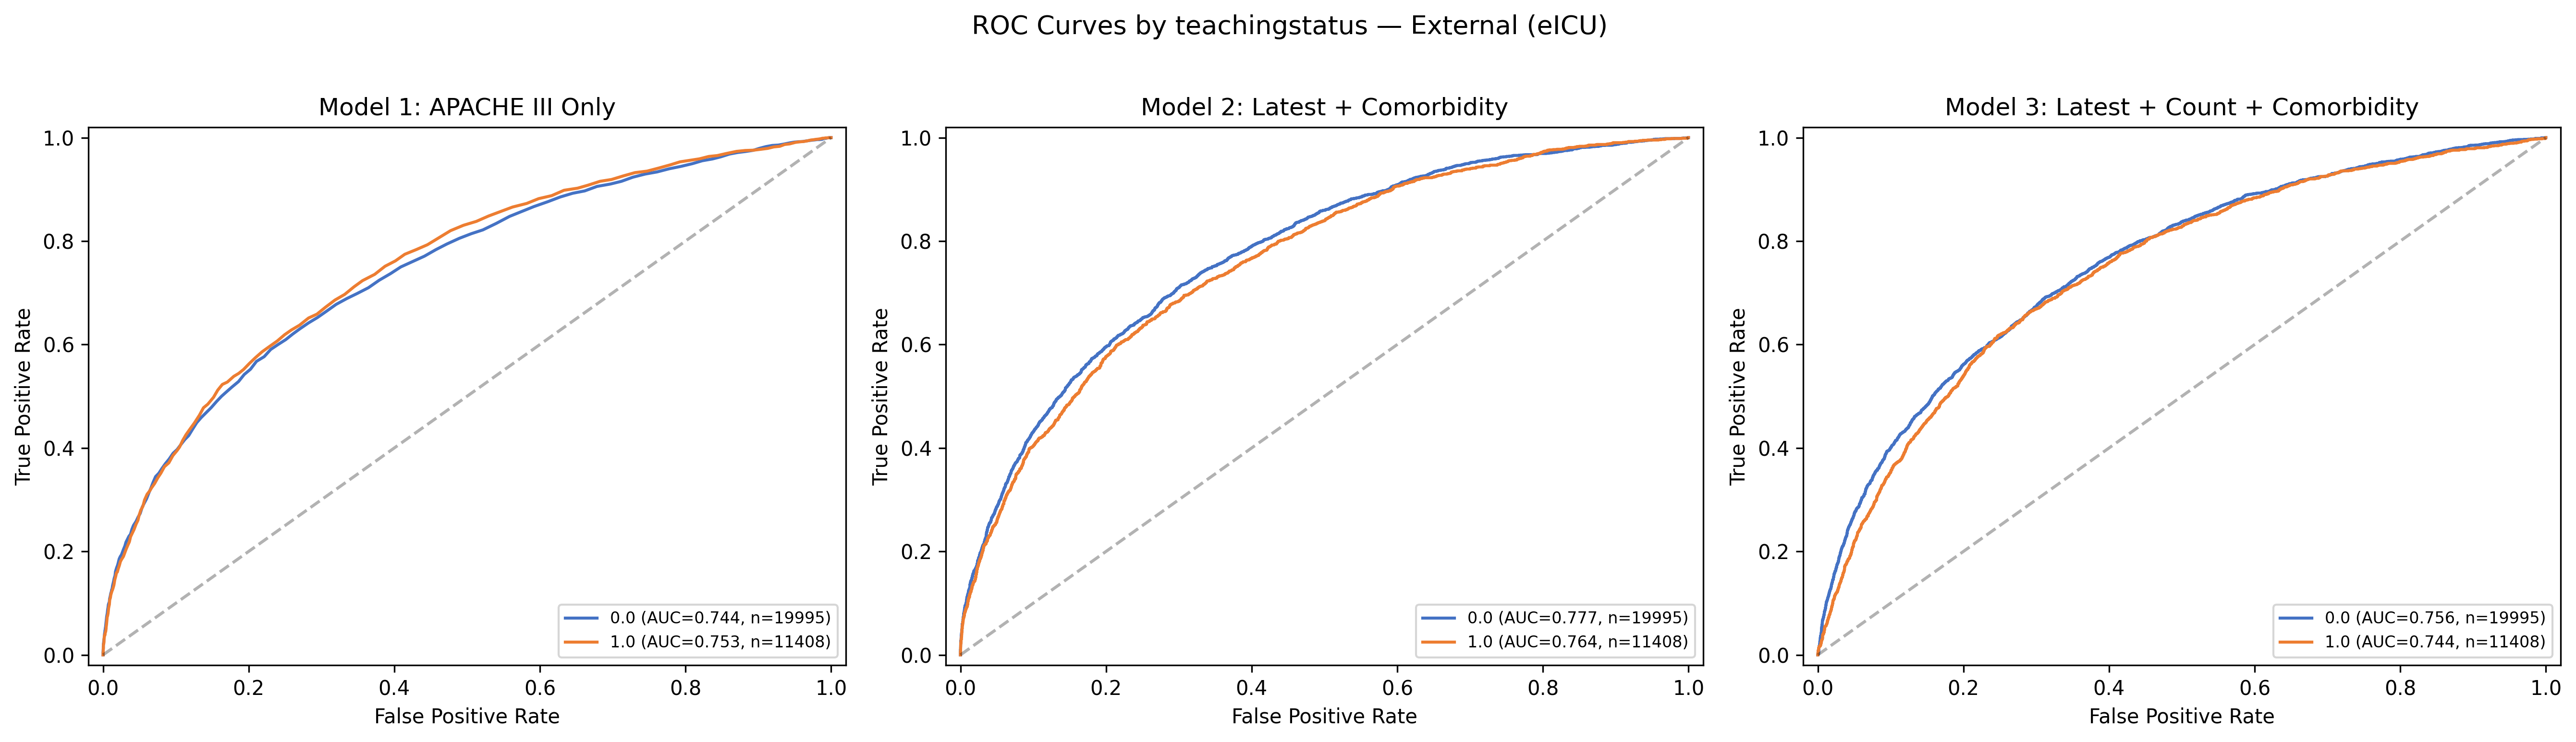

Saved: SFigure_subgroup_ROC_region.png


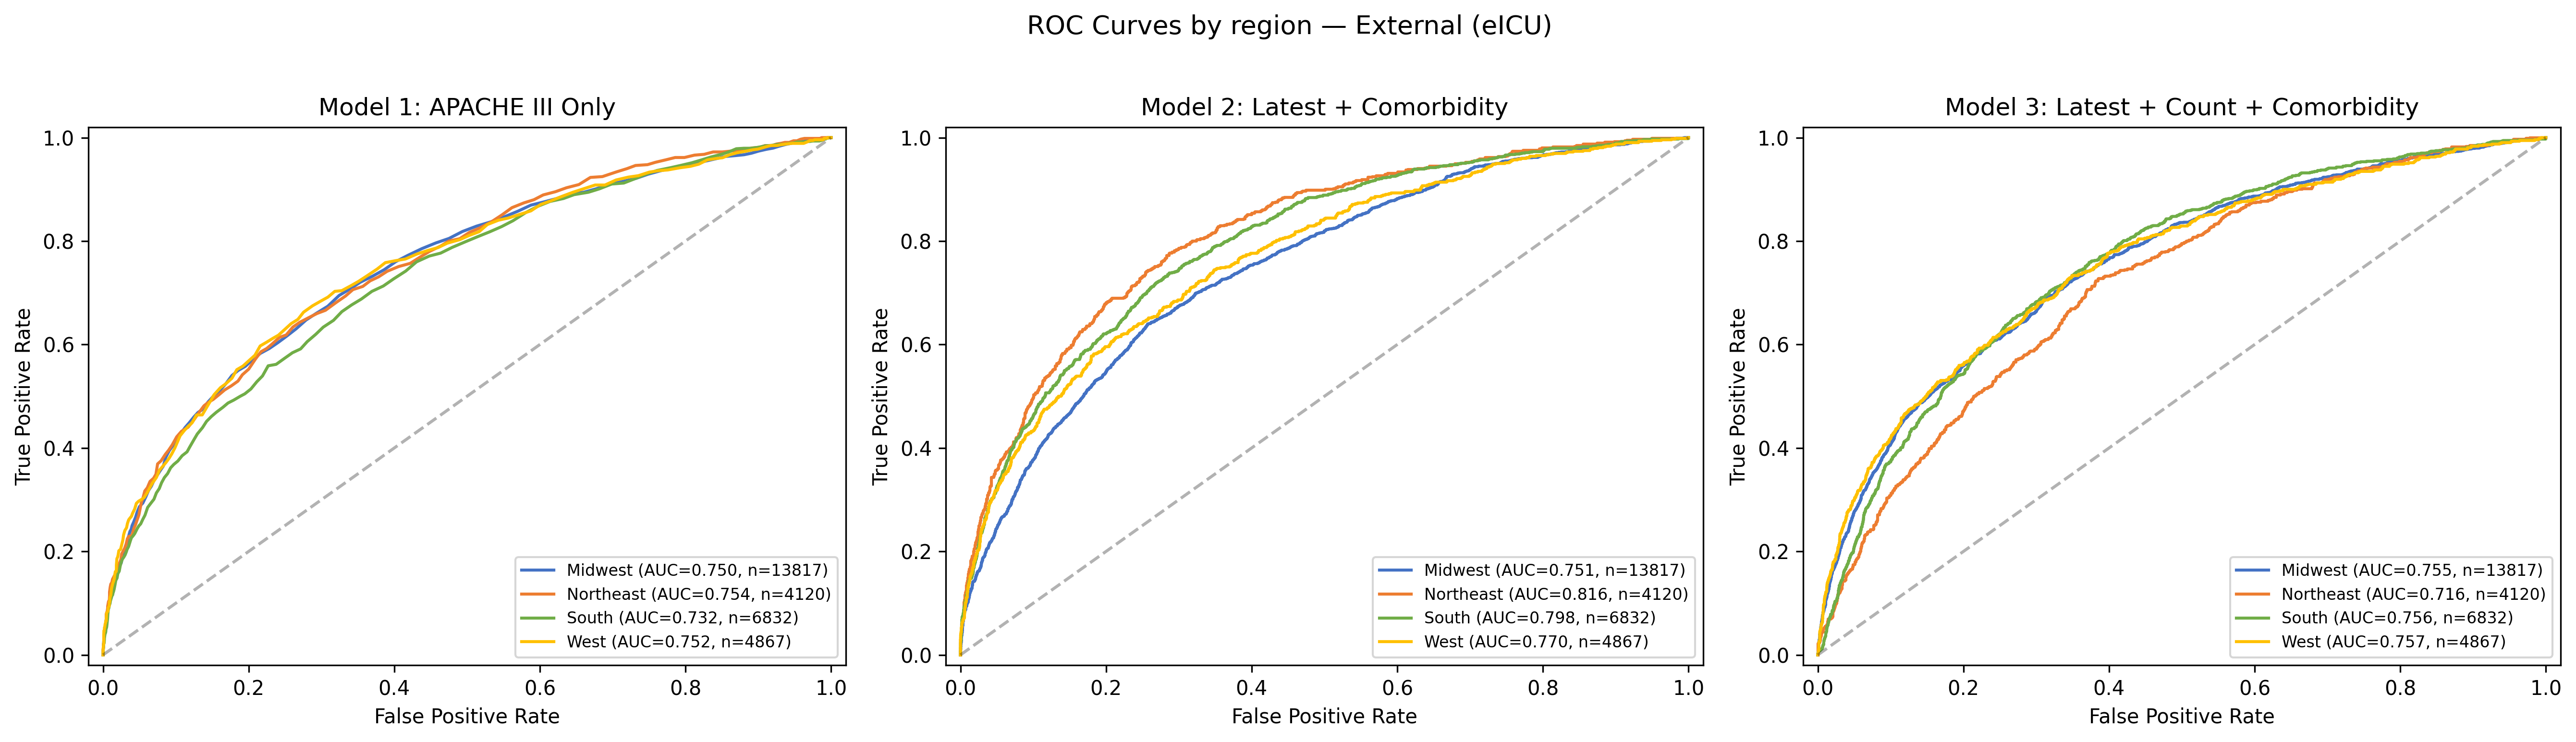

Subgroup ROC figures (teaching, region) complete!


In [43]:
# ============================================================
# Step 22: Subgroup Analysis — ROC Curve Figures (Teaching & Region)
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Note: Race/ethnicity ROC figures are now in Supplementary Figure 6 (combined layout)
subgroup_configs = [
    {
        'var_name': 'teachingstatus',
        'dataset': 'External (eICU)',
        'y_true': y_ext,
        'groups': subgroup_ext_teaching,
        'get_pred': lambda mk: predictions[mk]['y_ext_pred'],
        'filename': 'SFigure_subgroup_ROC_teaching.png',
    },
    {
        'var_name': 'region',
        'dataset': 'External (eICU)',
        'y_true': y_ext,
        'groups': subgroup_ext_region,
        'get_pred': lambda mk: predictions[mk]['y_ext_pred'],
        'filename': 'SFigure_subgroup_ROC_region.png',
    },
]

color_palette = ['#4472C4', '#ED7D31', '#70AD47', '#FFC000', '#5B9BD5', '#C00000']

for cfg in subgroup_configs:
    groups = cfg['groups']
    unique_groups = sorted(groups.dropna().unique())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for col_idx, model_key in enumerate(['Model 1', 'Model 2', 'Model 3']):
        ax = axes[col_idx]
        y_pred = cfg['get_pred'](model_key)

        for g_idx, grp in enumerate(unique_groups):
            mask = (groups == grp).values
            yt = np.asarray(cfg['y_true'])[mask]
            yp = np.asarray(y_pred)[mask]

            if len(np.unique(yt)) < 2:
                continue

            fpr, tpr, _ = roc_curve(yt, yp)
            auc_val = roc_auc_score(yt, yp)
            ax.plot(fpr, tpr, color=color_palette[g_idx % len(color_palette)],
                    label=f'{grp} (AUC={auc_val:.3f}, n={mask.sum()})', linewidth=1.5)

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{model_key}: {pipelines[model_key]["name"]}')
        ax.legend(loc='lower right', fontsize=8)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])

    fig.suptitle(f'ROC Curves by {cfg["var_name"]} — {cfg["dataset"]}', fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(OUT_DIR / cfg['filename'], dpi=300, bbox_inches='tight')
    print(f'Saved: {cfg["filename"]}')
    plt.show()

print("Subgroup ROC figures (teaching, region) complete!")

Saved: SFigure_6_subgroup_ROC_race_combined.png


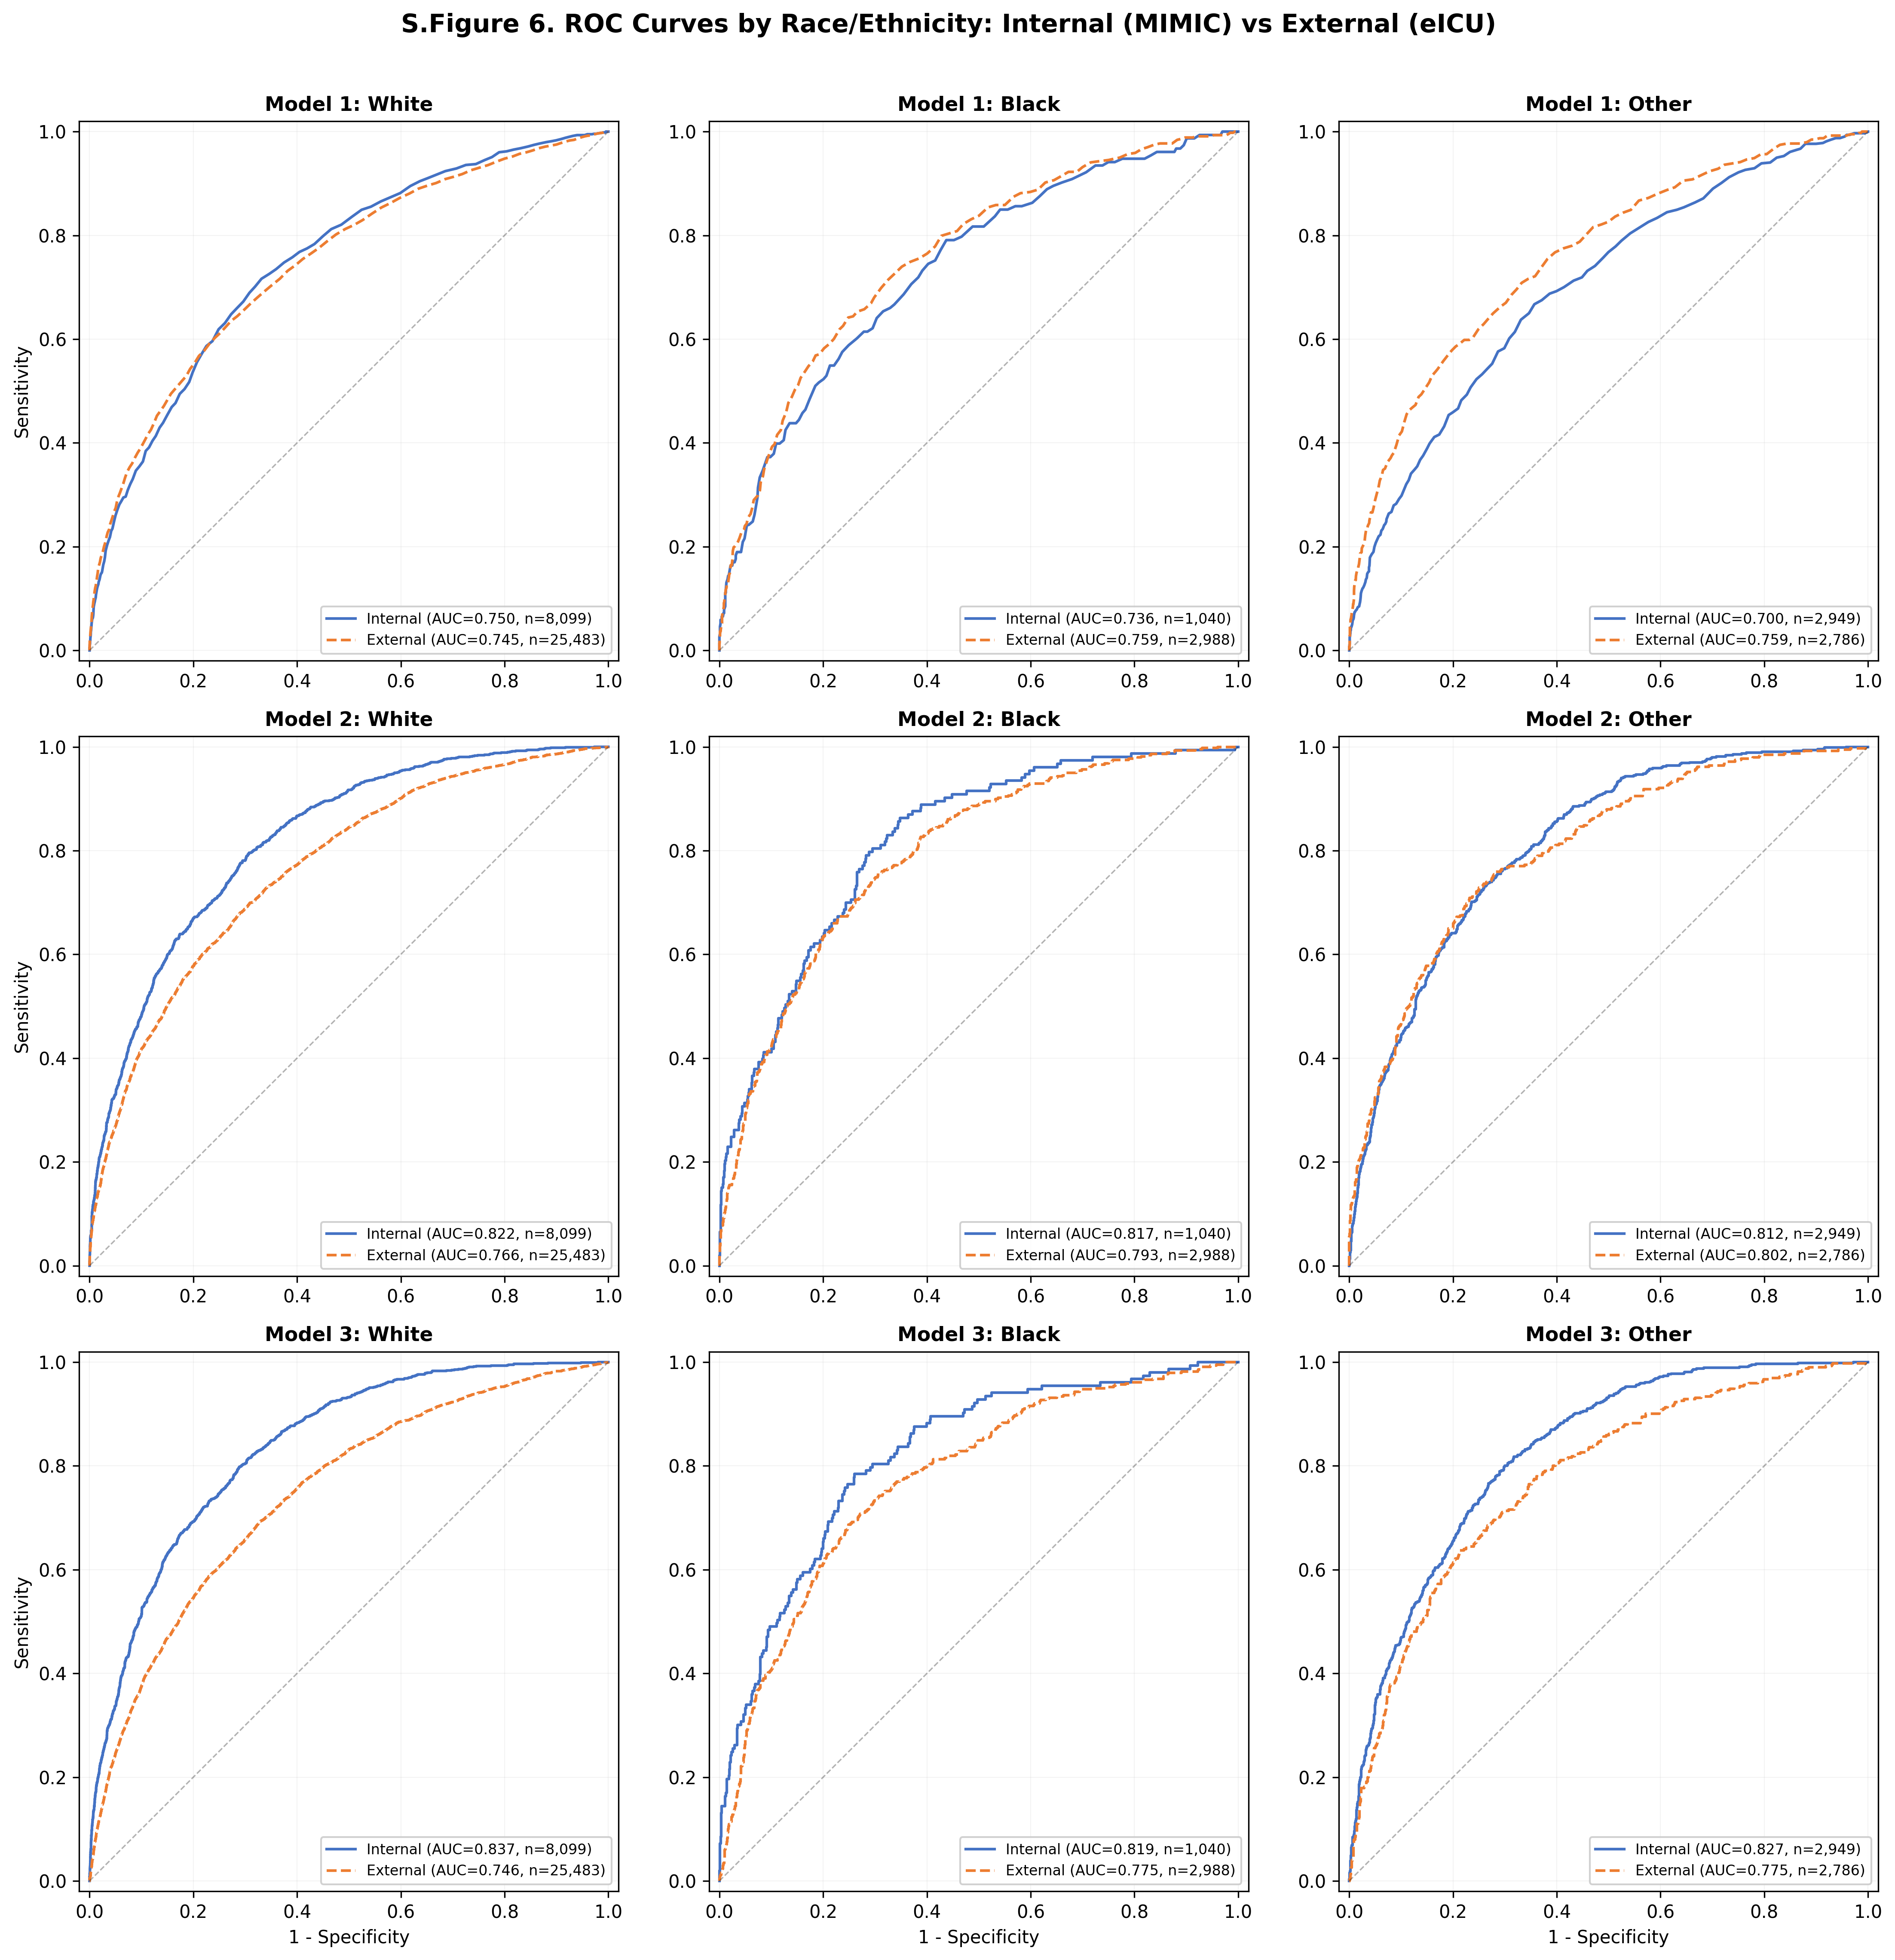

In [44]:
# ============================================================
# Supplementary Figure 6: Subgroup ROC by Race/Ethnicity
# Combined Internal (MIMIC) vs External (eICU) per cell
# Layout: 3 rows (Models) x 3 columns (Race groups)
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Define race groups (order for columns)
race_groups = ['White', 'Black', 'Other']

# Define models (order for rows)
model_keys = ['Model 1', 'Model 2', 'Model 3']

# Colors for Internal vs External
COLOR_INTERNAL = '#4472C4'  # Blue
COLOR_EXTERNAL = '#ED7D31'  # Orange

# Create figure: 3 rows x 3 cols
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row_idx, model_key in enumerate(model_keys):
    # Get predictions for this model
    y_test_pred = predictions[model_key]['y_test_pred']
    y_ext_pred = predictions[model_key]['y_ext_pred']
    
    for col_idx, race_grp in enumerate(race_groups):
        ax = axes[row_idx, col_idx]
        
        # --- Internal (MIMIC) ---
        mask_int = (subgroup_test_race_3 == race_grp).values
        yt_int = np.asarray(y_test)[mask_int]
        yp_int = np.asarray(y_test_pred)[mask_int]
        n_int = mask_int.sum()
        
        if len(np.unique(yt_int)) >= 2 and n_int > 0:
            fpr_int, tpr_int, _ = roc_curve(yt_int, yp_int)
            auc_int = roc_auc_score(yt_int, yp_int)
            ax.plot(fpr_int, tpr_int, '-', color=COLOR_INTERNAL, 
                    label=f'Internal (AUC={auc_int:.3f}, n={n_int:,})', linewidth=1.5)
        
        # --- External (eICU) ---
        mask_ext = (subgroup_ext_race_3 == race_grp).values
        yt_ext = np.asarray(y_ext)[mask_ext]
        yp_ext = np.asarray(y_ext_pred)[mask_ext]
        n_ext = mask_ext.sum()
        
        if len(np.unique(yt_ext)) >= 2 and n_ext > 0:
            fpr_ext, tpr_ext, _ = roc_curve(yt_ext, yp_ext)
            auc_ext = roc_auc_score(yt_ext, yp_ext)
            ax.plot(fpr_ext, tpr_ext, '--', color=COLOR_EXTERNAL, 
                    label=f'External (AUC={auc_ext:.3f}, n={n_ext:,})', linewidth=1.5)
        
        # Diagonal reference line
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
        
        # Axis settings
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_aspect('equal')
        
        # Labels (only on edges)
        if row_idx == 2:  # Bottom row
            ax.set_xlabel('1 - Specificity', fontsize=10)
        if col_idx == 0:  # Left column
            ax.set_ylabel('Sensitivity', fontsize=10)
        
        # Title for each cell (model + race)
        ax.set_title(f'{model_key}: {race_grp}', fontsize=11, fontweight='bold')
        
        # Legend
        ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
        
        # Grid
        ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.5)

# Overall title
fig.suptitle('S.Figure 6. ROC Curves by Race/Ethnicity: Internal (MIMIC) vs External (eICU)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()

# Save figure
fig.savefig(OUT_DIR / 'SFigure_6_subgroup_ROC_race_combined.png', dpi=300, bbox_inches='tight')
print('Saved: SFigure_6_subgroup_ROC_race_combined.png')
plt.show()

## Summary

### Validation Design

| Set | Source | N (approx) | Purpose |
|-----|--------|------------|---------|
| Train | MIMIC-IV (60%) | ~18,000 | Model development |
| Internal Test | MIMIC-IV (40%) | ~12,000 | Internal validation / model selection |
| External Validation | eICU (100%) | ~31,000 | External validation |

### Key Considerations

- MIMIC-IV is a single-center dataset (Beth Israel Deaconess Medical Center)
- eICU is a multi-center dataset (208 hospitals across USA)
- MIMIC wide data is split using **stratified sampling** (`stratify=y`) to maintain outcome proportions
- This produces the **same split** as the internal validation notebook (05_2)
- Imputation is **fit on training data only** and applied to test/external sets
- Different missing data patterns between datasets
- Different baseline mortality rates between MIMIC and eICU

## Discussion

### Key message
Measurement counts can impair external calibration when added to logistic regression, even when internal performance improves, suggesting limited transportability of process-related features.

### Why Does Adding Count Features Worsen Calibration in Logistic Regression but Not in XGBoost?

A notable finding from our calibration analysis (Figures 3 and 4) is that incorporating measurement frequency (count) features consistently degraded calibration performance in logistic regression models (Model 2 vs. 3, Model 4 vs. 5, Model 6 vs. 7), whereas XGBoost models remained relatively robust to the inclusion of these variables.

We propose that this discrepancy is primarily driven by **domain shift** arising from the nature of count features.

#### Count Features as a Proxy for Facility-Level Care Intensity

Measurement frequency (e.g., how often heart rate, lab values, or blood gases are recorded) does not solely reflect patient acuity. It is also heavily influenced by **facility-level care practices**, including staffing ratios, monitoring protocols, institutional culture, and resource availability. A patient with identical severity may have vastly different measurement counts depending on the hospital in which they are admitted.

Because our derivation cohort (MIMIC-IV) comes from a single academic tertiary care center (Beth Israel Deaconess Medical Center), while the external validation cohort (eICU) spans 208 hospitals with heterogeneous care practices, count features are particularly susceptible to **distributional shift** between the two datasets. The measurement frequency patterns learned during training may not generalize to institutions with different monitoring practices.

#### Why Logistic Regression Is More Vulnerable

Logistic regression assumes a **linear relationship** between each feature and the log-odds of the outcome. When count features are included, the model assigns fixed coefficients to these variables. If the relationship between measurement frequency and mortality differs systematically between the derivation and external cohorts (due to facility-level differences), the predicted probabilities become miscalibrated. The linear model cannot adapt to the shifted distribution; it simply extrapolates the learned linear relationship, leading to biased probability estimates.

Furthermore, count features are correlated with both the clinical variables (sicker patients tend to be monitored more frequently) and facility-level factors (some hospitals monitor all patients more frequently). This **confounding structure** exacerbates coefficient instability in logistic regression through multicollinearity.

#### Why XGBoost Is More Robust

XGBoost, as a tree-based ensemble method, handles this situation more gracefully for several reasons:

1. **Non-linear partitioning**: Decision trees can learn different relationships between count features and the outcome at different threshold values, effectively compartmentalizing the influence of these variables.
2. **Feature interaction handling**: Trees naturally model interactions between count features and clinical variables, which may partially compensate for distributional shifts.
3. **Implicit feature selection**: If count features are not informative in certain regions of the feature space, the tree simply does not split on them, limiting their influence on predictions.
4. **Regularization**: XGBoost’s built-in regularization (max depth, learning rate, subsampling) constrains the model from over-relying on any single group of features.

#### Implications for Model Deployment

These findings suggest that when building clinical prediction models intended for external deployment, **care-process variables** (such as measurement frequency) should be incorporated with caution, particularly in linear models. While count features carry genuine prognostic information (monitoring intensity correlates with clinical concern), they also encode institutional practice patterns that may not transfer across sites. Tree-based models appear more resilient to this form of domain shift, but the underlying distributional differences should nonetheless be carefully evaluated during external validation.

#### paragraph example
Adding a Count feature, defined as the number of vital sign and laboratory measurements within the first 24 hours, worsened calibration for logistic regression, while XGBoost showed little change, and the same pattern remained with quantile binning. Two reasons are likely. First, Count is highly skewed with many zeros and a long right tail. In logistic regression, Count enters the linear predictor linearly, so extreme values can push predicted probabilities toward 0 or 1 and magnify miscalibration when the tail differs between development and external cohorts. Second, Count is strongly site dependent. It reflects not only patient severity but also monitoring intensity, staffing, and local ordering and documentation practices. Therefore, the same Count can represent different underlying risk across hospitals, which reduces transportability and can lead to systematic overprediction and overly extreme predictions in external validation. In contrast, XGBoost can represent non linear and saturating effects and interactions, which may limit probability scale distortion when the distribution and meaning of Count shift across sites. These findings suggest that measurement intensity can help within domain prediction but may harm external calibration unless site effects are addressed and external recalibration is applied before deployment.